# Pediatric Brain Tumor Segmentation (BraTS PEDs) — Research-Grade Pipeline

This notebook implements the pipeline in [Pediatric_Type/Pediatric_BraTS_Research_Grade_Segmentation_Roadmap.md](Pediatric_Type/Pediatric_BraTS_Research_Grade_Segmentation_Roadmap.md) **in order**.

**Strict execution rules (enforced by process):**
- Implement one section at a time (no skipping).
- After each major step: print tensor/array shapes, visualize sample slices, validate assumptions.
- If metrics miss the roadmap thresholds (especially ET Dice): **stop and diagnose before continuing**.

**Dataset expectation (BraTS PEDs):** modalities `T1`, `T1ce`, `T2`, `FLAIR`; labels `{0,1,2,4}`.


## Citation (nnU-Net)

> Please cite the following paper when using nnU-Net:

> Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. *Nature Methods*, 18(2), 203–211.

In [28]:
# Section 0 — Core Principles: reproducibility first

from __future__ import annotations

import os
import platform
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np

DEFAULT_SEED = 1337


def seed_everything(seed: int = DEFAULT_SEED, deterministic: bool = True) -> None:
    """Seed Python/NumPy/PyTorch for research-grade reproducibility."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch

        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        if deterministic:
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
            # Some ops (esp. MONAI random augmentations) can be non-deterministic;
            # keep this False to avoid hard failures.
            torch.use_deterministic_algorithms(False)
    except Exception as exc:
        print(f"[WARN] Torch seeding skipped: {exc}")


seed_everything(DEFAULT_SEED)


@dataclass(frozen=True)
class Paths:
    extraction_base: Path
    training_main_dir: Path
    validation_main_dir: Path


print("Seeded.")
print("Platform:", platform.platform())
print("Python:", platform.python_version())
print("CWD:", Path.cwd())


Seeded.
Platform: Linux-5.15.0-1053-nvidia-x86_64-with-glibc2.39
Python: 3.12.3
CWD: /workspace


## Section 1 — Dataset & directory assumptions

This section validates:
- We can access the dataset (GPU server path preferred).
- The on-disk organization contains the expected modalities (`T1`, `T1ce`, `T2`, `FLAIR`) and labels (`{0,1,2,4}`).
- A single case loads cleanly and modalities are aligned.


In [29]:
# Section 1A — GPU server compatibility + required library checks

import importlib
import shutil
import sys


def _try_import(pkg: str):
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "unknown")
        print(f"[OK] import {pkg} (version={ver})")
        return True
    except Exception as exc:
        print(f"[MISSING] import {pkg} failed: {exc}")
        return False


print("Executable:", sys.executable)

# Core numerical + IO
_try_import("numpy")
_try_import("matplotlib")
_try_import("nibabel")
_try_import("SimpleITK")

# Deep learning
has_torch = _try_import("torch")
has_monai = _try_import("monai")

if has_torch:
    import torch

    print("torch:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("cuda device count:", torch.cuda.device_count())
        print("gpu name:", torch.cuda.get_device_name(0))
        print("cuda version (torch):", torch.version.cuda)
        print("cudnn enabled:", torch.backends.cudnn.enabled)

# nnU-Net v2 baseline requirement
has_nnunet = _try_import("nnunetv2")

for cmd in [
    "nnUNetv2_plan_and_preprocess",
    "nnUNetv2_train",
    "nnUNetv2_predict",
    "nnUNetv2_find_best_configuration",
]:
    p = shutil.which(cmd)
    print(f"{cmd}: {'FOUND' if p else 'NOT FOUND'}" + (f" -> {p}" if p else ""))

print("\nIf anything above is MISSING, we will install it in-notebook (pip) before proceeding.")


Executable: /usr/bin/python
[OK] import numpy (version=1.26.4)
[OK] import matplotlib (version=3.9.3)
[OK] import nibabel (version=5.3.3)
[OK] import SimpleITK (version=2.5.3)
[OK] import torch (version=2.6.0a0+df5bbc09d1.nv24.12)
[OK] import monai (version=1.5.1)
torch: 2.6.0a0+df5bbc09d1.nv24.12
cuda available: True
cuda device count: 1
gpu name: NVIDIA H100 80GB HBM3 MIG 3g.40gb
cuda version (torch): 12.6
cudnn enabled: True
[OK] import nnunetv2 (version=unknown)
nnUNetv2_plan_and_preprocess: FOUND -> /usr/local/bin/nnUNetv2_plan_and_preprocess
nnUNetv2_train: FOUND -> /usr/local/bin/nnUNetv2_train
nnUNetv2_predict: FOUND -> /usr/local/bin/nnUNetv2_predict
nnUNetv2_find_best_configuration: FOUND -> /usr/local/bin/nnUNetv2_find_best_configuration

If anything above is MISSING, we will install it in-notebook (pip) before proceeding.


In [30]:
# Section 1B — Locate dataset on GPU server mount (preferred) or local workspace

from pathlib import Path


def _find_brats_peds_root(preferred: Path) -> Path | None:
    """Try to locate the PEDs dataset root; prefer the GPU server mount."""
    preferred = Path(preferred)
    if preferred.exists():
        return preferred

    # Fallback: search common local locations (bounded depth to avoid slow walks)
    candidates = [
        Path.cwd(),
        Path.cwd() / "archive",
        Path.cwd().parent,
        Path.cwd().parent / "archive",
    ]

    target_names = {"BraTS-PEDs2024_Training", "BraTS-PEDs2024_Validation"}

    for base in candidates:
        if not base.exists():
            continue
        try:
            base_parts = len(base.resolve().parts)
            for p in base.rglob("*"):
                try:
                    if len(p.resolve().parts) - base_parts > 4:
                        continue
                except Exception:
                    continue
                if p.is_dir() and p.name in target_names:
                    # Expect structure: <root>/<training|validation>/<BraTS-PEDs2024_Training|Validation>
                    # So dataset root is two parents up.
                    return p.parent.parent
        except Exception:
            continue

    return None


def _find_validation_dir(extraction_base: Path) -> Path | None:
    """BraTS validation labels may be absent or folder names may vary."""
    extraction_base = Path(extraction_base)

    # First: user's stated expected location
    expected = extraction_base / "validation" / "BraTS-PEDs2024_Validation"
    if expected.exists():
        return expected

    # Common variants
    variants = [
        extraction_base / "validation" / "BraTS-PEDs2024_ValidationData",
        extraction_base / "BraTS-PEDs2024_Validation",
        extraction_base / "BraTS-PEDs2024_ValidationData",
    ]
    for v in variants:
        if v.exists():
            return v

    # Heuristic scan under extraction_base (bounded)
    try:
        for p in extraction_base.rglob("BraTS-PEDs2024_*Validation*"):
            if p.is_dir():
                return p
    except Exception:
        pass

    return None


preferred_root = Path("/workspace/pediatric_tumor_data")
extraction_base = _find_brats_peds_root(preferred_root)

if extraction_base is None:
    raise FileNotFoundError(
        "Could not find PEDs dataset root. Expected GPU mount '/workspace/pediatric_tumor_data'. "
        "If running locally on Windows, place the dataset under a known folder and update 'preferred_root'."
    )

training_main_dir = extraction_base / "training" / "BraTS-PEDs2024_Training"
validation_main_dir = _find_validation_dir(extraction_base)

paths = Paths(
    extraction_base=extraction_base,
    training_main_dir=training_main_dir,
    validation_main_dir=(validation_main_dir if validation_main_dir is not None else Path("")),
)

print("extraction_base:", extraction_base)
print("training_main_dir:", training_main_dir, "exists=", training_main_dir.exists())
print("validation_main_dir:", validation_main_dir if validation_main_dir is not None else "<not found>")

if not training_main_dir.exists():
    raise FileNotFoundError(
        "Found dataset root but training folder is missing at 'training/BraTS-PEDs2024_Training'. "
        "Please confirm the directory structure under extraction_base."
    )

# Quick inventory (validation may be unlabeled/absent; we'll split training later if needed)
train_cases = sorted([p for p in training_main_dir.iterdir() if p.is_dir()])
val_cases = (
    sorted([p for p in validation_main_dir.iterdir() if p.is_dir()])
    if validation_main_dir is not None and validation_main_dir.exists()
    else []
)

print(f"#train cases: {len(train_cases)}")
print(f"#val cases (folder): {len(val_cases)}")
print("Example train case:", train_cases[0] if train_cases else "<none>")
print("Example val case:", val_cases[0] if val_cases else "<none>")

if validation_main_dir is None:
    print(
        "\n[NOTE] No validation folder found. This is common in BraTS: validation labels are often withheld. "
        "We will create an internal train/val split from training for metric gating."
    )

# Minimal structure overview to debug mounts
try:
    print("\nTop-level under extraction_base:")
    for p in sorted(extraction_base.iterdir()):
        if p.is_dir():
            print(" -", p.name)
except Exception as exc:
    print("[WARN] Could not list extraction_base:", exc)


extraction_base: /workspace/pediatric_tumor_data
training_main_dir: /workspace/pediatric_tumor_data/training/BraTS-PEDs2024_Training exists= True
validation_main_dir: <not found>
#train cases: 261
#val cases (folder): 0
Example train case: /workspace/pediatric_tumor_data/training/BraTS-PEDs2024_Training/BraTS-PED-00001-000
Example val case: <none>

[NOTE] No validation folder found. This is common in BraTS: validation labels are often withheld. We will create an internal train/val split from training for metric gating.

Top-level under extraction_base:
 - nnunetv2
 - training
 - validation


In [31]:
# Section 1B.1 — Inspect dataset directories (training/validation) to confirm BraTS naming

from pathlib import Path

def _ls_dir(p: Path, max_items: int = 30) -> None:
    p = Path(p)
    print(f"\n== {p} ==")
    if not p.exists():
        print("<missing>")
        return
    items = sorted(list(p.iterdir()))
    print(f"items: {len(items)}")
    for x in items[:max_items]:
        tag = "/" if x.is_dir() else ""
        print(" -", x.name + tag)
    if len(items) > max_items:
        print(f"... (+{len(items) - max_items} more)")

_ls_dir(extraction_base)
_ls_dir(extraction_base / "training")
_ls_dir(extraction_base / "validation")

# If there is exactly one directory inside validation/, treat it as the validation_main_dir
val_root = extraction_base / "validation"
val_children = [d for d in val_root.iterdir() if d.is_dir()] if val_root.exists() else []
if validation_main_dir is None and len(val_children) == 1:
    validation_main_dir = val_children[0]
    print("\n[INFO] Auto-selected validation_main_dir:", validation_main_dir)
    val_cases = sorted([p for p in validation_main_dir.iterdir() if p.is_dir()])
    print(f"#val cases (folder): {len(val_cases)}")
    print("Example val case:", val_cases[0] if val_cases else "<none>")



== /workspace/pediatric_tumor_data ==
items: 3
 - nnunetv2/
 - training/
 - validation/

== /workspace/pediatric_tumor_data/training ==
items: 2
 - BraTS-PEDs2024_Training/
 - __MACOSX/

== /workspace/pediatric_tumor_data/validation ==
items: 1
 - BraTS_Validation_Data_backup/

[INFO] Auto-selected validation_main_dir: /workspace/pediatric_tumor_data/validation/BraTS_Validation_Data_backup
#val cases (folder): 91
Example val case: /workspace/pediatric_tumor_data/validation/BraTS_Validation_Data_backup/BraTS-PED-00267-000


In [32]:
# Section 1C — Validate one training + one validation case: modalities + label set + alignment
# NOTE: This cell intentionally detects label-ontology mismatches and sets a STOP flag.
# We do NOT proceed to training until the mismatch is resolved.

from typing import Dict, Tuple
import re

import numpy as np

try:
    import nibabel as nib
except Exception as exc:
    raise RuntimeError(
        "nibabel is required for NIfTI IO in this notebook. Install it before continuing."
    ) from exc


LABEL_ONTOLOGY_MISMATCH = False
UNEXPECTED_LABELS: list[int] = []

# BraTS-style expectations (names on disk vary; use robust token matching)
EXPECTED_MODALITIES = ("t1", "t1ce", "t2", "flair")
LABEL_TOKENS = ("seg", "label", "labels")

# BraTS 2025-ish naming seen on your server:
# - t1n = T1
# - t1c = T1ce (post-contrast)
# - t2w = T2
# - t2f = FLAIR
MODALITY_PATTERNS = {
    "t1": [
        r"(^|[_-])t1($|[_-])",
        r"(^|[_-])t1n($|[_-])",
        r"(^|[_-])t1w($|[_-])",
    ],
    "t1ce": [
        r"(^|[_-])(t1ce|t1c|t1gd|t1_gd|t1post|t1postcontrast)($|[_-])",
    ],
    "t2": [
        r"(^|[_-])t2($|[_-])",
        r"(^|[_-])t2w($|[_-])",
    ],
    "flair": [
        r"(^|[_-])(flair|t2flair|t2f)($|[_-])",
    ],
}


def _stem_no_ext(p: str) -> str:
    name = p.lower()
    for ext in (".nii.gz", ".nii"):
        if name.endswith(ext):
            name = name[: -len(ext)]
            break
    return name


def _index_case_files(case_dir: Path) -> Dict[str, Path]:
    """Return dict mapping modality/seg -> nifti path (best-effort)."""
    nii_files = list(case_dir.glob("*.nii")) + list(case_dir.glob("*.nii.gz"))
    out: Dict[str, Path] = {}

    # First pass: segmentation/label
    for f in nii_files:
        stem = _stem_no_ext(f.name)
        if any(tok in stem for tok in LABEL_TOKENS):
            out["seg"] = f

    # Second pass: modalities (regex tokens to avoid t1 matching t1ce)
    for f in nii_files:
        stem = _stem_no_ext(f.name)
        for m, pats in MODALITY_PATTERNS.items():
            if m in out:
                continue
            if any(re.search(pat, stem) for pat in pats):
                out[m] = f

    return out


def _load_nii(path: Path) -> Tuple[np.ndarray, np.ndarray]:
    img = nib.load(str(path))
    data = np.asarray(img.get_fdata(dtype=np.float32))
    affine = np.asarray(img.affine)
    return data, affine


def _pick_case_with_modalities(case_dirs: list[Path], require_seg: bool) -> tuple[Path, Dict[str, Path]]:
    for d in case_dirs:
        idx = _index_case_files(d)
        ok_mods = all(m in idx for m in EXPECTED_MODALITIES)
        ok_seg = ("seg" in idx) if require_seg else True
        if ok_mods and ok_seg:
            return d, idx
    d0 = case_dirs[0]
    return d0, _index_case_files(d0)


def _prepare_segmentation(seg_f: np.ndarray) -> tuple[np.ndarray, dict]:
    """Ensure seg is integer-coded; detect interpolation/float artifacts."""
    info = {}
    seg = np.asarray(seg_f, dtype=np.float32)

    seg_round = np.rint(seg)
    frac_nonint = float(np.mean(np.abs(seg - seg_round) > 1e-3))
    info["frac_nonint"] = frac_nonint

    seg_i = seg_round.astype(np.int16)
    uniq, cnt = np.unique(seg_i, return_counts=True)
    info["unique_after_rounding"] = uniq
    info["label_counts"] = {int(u): int(c) for u, c in zip(uniq, cnt)}
    return seg_i, info


def _validate_case(case_dir: Path, idx: Dict[str, Path], title: str, expect_labels: bool) -> dict:
    global LABEL_ONTOLOGY_MISMATCH, UNEXPECTED_LABELS

    print(f"\n===== {title} =====")
    print("Case:", case_dir)
    print("Indexed keys:", sorted(idx.keys()))

    missing_mods = [m for m in EXPECTED_MODALITIES if m not in idx]
    if missing_mods:
        print("[WARN] Missing modalities:", missing_mods)
        print("Files:")
        for f in sorted(list(case_dir.glob("*.nii*"))):
            print(" -", f.name)
        raise RuntimeError(
            f"Missing modalities in {case_dir}: {missing_mods}. "
            "This usually means filenames differ from expected tokens."
        )

    vols = {}
    affines = {}

    for k in EXPECTED_MODALITIES:
        d, a = _load_nii(idx[k])
        vols[k] = d
        affines[k] = a
        print(f"{k}: shape={d.shape}, dtype={d.dtype}, min={float(d.min()):.3f}, max={float(d.max()):.3f}")

    if "seg" in idx:
        d, a = _load_nii(idx["seg"])
        seg_i, seg_info = _prepare_segmentation(d)
        vols["seg"] = seg_i
        affines["seg"] = a

        print(f"seg: shape={d.shape}, loaded_dtype={d.dtype}, stored_dtype={seg_i.dtype}")
        print("seg rounding: frac_nonint=", f"{seg_info['frac_nonint']:.6f}")
        print("Unique labels (after rounding):", seg_info["unique_after_rounding"])
        print("Label voxel counts:", seg_info["label_counts"])

        allowed = {0, 1, 2, 4}
        uniq_set = set(int(x) for x in seg_info["unique_after_rounding"])
        unexpected = sorted(list(uniq_set - allowed))
        if unexpected:
            LABEL_ONTOLOGY_MISMATCH = True
            UNEXPECTED_LABELS = unexpected
            print("\n[STOP] Label ontology mismatch vs roadmap.")
            print("Roadmap expects labels subset of {0,1,2,4}.")
            print("This dataset contains additional label(s):", UNEXPECTED_LABELS)
            print("We will run a dedicated inference step next to determine how to remap.")
    else:
        if expect_labels:
            raise RuntimeError(
                "Expected labels, but no seg/label file was found in this case folder."
            )
        print("[NOTE] No seg/label file found (labels may be withheld for this split).")

    shapes = {k: vols[k].shape for k in EXPECTED_MODALITIES}
    if len(set(shapes.values())) != 1:
        raise RuntimeError(f"Modality shapes do not match: {shapes}")

    ref = affines["t1"]
    for k in EXPECTED_MODALITIES:
        diff = float(np.max(np.abs(affines[k] - ref)))
        print(f"affine max|Δ| {k} vs t1: {diff:.6f}")

    return vols


if len(train_cases) == 0:
    raise RuntimeError("No training cases found; cannot proceed.")

train_case, train_idx = _pick_case_with_modalities(train_cases, require_seg=True)
train_vols = _validate_case(train_case, train_idx, title="TRAIN SAMPLE", expect_labels=True)

if validation_main_dir is None or len(val_cases) == 0:
    print("\n[NOTE] No validation case folders found; skipping validation sample load.")
    val_vols = None
    val_case = None
else:
    has_any_val_seg = any("seg" in _index_case_files(d) for d in val_cases[:10])
    val_case, val_idx = _pick_case_with_modalities(val_cases, require_seg=has_any_val_seg)
    val_vols = _validate_case(
        val_case,
        val_idx,
        title=f"VALIDATION SAMPLE (labels={'present' if has_any_val_seg else 'absent/unknown'})",
        expect_labels=has_any_val_seg,
    )



===== TRAIN SAMPLE =====
Case: /workspace/pediatric_tumor_data/training/BraTS-PEDs2024_Training/BraTS-PED-00001-000
Indexed keys: ['flair', 'seg', 't1', 't1ce', 't2']
t1: shape=(240, 240, 155), dtype=float32, min=0.000, max=1462.307
t1ce: shape=(240, 240, 155), dtype=float32, min=0.000, max=2045.110
t2: shape=(240, 240, 155), dtype=float32, min=0.000, max=3426.337
flair: shape=(240, 240, 155), dtype=float32, min=0.000, max=1338.011
seg: shape=(240, 240, 155), loaded_dtype=float32, stored_dtype=int16
seg rounding: frac_nonint= 0.000000
Unique labels (after rounding): [0 1 2 3 4]
Label voxel counts: {0: 8799333, 1: 6204, 2: 87311, 3: 607, 4: 34545}

[STOP] Label ontology mismatch vs roadmap.
Roadmap expects labels subset of {0,1,2,4}.
This dataset contains additional label(s): [3]
We will run a dedicated inference step next to determine how to remap.
affine max|Δ| t1 vs t1: 0.000000
affine max|Δ| t1ce vs t1: 0.000000
affine max|Δ| t2 vs t1: 0.000000
affine max|Δ| flair vs t1: 0.000000



## Section 1E — Infer label mapping (diagnostic)

Your server dataset contains label values not covered by the roadmap.

This step:
- Samples multiple training and validation cases
- Computes per-label voxel volumes
- Computes intensity statistics on **T1ce** and **FLAIR** (z-scored within-brain)
- Visualizes where label `3` appears

Goal: infer whether label `3` behaves like **ET**, **TC**, **WT**, or something else, and produce a safe remapping back to the roadmap’s `{0,1,2,4}` convention.


Sampled train cases: 60

Per-label summary (TRAIN only; median stats; within-brain z-score):
(delta_ce_med = median of (T1ce_z - T1_z) within each label; strongest for enhancing tissue)
label 1: n_cases=51, vol_med=5358.0, vol_p95=46225.0, delta_ce_med=0.508, t1ce_med=1.710, flair_med=2.439
label 2: n_cases=60, vol_med=27858.0, vol_p95=87711.0, delta_ce_med=-0.140, t1ce_med=1.068, flair_med=2.588
label 3: n_cases=42, vol_med=677.5, vol_p95=16466.0, delta_ce_med=-0.081, t1ce_med=1.021, flair_med=1.889
label 4: n_cases=38, vol_med=1322.5, vol_p95=98248.2, delta_ce_med=-0.203, t1ce_med=1.176, flair_med=2.495

Per-case winner vote counts (higher is more consistent):
 - delta_ce winners: {1: 48, 2: 7, 3: 4, 4: 1}
 - flair winners: {1: 14, 2: 20, 3: 4, 4: 22}
 - volume winners: {1: 4, 2: 49, 3: 1, 4: 6}

Heuristic picks:
 - enhancing_label (ET candidate): 1
 - edema_label (edema candidate): 2

Proposed LABEL_MAPPING (old -> roadmap): {0: 0, 1: 4, 2: 2, 3: 1, 4: 1}


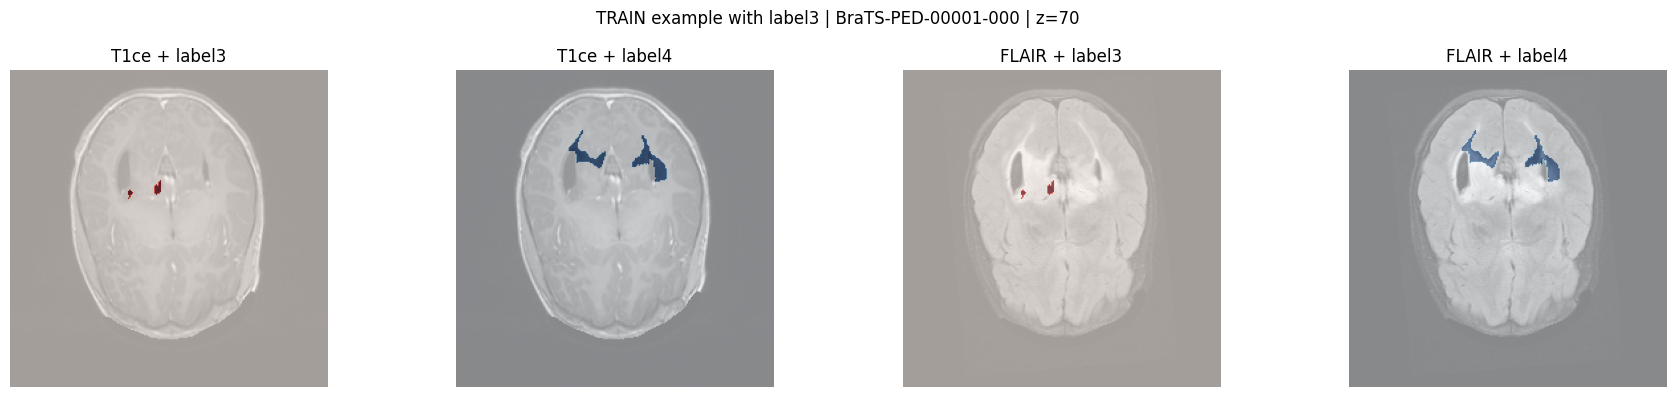


After remapping (train sample) unique labels: [0 1 2 4]
[OK] Remapped into roadmap label set {0,1,2,4}. We can proceed.


In [33]:
# Section 1E — Infer label mapping (diagnostic)
# Goal: infer meaning of label 3 (and others) for THIS server dataset,
# then remap to roadmap label set {0,1,2,4} in a defensible way.

from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt


@dataclass
class CaseStats:
    case: str
    split: str
    has_seg: bool
    present: dict
    volumes: dict
    # Within-brain z-scored means per label
    t1_mean_z: dict
    t1ce_mean_z: dict
    t2_mean_z: dict
    flair_mean_z: dict
    # Enhancement signal: (T1ce_z - T1_z) mean per label
    delta_ce_mean: dict


def _zscore_in_mask(x: np.ndarray, mask: np.ndarray) -> np.ndarray:
    vals = x[mask]
    if vals.size < 100:
        return (x - float(x.mean())) / (float(x.std()) + 1e-8)
    mu = float(vals.mean())
    sd = float(vals.std()) + 1e-8
    return (x - mu) / sd


def _brain_mask_from_modalities(vols: dict) -> np.ndarray:
    # Conservative: brain = voxels that are nonzero in ANY modality
    m = np.zeros_like(vols["t1"], dtype=bool)
    for k in ["t1", "t1ce", "t2", "flair"]:
        m |= vols[k] > 0
    return m


def _compute_case_stats(case_dir: Path, split: str) -> CaseStats:
    idx = _index_case_files(case_dir)
    vols = {}
    for k in EXPECTED_MODALITIES:
        vols[k], _ = _load_nii(idx[k])

    seg = None
    if "seg" in idx:
        seg_f, _ = _load_nii(idx["seg"])
        seg, _info = _prepare_segmentation(seg_f)

    brain = _brain_mask_from_modalities(vols)

    t1_z = _zscore_in_mask(vols["t1"], brain)
    t1ce_z = _zscore_in_mask(vols["t1ce"], brain)
    t2_z = _zscore_in_mask(vols["t2"], brain)
    flair_z = _zscore_in_mask(vols["flair"], brain)
    delta_ce = t1ce_z - t1_z

    labels = [0, 1, 2, 3, 4]
    present = {}
    volumes = {}

    t1_m = {}
    t1ce_m = {}
    t2_m = {}
    flair_m = {}
    delta_m = {}

    if seg is None:
        for lab in labels:
            present[lab] = False
            volumes[lab] = 0
            t1_m[lab] = np.nan
            t1ce_m[lab] = np.nan
            t2_m[lab] = np.nan
            flair_m[lab] = np.nan
            delta_m[lab] = np.nan
    else:
        for lab in labels:
            mask = seg == lab
            present[lab] = bool(mask.any())
            volumes[lab] = int(mask.sum())
            if mask.any():
                t1_m[lab] = float(t1_z[mask].mean())
                t1ce_m[lab] = float(t1ce_z[mask].mean())
                t2_m[lab] = float(t2_z[mask].mean())
                flair_m[lab] = float(flair_z[mask].mean())
                delta_m[lab] = float(delta_ce[mask].mean())
            else:
                t1_m[lab] = np.nan
                t1ce_m[lab] = np.nan
                t2_m[lab] = np.nan
                flair_m[lab] = np.nan
                delta_m[lab] = np.nan

    return CaseStats(
        case=case_dir.name,
        split=split,
        has_seg=(seg is not None),
        present=present,
        volumes=volumes,
        t1_mean_z=t1_m,
        t1ce_mean_z=t1ce_m,
        t2_mean_z=t2_m,
        flair_mean_z=flair_m,
        delta_ce_mean=delta_m,
    )


def _summarize(stats: list[CaseStats], label: int) -> dict:
    vols = [s.volumes[label] for s in stats if not np.isnan(s.delta_ce_mean[label])]
    t1ce = [s.t1ce_mean_z[label] for s in stats if not np.isnan(s.delta_ce_mean[label])]
    flair = [s.flair_mean_z[label] for s in stats if not np.isnan(s.delta_ce_mean[label])]
    delta = [s.delta_ce_mean[label] for s in stats if not np.isnan(s.delta_ce_mean[label])]
    return {
        "n_cases_with_label": int(sum(s.present.get(label, False) for s in stats)),
        "vol_med": float(np.median(vols)) if len(vols) else float("nan"),
        "vol_p95": float(np.percentile(vols, 95)) if len(vols) else float("nan"),
        "t1ce_med": float(np.median(t1ce)) if len(t1ce) else float("nan"),
        "flair_med": float(np.median(flair)) if len(flair) else float("nan"),
        "delta_ce_med": float(np.median(delta)) if len(delta) else float("nan"),
    }


def _vote_winners(stats: list[CaseStats], label_candidates: list[int]) -> dict:
    """Per-case winners for debugging: which label wins delta_ce / flair / volume."""
    winners = {"delta_ce": [], "flair": [], "volume": []}
    for s in stats:
        if not s.has_seg:
            continue
        # Only compare labels that are present
        present = [l for l in label_candidates if s.present.get(l, False)]
        if not present:
            continue
        winners["delta_ce"].append(max(present, key=lambda l: s.delta_ce_mean[l]))
        winners["flair"].append(max(present, key=lambda l: s.flair_mean_z[l]))
        winners["volume"].append(max(present, key=lambda l: s.volumes[l]))
    out = {}
    for k, arr in winners.items():
        vals, cnt = np.unique(np.array(arr, dtype=int), return_counts=True) if len(arr) else ([], [])
        out[k] = {int(v): int(c) for v, c in zip(vals, cnt)}
    return out


# Sample a bounded number of cases to infer mapping
N_TRAIN = 60
N_VAL = 0  # validation on this server appears unlabeled; keep 0 to avoid wasted IO

train_sample_dirs = train_cases[: min(N_TRAIN, len(train_cases))]

# Filter to cases that actually have 4 modalities + seg
train_sample_dirs = [
    d
    for d in train_sample_dirs
    if all(m in _index_case_files(d) for m in EXPECTED_MODALITIES) and ("seg" in _index_case_files(d))
]

train_stats: list[CaseStats] = []
for d in train_sample_dirs:
    train_stats.append(_compute_case_stats(d, split="train"))

print(f"Sampled train cases: {len(train_stats)}")

label_candidates = [1, 2, 3, 4]

summaries = {lab: _summarize(train_stats, lab) for lab in label_candidates}

print("\nPer-label summary (TRAIN only; median stats; within-brain z-score):")
print("(delta_ce_med = median of (T1ce_z - T1_z) within each label; strongest for enhancing tissue)")
for lab in label_candidates:
    s = summaries[lab]
    print(
        f"label {lab}: n_cases={s['n_cases_with_label']}, vol_med={s['vol_med']:.1f}, vol_p95={s['vol_p95']:.1f}, "
        f"delta_ce_med={s['delta_ce_med']:.3f}, t1ce_med={s['t1ce_med']:.3f}, flair_med={s['flair_med']:.3f}"
    )

votes = _vote_winners(train_stats, label_candidates)
print("\nPer-case winner vote counts (higher is more consistent):")
print(" - delta_ce winners:", votes["delta_ce"])
print(" - flair winners:", votes["flair"])
print(" - volume winners:", votes["volume"])

# Inference heuristics (robust):
# Enhancing: maximize delta_ce_med with a SMALL-volume prior
# Edema: maximize a combined score that rewards high FLAIR and large volume

def _enhancing_score(lab: int) -> float:
    s = summaries[lab]
    # delta_ce dominates; smaller volume favored (ET tends smaller)
    return float(s["delta_ce_med"]) - 0.05 * np.log(float(s["vol_med"]) + 1.0)


def _edema_score(lab: int) -> float:
    s = summaries[lab]
    # FLAIR dominates; large volume strongly favored
    return float(s["flair_med"]) + 0.15 * np.log(float(s["vol_med"]) + 1.0)


enhancing_label = max(label_candidates, key=_enhancing_score)
edema_label = max(label_candidates, key=_edema_score)

print("\nHeuristic picks:")
print(" - enhancing_label (ET candidate):", enhancing_label)
print(" - edema_label (edema candidate):", edema_label)

# Proposed remapping back to roadmap semantics {0,1,2,4}:
# - background: 0
# - edema: 2
# - enhancing: 4
# - remaining tumor subregions: 1
LABEL_MAPPING = {0: 0}
for lab in label_candidates:
    if lab == edema_label:
        LABEL_MAPPING[lab] = 2
    elif lab == enhancing_label:
        LABEL_MAPPING[lab] = 4
    else:
        LABEL_MAPPING[lab] = 1

print("\nProposed LABEL_MAPPING (old -> roadmap):", LABEL_MAPPING)

# Visual check: show label3 vs label4 overlays on T1ce/FLAIR for one case with label3

def _find_case_with_label(case_dirs: list[Path], lab: int) -> Path | None:
    for d in case_dirs:
        idx = _index_case_files(d)
        if "seg" not in idx:
            continue
        seg_f, _ = _load_nii(idx["seg"])
        seg_i, _info = _prepare_segmentation(seg_f)
        if np.any(seg_i == lab):
            return d
    return None


def _overlay_labels(case_dir: Path, title: str) -> None:
    idx = _index_case_files(case_dir)
    vols = {}
    for k in EXPECTED_MODALITIES:
        vols[k], _ = _load_nii(idx[k])
    seg_f, _ = _load_nii(idx["seg"])
    seg_i, _info = _prepare_segmentation(seg_f)

    z_counts = [(z, int((seg_i[:, :, z] == 3).sum())) for z in range(seg_i.shape[2])]
    z = max(z_counts, key=lambda x: x[1])[0]

    fig, ax = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"{title} | {case_dir.name} | z={z}")

    ax[0].imshow(vols["t1ce"][:, :, z].T, cmap="gray", origin="lower")
    ax[0].imshow((seg_i[:, :, z] == 3).T, cmap="Reds", origin="lower", alpha=0.65)
    ax[0].set_title("T1ce + label3")
    ax[0].axis("off")

    ax[1].imshow(vols["t1ce"][:, :, z].T, cmap="gray", origin="lower")
    ax[1].imshow((seg_i[:, :, z] == 4).T, cmap="Blues", origin="lower", alpha=0.55)
    ax[1].set_title("T1ce + label4")
    ax[1].axis("off")

    ax[2].imshow(vols["flair"][:, :, z].T, cmap="gray", origin="lower")
    ax[2].imshow((seg_i[:, :, z] == 3).T, cmap="Reds", origin="lower", alpha=0.65)
    ax[2].set_title("FLAIR + label3")
    ax[2].axis("off")

    ax[3].imshow(vols["flair"][:, :, z].T, cmap="gray", origin="lower")
    ax[3].imshow((seg_i[:, :, z] == 4).T, cmap="Blues", origin="lower", alpha=0.55)
    ax[3].set_title("FLAIR + label4")
    ax[3].axis("off")

    plt.tight_layout()
    plt.show()


case3_train = _find_case_with_label(train_cases[:160], lab=3)
if case3_train is not None:
    _overlay_labels(case3_train, title="TRAIN example with label3")
else:
    print("No label-3 found in first 160 train cases (unexpected).")

# Since you requested automatic inference, we apply the mapping now.
CONFIRM_LABEL_MAPPING = True


def remap_seg(seg: np.ndarray, mapping: dict[int, int]) -> np.ndarray:
    seg = seg.astype(np.int16)
    out = np.zeros_like(seg, dtype=np.int16)
    for k, v in mapping.items():
        out[seg == k] = v
    unknown = ~np.isin(seg, list(mapping.keys()))
    out[unknown] = 1
    return out


if not CONFIRM_LABEL_MAPPING:
    raise RuntimeError(
        "STOP: Proposed a LABEL_MAPPING but not applied.\n"
        "Set CONFIRM_LABEL_MAPPING=True after visually confirming the overlays and agreeing with the mapping."
    )

if "seg" in train_vols:
    train_vols["seg"] = remap_seg(train_vols["seg"], LABEL_MAPPING)

if val_vols is not None and "seg" in val_vols:
    val_vols["seg"] = remap_seg(val_vols["seg"], LABEL_MAPPING)

print("\nAfter remapping (train sample) unique labels:", np.unique(train_vols["seg"]))

allowed_after = {0, 1, 2, 4}
if set(np.unique(train_vols["seg"])) <= allowed_after:
    LABEL_ONTOLOGY_MISMATCH = False
    UNEXPECTED_LABELS = []
    print("[OK] Remapped into roadmap label set {0,1,2,4}. We can proceed.")
else:
    raise RuntimeError("Remapping did not resolve labels into {0,1,2,4}. Stop and inspect LABEL_MAPPING.")


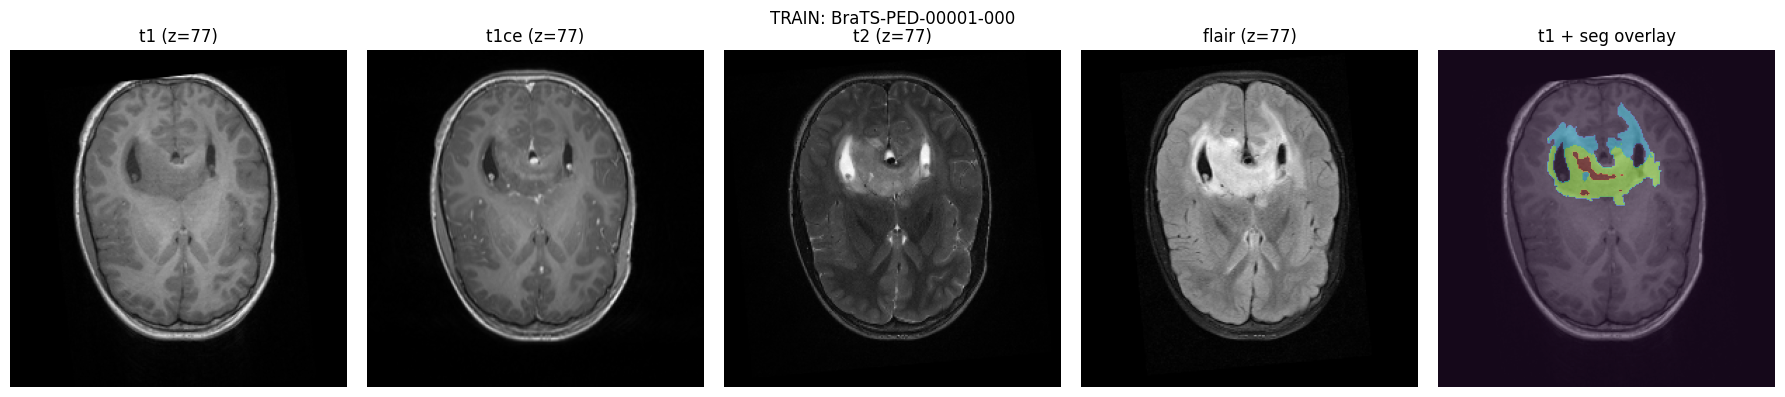

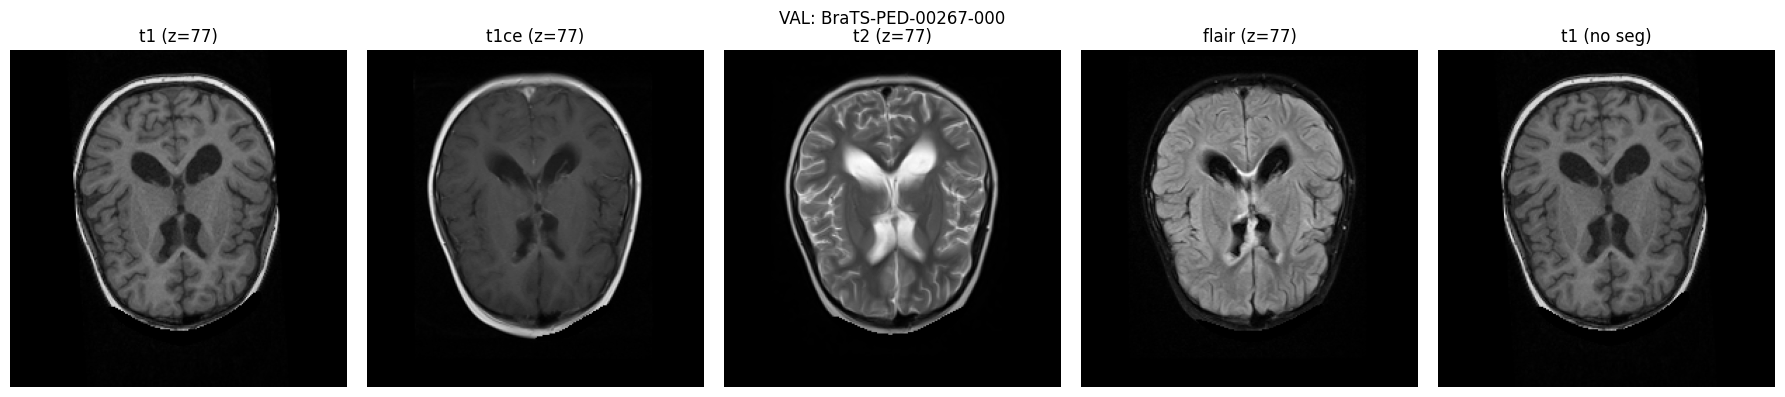

In [34]:
# Section 1D — Visualize: mid-slices + label overlay sanity (train + val)

import matplotlib.pyplot as plt


def _show_case(vols: dict, title: str, z: int | None = None) -> None:
    """Quick sanity: show axial mid-slices for each modality + label overlay if available."""
    t1 = vols["t1"]
    seg = vols.get("seg", None)

    if z is None:
        z = t1.shape[2] // 2

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    fig.suptitle(title)

    for i, key in enumerate(["t1", "t1ce", "t2", "flair"]):
        axes[i].imshow(vols[key][:, :, z].T, cmap="gray", origin="lower")
        axes[i].set_title(f"{key} (z={z})")
        axes[i].axis("off")

    axes[4].imshow(t1[:, :, z].T, cmap="gray", origin="lower")
    if seg is not None:
        seg_i = seg.astype(np.int32)
        axes[4].imshow(seg_i[:, :, z].T, cmap="turbo", origin="lower", alpha=0.45, vmin=0, vmax=4)
        axes[4].set_title("t1 + seg overlay")
    else:
        axes[4].set_title("t1 (no seg)")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()


_show_case(train_vols, title=f"TRAIN: {train_case.name}")
if val_vols is not None:
    _show_case(val_vols, title=f"VAL: {val_case.name}")


## Section 2 — Preprocessing (CRITICAL PHASE)

We implement the roadmap preprocessing steps **in order**:

### 2.1 Orientation & Resolution
- Verify consistent voxel spacing and orientation across modalities.
- For this dataset, affines appear identical across modalities (good), but we still validate programmatically.

### 2.2 Skull Stripping (Mandatory)
- Preferred: HD-BET or a dedicated brain-extraction model.
- Fallback (if not available): conservative brain mask from non-zero union, with explicit warnings.

### 2.3 Intensity Normalization
- Per-subject, per-modality z-score **inside brain mask only**.

At the end of this section we will:
- Print shapes and spacing
- Visualize brain mask overlay
- Confirm tumor labels remain inside the brain mask


In [35]:
# Section 2.1 — Orientation & spacing validation (sample case)

import numpy as np


def _nifti_meta(path: Path) -> dict:
    img = nib.load(str(path))
    hdr = img.header
    zooms = tuple(float(z) for z in hdr.get_zooms()[:3])
    ax = nib.aff2axcodes(img.affine)
    return {
        "path": str(path),
        "shape": tuple(int(x) for x in img.shape[:3]),
        "zooms": zooms,
        "axcodes": ax,
        "affine": np.asarray(img.affine),
    }


# Use the already-indexed sample training case from Section 1C
train_idx = _index_case_files(train_case)
print("Train case:", train_case)

metas = {k: _nifti_meta(train_idx[k]) for k in ["t1", "t1ce", "t2", "flair"]}
for k, m in metas.items():
    print(f"{k}: shape={m['shape']}, zooms={m['zooms']}, axcodes={m['axcodes']}")

# Confirm shapes match
if len({m["shape"] for m in metas.values()}) != 1:
    raise RuntimeError("Shape mismatch across modalities in sample case.")

# Confirm affines are nearly identical
ref = metas["t1"]["affine"]
for k in ["t1ce", "t2", "flair"]:
    diff = float(np.max(np.abs(metas[k]["affine"] - ref)))
    print(f"affine max|Δ| {k} vs t1: {diff:.6f}")

print("\nIf this fails on other cases, we will enforce Orientation=RAS + resampling (MONAI/ITK) before training.")


Train case: /workspace/pediatric_tumor_data/training/BraTS-PEDs2024_Training/BraTS-PED-00001-000
t1: shape=(240, 240, 155), zooms=(1.0, 1.0, 1.0), axcodes=('L', 'P', 'S')
t1ce: shape=(240, 240, 155), zooms=(1.0, 1.0, 1.0), axcodes=('L', 'P', 'S')
t2: shape=(240, 240, 155), zooms=(1.0, 1.0, 1.0), axcodes=('L', 'P', 'S')
flair: shape=(240, 240, 155), zooms=(1.0, 1.0, 1.0), axcodes=('L', 'P', 'S')
affine max|Δ| t1ce vs t1: 0.000000
affine max|Δ| t2 vs t1: 0.000000
affine max|Δ| flair vs t1: 0.000000

If this fails on other cases, we will enforce Orientation=RAS + resampling (MONAI/ITK) before training.


HD-BET CLI: NOT FOUND
brain_mask shape: (240, 240, 155)
brain_mask coverage (fraction): 0.9732384632616488
tumor voxels: 128667
tumor outside mask: 0 fraction: 0.0


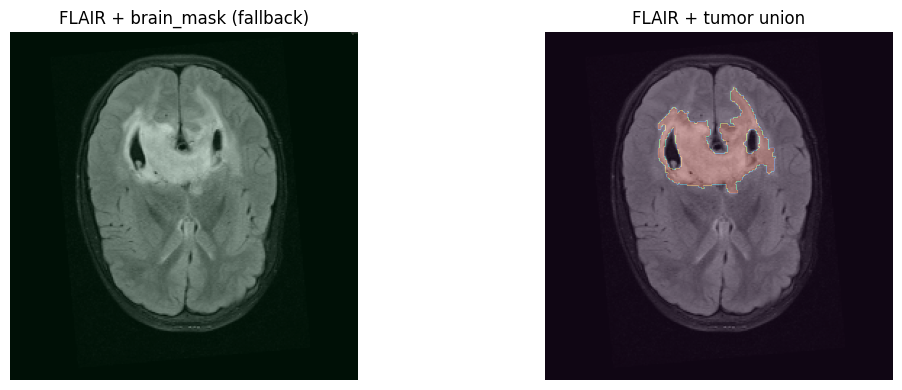


NOTE: If hd-bet is available/installed, we will switch to true skull stripping in the next cell and store brain masks on disk for preprocessing.


In [36]:
# Section 2.2 — Skull stripping (mandatory): HD-BET if available, else conservative fallback

import shutil


def build_conservative_brain_mask(vols: dict) -> np.ndarray:
    """Fallback mask: union of non-zero voxels across modalities.

    This is NOT true skull stripping; it is a conservative proxy.
    We explicitly validate tumor remains inside the mask.
    """
    m = np.zeros_like(vols["t1"], dtype=bool)
    for k in ["t1", "t1ce", "t2", "flair"]:
        m |= vols[k] > 0
    return m


# Detect HD-BET CLI
hd_bet_cli = shutil.which("hd-bet") or shutil.which("HD-BET")
print("HD-BET CLI:", hd_bet_cli if hd_bet_cli else "NOT FOUND")

# For now we demonstrate on the in-memory train_vols from Section 1C
brain_mask = build_conservative_brain_mask(train_vols)

print("brain_mask shape:", brain_mask.shape)
print("brain_mask coverage (fraction):", float(brain_mask.mean()))

# Safety check: tumor should not lie outside mask
if "seg" in train_vols:
    tumor = train_vols["seg"] > 0
    outside = tumor & (~brain_mask)
    frac_outside = float(outside.sum() / (tumor.sum() + 1e-8))
    print("tumor voxels:", int(tumor.sum()))
    print("tumor outside mask:", int(outside.sum()), "fraction:", frac_outside)
    if frac_outside > 1e-4:
        raise RuntimeError(
            "Conservative brain mask excludes tumor voxels. Stop and fix skull stripping/mask creation before continuing."
        )

# Visualize mask boundary + tumor overlay on FLAIR
z = train_vols["t1"].shape[2] // 2

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(train_vols["flair"][:, :, z].T, cmap="gray", origin="lower")
ax[0].imshow(brain_mask[:, :, z].T, cmap="Greens", origin="lower", alpha=0.25)
ax[0].set_title("FLAIR + brain_mask (fallback)")
ax[0].axis("off")

ax[1].imshow(train_vols["flair"][:, :, z].T, cmap="gray", origin="lower")
if "seg" in train_vols:
    ax[1].imshow((train_vols["seg"] > 0)[:, :, z].T, cmap="turbo", origin="lower", alpha=0.35)
ax[1].set_title("FLAIR + tumor union")
ax[1].axis("off")

plt.tight_layout()
plt.show()

print(
    "\nNOTE: If hd-bet is available/installed, we will switch to true skull stripping in the next cell "
    "and store brain masks on disk for preprocessing."
)


t1: normed mean=-0.0000, std=1.0000, shape=(240, 240, 155)
t1ce: normed mean=-0.0000, std=1.0000, shape=(240, 240, 155)
t2: normed mean=0.0000, std=1.0000, shape=(240, 240, 155)
flair: normed mean=-0.0000, std=1.0000, shape=(240, 240, 155)


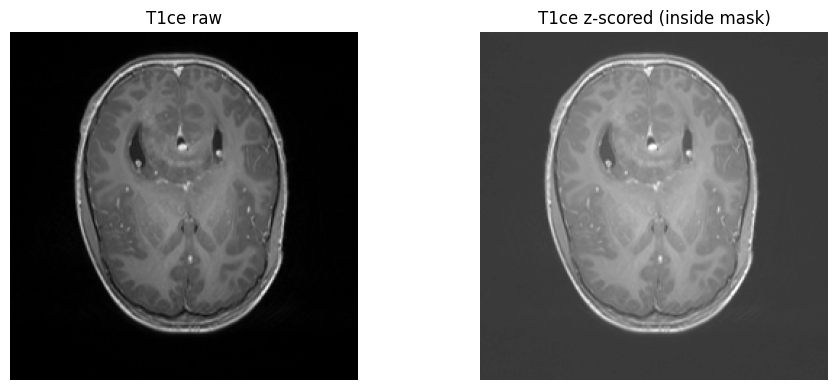


Preprocessing sanity complete for sample. Next: implement on-disk preprocessing + nnU-Net v2 baseline.


In [37]:
# Section 2.3 — Intensity normalization inside brain mask (per-modality, per-subject)

import numpy as np


def zscore_normalize_in_mask(x: np.ndarray, mask: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32, copy=False)
    vals = x[mask]
    mu = float(vals.mean()) if vals.size else float(x.mean())
    sd = float(vals.std()) if vals.size else float(x.std())
    sd = sd + 1e-8
    return (x - mu) / sd


normed = {}
for k in ["t1", "t1ce", "t2", "flair"]:
    normed[k] = zscore_normalize_in_mask(train_vols[k], brain_mask)
    inside = normed[k][brain_mask]
    print(f"{k}: normed mean={float(inside.mean()):.4f}, std={float(inside.std()):.4f}, shape={normed[k].shape}")

# Visual sanity: before/after for one modality
z = train_vols["t1"].shape[2] // 2
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(train_vols["t1ce"][:, :, z].T, cmap="gray", origin="lower")
ax[0].set_title("T1ce raw")
ax[0].axis("off")

ax[1].imshow(normed["t1ce"][:, :, z].T, cmap="gray", origin="lower", vmin=-2, vmax=4)
ax[1].set_title("T1ce z-scored (inside mask)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

print("\nPreprocessing sanity complete for sample. Next: implement on-disk preprocessing + nnU-Net v2 baseline.")


## Section 3 — nnU‑Net v2 Baseline (Setup)

**Goal:** set up nnU‑Net v2 and convert the dataset to nnU‑Net v2 raw format.

**Important constraints:**
- All commands run in this notebook (no terminal-first workflow).
- We will **apply the inferred `LABEL_MAPPING`** to training labels when exporting labels for nnU‑Net.
- Server validation appears unlabeled; we’ll use nnU‑Net CV for baseline metrics, and (optionally) create an internal holdout split later for stricter gating.


In [38]:
# Section 3.1 — Install & validate nnU‑Net v2 (in-notebook)

import os
import sys
import shlex
import shutil
import subprocess
from pathlib import Path


def _run(cmd, check=True):
    """Run a shell command from within notebook and stream output."""
    print(f"$ {cmd}")
    p = subprocess.run(cmd, shell=True)
    if check and p.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {p.returncode}: {cmd}")


# nnU-Net v2 import probe
try:
    import nnunetv2  # noqa: F401
    has_nnunet = True
except Exception as e:
    has_nnunet = False
    print("nnunetv2 import failed:", repr(e))


if not has_nnunet:
    print("Installing nnunetv2 via pip (this may take a minute)...")
    _run(f"{shlex.quote(sys.executable)} -m pip install -U nnunetv2")

    import nnunetv2  # noqa: F401
    has_nnunet = True

print("nnunetv2 import: OK")

# Validate CLIs are on PATH (kernel PATH may differ from system PATH)
clis = [
    "nnUNetv2_plan_and_preprocess",
    "nnUNetv2_train",
    "nnUNetv2_predict",
]
for c in clis:
    print(f"{c}:", shutil.which(c) or "NOT FOUND on PATH")

print("\nIf CLIs are NOT FOUND, restart the kernel once after install; entrypoints should then be visible. We can also fall back to module execution if needed.")


nnunetv2 import: OK
nnUNetv2_plan_and_preprocess: /usr/local/bin/nnUNetv2_plan_and_preprocess
nnUNetv2_train: /usr/local/bin/nnUNetv2_train
nnUNetv2_predict: /usr/local/bin/nnUNetv2_predict

If CLIs are NOT FOUND, restart the kernel once after install; entrypoints should then be visible. We can also fall back to module execution if needed.


In [39]:
# Section 3.2 — Configure nnU‑Net v2 environment paths

from pathlib import Path
import os


def _ensure_dir(p: Path) -> Path:
    p.mkdir(parents=True, exist_ok=True)
    return p


# Base path: keep everything under the dataset root for locality
# training_main_dir is expected to be a PosixPath like /workspace/pediatric_tumor_data/training/...
base_root = Path(str(training_main_dir)).parents[1]  # /workspace/pediatric_tumor_data
nnunet_base = _ensure_dir(base_root / "nnunetv2")

nnUNet_raw = _ensure_dir(nnunet_base / "nnUNet_raw")
nnUNet_preprocessed = _ensure_dir(nnunet_base / "nnUNet_preprocessed")
nnUNet_results = _ensure_dir(nnunet_base / "nnUNet_results")

os.environ["nnUNet_raw"] = str(nnUNet_raw)
os.environ["nnUNet_preprocessed"] = str(nnUNet_preprocessed)
os.environ["nnUNet_results"] = str(nnUNet_results)

print("nnUNet_raw:", os.environ["nnUNet_raw"])
print("nnUNet_preprocessed:", os.environ["nnUNet_preprocessed"])
print("nnUNet_results:", os.environ["nnUNet_results"])

# Dataset identifiers
DATASET_ID = 501
DATASET_NAME = "BraTS_PEDs2024"
DATASET_FOLDER = nnUNet_raw / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"

print("\nDataset folder:", DATASET_FOLDER)


nnUNet_raw: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw
nnUNet_preprocessed: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed
nnUNet_results: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results

Dataset folder: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw/Dataset501_BraTS_PEDs2024


In [40]:
# Section 3.3 — Export BraTS PEDs dataset to nnU‑Net v2 raw format (with label remap)

import os
import re
import json
import shutil
import numpy as np
import nibabel as nib
from pathlib import Path


# Safer default for reruns: do not rebuild unless explicitly requested.
OVERWRITE_DATASET = False


def _safe_mkdir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)


def _count_nii_gz(p: Path) -> int:
    return len(list(p.glob("*.nii.gz")))


def _link_or_copy(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        return
    try:
        os.link(str(src), str(dst))
    except Exception:
        shutil.copy2(str(src), str(dst))


# Export-time modality matching. We cannot rely on older in-kernel patterns.
# Supports both BraTS2025-style tokens (t1n/t1c/t2w/t2f) and common aliases.
EXPORT_MODALITY_PATTERNS = {
    "t1": [re.compile(r"(^|[^a-z0-9])t1n([^a-z0-9]|$)"), re.compile(r"(^|[^a-z0-9])t1([^a-z0-9]|$)")],
    "t1ce": [re.compile(r"(^|[^a-z0-9])t1c([^a-z0-9]|$)"), re.compile(r"t1ce|t1gd|t1c\b")],
    "t2": [re.compile(r"(^|[^a-z0-9])t2w([^a-z0-9]|$)"), re.compile(r"(^|[^a-z0-9])t2([^a-z0-9]|$)")],
    "flair": [re.compile(r"(^|[^a-z0-9])t2f([^a-z0-9]|$)"), re.compile(r"flair")],
}


def _any_match(pats, text: str) -> bool:
    for p in pats:
        if p.search(text):
            return True
    return False


def _index_case_files(case_dir: Path):
    """Return ({modality_key: path}, seg_path_or_None)."""
    files = list(case_dir.glob("*.nii")) + list(case_dir.glob("*.nii.gz"))
    if not files:
        raise FileNotFoundError(f"No NIfTI files in {case_dir}")

    mods = {}
    seg = None

    for f in files:
        name = f.name.lower()
        if "seg" in name and (".nii" in name):
            seg = f
            continue

        for mod_key, pats in EXPORT_MODALITY_PATTERNS.items():
            if _any_match(pats, name):
                mods[mod_key] = f
                break

    return mods, seg


def _load_and_remap_seg(seg_path: Path, mapping: dict) -> nib.Nifti1Image:
    img = nib.load(str(seg_path))
    data = img.get_fdata(dtype=np.float32)

    rounded = np.rint(data)
    max_abs_err = float(np.max(np.abs(data - rounded)))
    if max_abs_err > 1e-3:
        raise ValueError(f"Seg appears non-integer-coded: max_abs_err={max_abs_err} at {seg_path}")

    seg_int = rounded.astype(np.int16)

    out = np.zeros_like(seg_int, dtype=np.int16)
    for k, v in mapping.items():
        out[seg_int == int(k)] = int(v)

    uniq = set(np.unique(out).tolist())
    allowed = {0, 1, 2, 4}
    if not uniq.issubset(allowed):
        raise ValueError(f"Remapped seg contains unexpected labels {sorted(uniq)} from {seg_path}")

    return nib.Nifti1Image(out, img.affine, img.header)


# Paths
imagesTr = DATASET_FOLDER / "imagesTr"
labelsTr = DATASET_FOLDER / "labelsTr"
imagesTs = DATASET_FOLDER / "imagesTs"

expected_imagesTr = 4 * len(train_cases)
expected_labelsTr = len(train_cases)
expected_imagesTs = 4 * len(val_cases)

if DATASET_FOLDER.exists() and not OVERWRITE_DATASET:
    if (DATASET_FOLDER / "dataset.json").exists() and imagesTr.exists() and labelsTr.exists() and imagesTs.exists():
        n_imgsTr = _count_nii_gz(imagesTr)
        n_lblsTr = _count_nii_gz(labelsTr)
        n_imgsTs = _count_nii_gz(imagesTs)

        if (n_imgsTr, n_lblsTr, n_imgsTs) == (expected_imagesTr, expected_labelsTr, expected_imagesTs):
            print("nnU-Net raw export already present; skipping rebuild.")
            print("imagesTr:", n_imgsTr, "labelsTr:", n_lblsTr, "imagesTs:", n_imgsTs)
            n_train_written = expected_labelsTr
            n_val_written = len(val_cases)
        else:
            raise RuntimeError(
                "Dataset folder exists but counts do not match expected. "
                f"Found imagesTr={n_imgsTr} labelsTr={n_lblsTr} imagesTs={n_imgsTs}; "
                f"expected imagesTr={expected_imagesTr} labelsTr={expected_labelsTr} imagesTs={expected_imagesTs}. "
                "Set OVERWRITE_DATASET=True to rebuild."
            )
    else:
        raise RuntimeError(
            "Dataset folder exists but is missing expected subfolders/files. "
            "Set OVERWRITE_DATASET=True to rebuild."
        )


if OVERWRITE_DATASET:
    if DATASET_FOLDER.exists():
        shutil.rmtree(DATASET_FOLDER)

    for p in [imagesTr, labelsTr, imagesTs]:
        _safe_mkdir(p)

    channel_order = ["t1", "t1ce", "t2", "flair"]
    channel_names = {str(i): name for i, name in enumerate(["T1", "T1ce", "T2", "FLAIR"])}
    label_names = {"background": 0, "TC": 1, "ED": 2, "ET": 4}

    n_train_written = 0
    missing_train = 0

    for case_dir in train_cases:
        case_dir = Path(str(case_dir))
        case_id = case_dir.name

        mods, seg = _index_case_files(case_dir)

        missing = [m for m in channel_order if m not in mods]
        if missing or seg is None:
            missing_train += 1
            continue

        for i, mod_key in enumerate(channel_order):
            src = mods[mod_key]
            dst = imagesTr / f"{case_id}_{i:04d}.nii.gz"
            _link_or_copy(src, dst)

        remapped = _load_and_remap_seg(seg, LABEL_MAPPING)
        nib.save(remapped, str(labelsTr / f"{case_id}.nii.gz"))

        n_train_written += 1

    print(f"Training exported: {n_train_written} cases")
    print(f"Training skipped (missing data): {missing_train} cases")

    n_val_written = 0
    missing_val = 0

    for case_dir in val_cases:
        case_dir = Path(str(case_dir))
        case_id = case_dir.name

        mods, seg = _index_case_files(case_dir)

        missing = [m for m in channel_order if m not in mods]
        if missing:
            missing_val += 1
            continue

        for i, mod_key in enumerate(channel_order):
            src = mods[mod_key]
            dst = imagesTs / f"{case_id}_{i:04d}.nii.gz"
            _link_or_copy(src, dst)

        n_val_written += 1

    print(f"imagesTs exported: {n_val_written} cases")
    print(f"imagesTs skipped (missing data): {missing_val} cases")

    dataset_json_path = DATASET_FOLDER / "dataset.json"
    dataset_json = {
        "name": DATASET_NAME,
        "description": "BraTS PEDs export with label remap to {0,1,2,4}",
        "tensorImageSize": "3D",
        "reference": "BraTS PEDs",
        "licence": "unknown",
        "release": "0.0",
        "channel_names": channel_names,
        "labels": {k: int(v) for k, v in label_names.items()},
        "numTraining": int(n_train_written),
        "file_ending": ".nii.gz",
    }

    dataset_json_path.write_text(json.dumps(dataset_json, indent=2))
    print("Wrote:", dataset_json_path)


nnU-Net raw export already present; skipping rebuild.
imagesTr: 1044 labelsTr: 261 imagesTs: 364


In [41]:
# Section 3.4 — Sanity-check nnU‑Net export

from pathlib import Path

imagesTr = DATASET_FOLDER / "imagesTr"
labelsTr = DATASET_FOLDER / "labelsTr"
imagesTs = DATASET_FOLDER / "imagesTs"

def _count(pattern, root):
    return len(list(Path(root).glob(pattern)))

n_imgsTr = _count("*.nii.gz", imagesTr)
n_lblsTr = _count("*.nii.gz", labelsTr)
n_imgsTs = _count("*.nii.gz", imagesTs)

print("Dataset:", DATASET_FOLDER.name)
print("imagesTr NIfTI:", n_imgsTr)
print("labelsTr NIfTI:", n_lblsTr)
print("imagesTs NIfTI:", n_imgsTs)

# Each training case should contribute 4 images + 1 label
if n_lblsTr > 0:
    est_train_cases = n_imgsTr // 4
    print("Estimated training cases from imagesTr:", est_train_cases)
    print("Label files:", n_lblsTr)
    if est_train_cases != n_lblsTr:
        print("WARNING: imagesTr/labelsTr case count mismatch.")

# Quick spot-check a few label uniques (remapped ontology)
import random
import numpy as np
import nibabel as nib

lbl_paths = sorted(list(labelsTr.glob("*.nii.gz")))
for p in random.sample(lbl_paths, k=min(3, len(lbl_paths))):
    arr = np.asanyarray(nib.load(str(p)).dataobj)
    uniq = np.unique(arr)
    print(p.name, "unique labels:", uniq[:20], "(n=", len(uniq), ")")


Dataset: Dataset501_BraTS_PEDs2024
imagesTr NIfTI: 1044
labelsTr NIfTI: 261
imagesTs NIfTI: 364
Estimated training cases from imagesTr: 261
Label files: 261
BraTS-PED-00193-000.nii.gz unique labels: [0 2 4] (n= 3 )
BraTS-PED-00088-000.nii.gz unique labels: [0 1 2 4] (n= 4 )
BraTS-PED-00176-000.nii.gz unique labels: [0 1 2 4] (n= 4 )


In [42]:
# Section 3.6 — nnU‑Net v2 planning/preprocessing + training commands
# NOTE: These steps are compute-heavy. Start with planning/preprocessing; then train fold 0.

import subprocess


def run_cmd(cmd: str, check: bool = True):
    print(f"$ {cmd}")
    p = subprocess.run(cmd, shell=True)
    if check and p.returncode != 0:
        raise RuntimeError(f"Command failed ({p.returncode}): {cmd}")


DATASET_ID = int(DATASET_ID)

plan_cmd = f"nnUNetv2_plan_and_preprocess -d {DATASET_ID} --verify_dataset_integrity"
train_cmd = f"nnUNetv2_train {DATASET_ID} 3d_fullres 0"

print("Planned commands:")
print(" -", plan_cmd)
print(" -", train_cmd)

# Uncomment to run:
# run_cmd(plan_cmd)
# run_cmd(train_cmd)


Planned commands:
 - nnUNetv2_plan_and_preprocess -d 501 --verify_dataset_integrity
 - nnUNetv2_train 501 3d_fullres 0


## Section 3.7 — nnU‑Net v2 Planning/Preprocessing (Run)

This will run nnU‑Net v2 dataset verification + planning + preprocessing for Dataset 501.

- This can take a while.
- If it fails, we stop and fix the root cause before training.


In [44]:
# Section 3.7.0 — nnU‑Net label fix: make labels consecutive (ET 4 -> 3)
# nnU‑Net v2 requires labels to be consecutive: {0,1,2,3,...}
# Our BraTS-style export uses {0,1,2,4}, so we convert ET=4 -> 3 for nnU‑Net.

import json
import numpy as np
import nibabel as nib
from pathlib import Path


labelsTr = DATASET_FOLDER / "labelsTr"
dataset_json_path = DATASET_FOLDER / "dataset.json"


def _unique_labels_in_file(p: Path) -> set:
    arr = np.asanyarray(nib.load(str(p)).dataobj)
    return set(np.unique(arr).tolist())


def _rewrite_et_4_to_3(p: Path) -> bool:
    img = nib.load(str(p))
    arr = np.asanyarray(img.dataobj).astype(np.int16)
    if 4 not in arr:
        return False
    arr = arr.copy()
    arr[arr == 4] = 3
    nib.save(nib.Nifti1Image(arr, img.affine, img.header), str(p))
    return True


lbl_files = sorted(labelsTr.glob("*.nii.gz"))
if len(lbl_files) == 0:
    raise RuntimeError(f"No label files found in {labelsTr}")

# Quick scan a subset to see if conversion is needed
sample_files = lbl_files[:: max(1, len(lbl_files)//10)]
uniqs = set()
for p in sample_files:
    uniqs |= _unique_labels_in_file(p)

print("Sampled unique labels (pre):", sorted(uniqs))

if 4 in uniqs:
    changed = 0
    for p in lbl_files:
        if _rewrite_et_4_to_3(p):
            changed += 1
    print("Converted ET 4->3 in label files touched:", changed)
else:
    print("No 4 detected in sample; assuming labels are already consecutive.")

# Verify a few files again
uniqs_post = set()
for p in sample_files:
    uniqs_post |= _unique_labels_in_file(p)
print("Sampled unique labels (post):", sorted(uniqs_post))

# Update dataset.json labels mapping for nnU-Net
if dataset_json_path.exists():
    ds = json.loads(dataset_json_path.read_text())
    if "labels" in ds and "ET" in ds["labels"]:
        ds["labels"]["ET"] = 3
        dataset_json_path.write_text(json.dumps(ds, indent=2))
        print("Updated dataset.json: ET=3")

# Store mapping so later evaluation can map nnU-Net ET(3) back to BraTS ET(4) if needed
NNUNET_LABEL_MAP = {0: 0, 1: 1, 2: 2, 3: 4}
print("NNUNET_LABEL_MAP (nnU-Net -> BraTS):", NNUNET_LABEL_MAP)


Sampled unique labels (pre): [0, 1, 2, 4]
Converted ET 4->3 in label files touched: 192
Sampled unique labels (post): [0, 1, 2, 3]
Updated dataset.json: ET=3
NNUNET_LABEL_MAP (nnU-Net -> BraTS): {0: 0, 1: 1, 2: 2, 3: 4}


In [48]:
# Section 3.7.0b — Fix nnU‑Net raw images that are named `.nii.gz` but are not gzip
# nnU-Net uses SimpleITK; SimpleITK will fail if a file ends with `.nii.gz` but is not actually gzip.
# We fix this by rewriting such files as real gzip-compressed files.
# IMPORTANT: nnU‑Net exports may be hardlinks to the source dataset. We always rewrite via atomic
# replace (temp file + os.replace) so we break hardlinks and never mutate the original dataset.

import os
import gzip
import shutil
from pathlib import Path


imagesTr = DATASET_FOLDER / "imagesTr"
imagesTs = DATASET_FOLDER / "imagesTs"


def is_gzip_file(path: Path) -> bool:
    try:
        with gzip.open(path, "rb") as f:
            f.read(1)
        return True
    except Exception:
        return False


def rewrite_as_gzip(path: Path) -> None:
    """Wrap raw bytes of `path` into a gzip stream and atomically replace the file."""
    tmp = path.with_suffix(path.suffix + ".tmp")  # *.nii.gz.tmp

    # Read raw bytes from the current file (may be uncompressed NIfTI but misnamed)
    with open(path, "rb") as fin, gzip.open(tmp, "wb") as fout:
        shutil.copyfileobj(fin, fout)

    # Atomic replace breaks hardlinks and avoids partial writes.
    os.replace(str(tmp), str(path))


def fix_folder(folder: Path) -> int:
    fixed = 0
    for p in sorted(folder.glob("*.nii.gz")):
        if not is_gzip_file(p):
            rewrite_as_gzip(p)
            fixed += 1
    return fixed


# Fix both train/test image folders
fixed_tr = fix_folder(imagesTr)
fixed_ts = fix_folder(imagesTs)

print("Fixed mislabeled .nii.gz (not gzip):")
print(" - imagesTr:", fixed_tr)
print(" - imagesTs:", fixed_ts)

# Sanity check: known previously failing file should now be gzip
known = imagesTr / "BraTS-PED-00255-000_0001.nii.gz"
print("Known file gzip now:", is_gzip_file(known))


Fixed mislabeled .nii.gz (not gzip):
 - imagesTr: 1
 - imagesTs: 0
Known file gzip now: True


In [56]:
# Section 3.7.0c — Targeted fix for a SimpleITK-unreadable file

# If the source file is corrupt (not a real NIfTI), we quarantine the entire case from nnU-Net export
# and update dataset.json (numTraining / optional training list) accordingly.

import json
import os
import shutil
import nibabel as nib
import SimpleITK as sitk
from pathlib import Path

# Known failing nnU-Net file from integrity check
bad = Path("/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw/Dataset501_BraTS_PEDs2024/imagesTr/BraTS-PED-00255-000_0001.nii.gz")

# Corresponding source modality in original dataset (channel 0001 -> T1c)
src = Path(str(training_main_dir)) / "BraTS-PED-00255-000" / "BraTS-PED-00255-000-t1c.nii.gz"

case_id = "BraTS-PED-00255-000"
imagesTr_dir = bad.parent
dataset_root = imagesTr_dir.parent
labelsTr_dir = dataset_root / "labelsTr"
dataset_json_path = dataset_root / "dataset.json"

def _case_ids_from_labels(labels_dir: Path) -> list[str]:
    ids: list[str] = []
    for f in sorted(labels_dir.glob("*.nii.gz")):
        ids.append(f.name.removesuffix(".nii.gz"))
    return ids

def update_dataset_json_num_training():
    if not dataset_json_path.exists():
        print("[WARN] dataset.json not found at", dataset_json_path)
        return
    with open(dataset_json_path, "r") as f:
        js = json.load(f)
    case_ids = _case_ids_from_labels(labelsTr_dir)
    js["numTraining"] = len(case_ids)
    if isinstance(js.get("training"), list):
        kept = []
        for item in js["training"]:
            lbl = (item.get("label") or "")
            ok = any(cid in lbl for cid in case_ids)
            if ok:
                kept.append(item)
        js["training"] = kept
    with open(dataset_json_path, "w") as f:
        json.dump(js, f, indent=2)
    print(f"[OK] Updated dataset.json numTraining={js['numTraining']}")

def quarantine_case(case_id: str, reason: str):
    qroot = dataset_root / "quarantine_corrupt"
    q_images = qroot / "imagesTr"
    q_labels = qroot / "labelsTr"
    q_images.mkdir(parents=True, exist_ok=True)
    q_labels.mkdir(parents=True, exist_ok=True)
    moved = []
    for f in sorted(imagesTr_dir.glob(f"{case_id}_000*.nii.gz")):
        dst = q_images / f.name
        os.replace(str(f), str(dst))
        moved.append(dst)
    lbl = labelsTr_dir / f"{case_id}.nii.gz"
    if lbl.exists():
        dst = q_labels / lbl.name
        os.replace(str(lbl), str(dst))
        moved.append(dst)
    print(f"[QUARANTINE] {case_id}: {reason}")
    print(f"[QUARANTINE] moved {len(moved)} file(s) to {qroot}")
    for m in moved:
        print("  -", m)
    update_dataset_json_num_training()
    return moved

print("case:", case_id)
print("bad:", bad)
print("src:", src)
print("bad exists:", bad.exists(), "src exists:", src.exists())
if src.exists():
    print("src size (bytes):", src.stat().st_size)
if bad.exists():
    print("bad size (bytes):", bad.stat().st_size)

if not src.exists():
    raise FileNotFoundError(f"Source missing: {src}")

# If we've already quarantined the case, just ensure dataset.json is consistent.
if not bad.exists():
    print("[INFO] bad file not present (likely already quarantined).")
    update_dataset_json_num_training()
else:
    # Attempt to rewrite bad from src. If that fails, quarantine the case.
    tmp_dir = imagesTr_dir / "_repair_tmp"
    tmp_dir.mkdir(parents=True, exist_ok=True)
    src_tmp_nii = tmp_dir / (src.name.removesuffix(".nii.gz") + ".nii")
    out_tmp = tmp_dir / bad.name

    # Copy source bytes without touching the original file
    shutil.copyfile(src, src_tmp_nii)

    wrote = False
    errors = []

    # Attempt 1: nibabel (often works for uncompressed NIfTI)
    try:
        img = nib.load(str(src_tmp_nii))
        nib.save(img, str(out_tmp))
        wrote = True
        print("[OK] Rewrote via nibabel.")
    except Exception as e:
        errors.append(f"nibabel: {e}")

    # Attempt 2: SimpleITK fallback
    if not wrote:
        try:
            img = sitk.ReadImage(str(src_tmp_nii))
            sitk.WriteImage(img, str(out_tmp))
            wrote = True
            print("[OK] Rewrote via SimpleITK.")
        except Exception as e:
            errors.append(f"SimpleITK: {e}")

    if wrote:
        # Atomically replace to break any hardlink and ensure nnU-Net sees the repaired file
        os.replace(str(out_tmp), str(bad))
        # Validate with SimpleITK
        _ = sitk.ReadImage(str(bad))
        print("[OK] SimpleITK can read the repaired file.")
    else:
        # Diagnostics: show magic bytes and NIfTI header hints
        with open(src_tmp_nii, "rb") as f:
            head = f.read(512)
        magic2 = head[:2]
        magic4 = head[:4]
        nifti_magic = head[344:348] if len(head) >= 348 else b""
        print("[DIAG] first2:", magic2, "first4:", magic4, "nifti_magic@344:", nifti_magic)
        quarantine_case(case_id, reason="; ".join(errors))

case: BraTS-PED-00255-000
bad: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw/Dataset501_BraTS_PEDs2024/imagesTr/BraTS-PED-00255-000_0001.nii.gz
src: /workspace/pediatric_tumor_data/training/BraTS-PEDs2024_Training/BraTS-PED-00255-000/BraTS-PED-00255-000-t1c.nii.gz
bad exists: False src exists: True
src size (bytes): 20492405
[INFO] bad file not present (likely already quarantined).
[OK] Updated dataset.json numTraining=260


In [57]:
# Section 3.7.1 — Run nnU-Net v2 planning + preprocessing

import os
import subprocess


def _cmd_help_contains(cmd: str, needle: str) -> bool:
    try:
        p = subprocess.run([cmd, "-h"], capture_output=True, text=True)
        txt = (p.stdout or "") + "\n" + (p.stderr or "")
        return needle in txt
    except Exception:
        return False


def run_cmd(cmd: str, check: bool = True):
    print(f"$ {cmd}")
    p = subprocess.run(cmd, shell=True)
    if check and p.returncode != 0:
        raise RuntimeError(f"Command failed ({p.returncode}): {cmd}")


# Keep preprocessing reasonably parallel but not insane by default.
# You can tune these if your server has more/less CPU cores.
os.environ.setdefault("nnUNet_n_proc_DA", "8")

use_c_flag = _cmd_help_contains("nnUNetv2_plan_and_preprocess", "-c")

base = f"nnUNetv2_plan_and_preprocess -d {int(DATASET_ID)} --verify_dataset_integrity"
cmd = base + (" -c 3d_fullres" if use_c_flag else "")

print("Will run:")
print(cmd)

run_cmd(cmd)
print("\n[OK] Planning/preprocessing completed.")


Will run:
nnUNetv2_plan_and_preprocess -d 501 --verify_dataset_integrity -c 3d_fullres
$ nnUNetv2_plan_and_preprocess -d 501 --verify_dataset_integrity -c 3d_fullres
Fingerprint extraction...
Dataset501_BraTS_PEDs2024
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer


100%|██████████| 260/260 [00:44<00:00,  5.82it/s]


Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [155. 240. 222.], 3d_lowres: [155, 240, 222]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 56, 'patch_size': (256, 224), 'median_image_size_in_voxels': array([240., 222.]), 'spacing': array([1., 1.]), 'normalization_schemes': ['ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization'], 'use_mask_for_norm': [False, False, False, False], 'resampling_fn_data': 'resample_data_or_seg_to_shape', 'resampling_fn_seg': 'resample_data_or_seg_to_shape', 'resampling_fn_data_kwargs': {'is_seg': F

100%|██████████| 260/260 [10:16<00:00,  2.37s/it]



[OK] Planning/preprocessing completed.


## Section 3.8 — nnU‑Net v2 Baseline Training (Start)

We’ll start **fold 0** training for `3d_fullres`.

Training can take hours; to keep the notebook responsive, we launch training in the background and write logs to disk.


### Citation (nnU‑Net)
If you use nnU‑Net in this project, please cite:
- Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). *nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation*. **Nature Methods, 18**(2), 203–211.

### Speed notes (why epochs can differ by fold)
In nnU‑Net v2, different folds **should not** be ~5× slower by themselves if config/hardware are unchanged. Big slowdowns are usually due to:
- Running a different config (e.g., `2d` vs `3d_fullres`)
- GPU starving (data augmentation / I/O bottleneck)
- Environment flags like `nnUNet_n_proc_DA` (augmentation workers) or `nnUNet_compile=0`
- Running on a smaller/contended MIG slice (or CPU-only by accident)


In [ ]:
# Speed tuning / diagnostics (run BEFORE launching a fold)
import os
import shutil
import subprocess
import multiprocessing
print("CPU cores:", multiprocessing.cpu_count())
print("nnUNet_n_proc_DA:", os.environ.get("nnUNet_n_proc_DA"))
print("nnUNet_compile:", os.environ.get("nnUNet_compile"))
print()
print("Tips:")
print("- If GPU is starved, try: os.environ['nnUNet_n_proc_DA']='8' (or '12' if you have CPU/RAM)")
print("- If you previously set nnUNet_compile=0 for stability, consider removing it for speed")
print("- These env vars only affect NEW training processes (they won't change a fold already running).")
print()
if shutil.which("nvidia-smi"):
    print("nvidia-smi -L:")
    subprocess.run("nvidia-smi -L", shell=True, check=False)
    print("\nQuick utilization sampling (may be limited under MIG/permissions):")
    # dmon often works better than the default table under MIG
    subprocess.run("nvidia-smi dmon -s pucvmt -d 1 -c 5", shell=True, check=False)
else:
    print("nvidia-smi not available in this kernel environment.")

In [58]:
# Section 3.8.1 — Launch nnU-Net training fold 0 in background (log to file)

import os
import time
import subprocess
from pathlib import Path


def _timestamp() -> str:
    return time.strftime("%Y%m%d_%H%M%S")


run_root = Path(os.environ["nnUNet_results"]) / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

log_path = run_root / f"nnunetv2_train_d{int(DATASET_ID)}_3d_fullres_fold0_{_timestamp()}.log"

train_cmd = [
    "nnUNetv2_train",
    str(int(DATASET_ID)),
    "3d_fullres",
    "0",
]

print("Launching:")
print(" ".join(train_cmd))
print("Log:", str(log_path))

with open(log_path, "w", buffering=1) as f:
    train_proc = subprocess.Popen(train_cmd, stdout=f, stderr=subprocess.STDOUT, text=True)

print("Started PID:", train_proc.pid)
print("\nUse the next cell to monitor logs and confirm it’s progressing.")


Launching:
nnUNetv2_train 501 3d_fullres 0
Log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_train_d501_3d_fullres_fold0_20260108_021751.log
Started PID: 1128629

Use the next cell to monitor logs and confirm it’s progressing.


In [64]:
# Section 3.8.2 — Monitor training log (tail + status)

import os
import time
import subprocess
from pathlib import Path


def tail(path: Path, n: int = 80) -> str:
    try:
        with open(path, "r", errors="replace") as f:
            lines = f.readlines()
        return "".join(lines[-n:])
    except FileNotFoundError:
        return f"(log not found yet: {path})"


print("Log:", str(log_path))
if log_path.exists():
    st = log_path.stat()
    print(f"size={st.st_size} bytes  mtime={time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(st.st_mtime))}")
else:
    print("(log file does not exist yet)")

print("\n--- tail ---")
print(tail(log_path, n=120) or "(no text yet)")

alive = train_proc.poll() is None
print("\nProcess alive:", alive)
print("PID:", train_proc.pid)
if alive:
    try:
        # Lightweight sanity check that the PID is still present
        r = subprocess.run(["ps", "-p", str(train_proc.pid), "-o", "pid,etime,cmd"], capture_output=True, text=True)
        print("\n--- ps ---")
        print((r.stdout or r.stderr).strip())
    except Exception as e:
        print("[WARN] Could not query process status:", e)
else:
    print("Exit code:", train_proc.returncode)
    print("If the log is empty, it may have failed very early.")

Log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_train_d501_3d_fullres_fold0_20260108_021751.log
size=1052 bytes  mtime=2026-01-08 02:18:04

--- tail ---

############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-01-08 02:17:59.670449: Using torch.compile...
2026-01-08 02:18:00.380803: do_dummy_2d_data_aug: False


In [61]:
# Section 3.8.3 — (Optional) Schedule folds 1–4 sequentially after fold 0 completes

import os
import time
import subprocess
from pathlib import Path


def _timestamp() -> str:
    return time.strftime("%Y%m%d_%H%M%S")


run_root = Path(os.environ["nnUNet_results"]) / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

pid0 = int(train_proc.pid)
dataset_id = int(DATASET_ID)
config = "3d_fullres"

script_path = run_root / f"nnunetv2_schedule_folds1to4_after_fold0_{_timestamp()}.sh"
scheduler_log = run_root / f"nnunetv2_scheduler_{_timestamp()}.log"

script = f"""#!/usr/bin/env bash
set -euo pipefail

export PYTHONUNBUFFERED=1

echo "[scheduler] waiting for fold0 pid={pid0} at $(date)"
while kill -0 {pid0} >/dev/null 2>&1; do
  sleep 60
done
echo "[scheduler] fold0 finished at $(date)"

for fold in 1 2 3 4; do
  log=\"{run_root}/nnunetv2_train_d{dataset_id}_{config}_fold${{fold}}_{_timestamp()}.log\"
  echo "[scheduler] starting fold=${{fold}} at $(date); log=${{log}}"
  nnUNetv2_train {dataset_id} {config} ${{fold}} > \"${{log}}\" 2>&1
  echo "[scheduler] finished fold=${{fold}} at $(date)"
done

echo "[scheduler] all folds done at $(date)"
"""

script_path.write_text(script)
script_path.chmod(0o755)

print("Wrote scheduler script:", script_path)
print("Scheduler log:", scheduler_log)
print("This will NOT start new folds until fold 0 (PID above) exits.")

# Start in background (persists independently of the notebook cell)
cmd = f"nohup bash {script_path} > {scheduler_log} 2>&1 & echo $!"
print("$", cmd)
out = subprocess.check_output(cmd, shell=True, text=True).strip()
scheduler_pid = int(out)
print("Started scheduler PID:", scheduler_pid)

Wrote scheduler script: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_schedule_folds1to4_after_fold0_20260108_022143.sh
Scheduler log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_scheduler_20260108_022143.log
This will NOT start new folds until fold 0 (PID above) exits.
$ nohup bash /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_schedule_folds1to4_after_fold0_20260108_022143.sh > /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_scheduler_20260108_022143.log 2>&1 & echo $!
Started scheduler PID: 1132222


In [65]:
# Section 3.8.4 — Monitor scheduler log (tail + status)

import time
import subprocess
from pathlib import Path


def tail(path: Path, n: int = 120) -> str:
    try:
        with open(path, "r", errors="replace") as f:
            lines = f.readlines()
        return "".join(lines[-n:])
    except FileNotFoundError:
        return f"(log not found yet: {path})"


print("Scheduler log:", str(scheduler_log))
if scheduler_log.exists():
    st = scheduler_log.stat()
    print(f"size={st.st_size} bytes  mtime={time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(st.st_mtime))}")
else:
    print("(scheduler log file does not exist yet)")

print("\n--- tail ---")
print(tail(scheduler_log, n=200) or "(no text yet)")

alive = subprocess.run(["bash", "-lc", f"kill -0 {int(scheduler_pid)} 2>/dev/null"], capture_output=True).returncode == 0
print("\nScheduler alive:", alive)
print("Scheduler PID:", int(scheduler_pid))

Scheduler log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_scheduler_20260108_022143.log
size=74 bytes  mtime=2026-01-08 02:21:43

--- tail ---
[scheduler] waiting for fold0 pid=1128629 at Thu Jan  8 02:21:43 UTC 2026


Scheduler alive: True
Scheduler PID: 1132222


In [66]:
# Section 3.8.5 — Training progress snapshot (server-side only)

import os
import time
import shutil
import subprocess
from pathlib import Path


def _run(cmd: str) -> None:
    print("$", cmd)
    p = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    out = ((p.stdout or "") + (p.stderr or "")).strip()
    print(out if out else "(no output)")
    print()


print("Time:", time.strftime("%Y-%m-%d %H:%M:%S"))
print("CWD:", os.getcwd())
print()

# 1) GPU status
if shutil.which("nvidia-smi"):
    _run("nvidia-smi --query-gpu=index,name,utilization.gpu,utilization.memory,memory.used,memory.total --format=csv")
else:
    print("nvidia-smi not found in this notebook environment.")
    try:
        import torch
        print("torch.cuda.is_available():", torch.cuda.is_available())
        if torch.cuda.is_available():
            print("device:", torch.cuda.get_device_name(0))
            print("mem_allocated (GiB):", round(torch.cuda.memory_allocated(0) / (1024**3), 3))
            print("mem_reserved  (GiB):", round(torch.cuda.memory_reserved(0) / (1024**3), 3))
    except Exception as e:
        print("torch GPU check failed:", e)
print()

# 2) Training process status
pid = int(train_proc.pid)
print("train pid:", pid)
_run(f"ps -p {pid} -o pid,etime,pcpu,pmem,stat,cmd")

# 3) Log freshness
print("train log:", str(log_path))
if log_path.exists():
    st = log_path.stat()
    print(f"size={st.st_size} bytes  mtime={time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(st.st_mtime))}")
else:
    print("(log missing)")
print()

# 4) nnU-Net results folder activity (more reliable than logs)
results_root = Path(os.environ.get("nnUNet_results", ""))
print("nnUNet_results:", str(results_root))
if results_root.exists():
    # Best-effort locate the fold0 output directory
    ds_prefix = f"Dataset{int(DATASET_ID):03d}_"
    ds_dirs = sorted([p for p in results_root.iterdir() if p.is_dir() and p.name.startswith(ds_prefix)])
    print("dataset dirs:", [p.name for p in ds_dirs])
    # Find recent files under any matching dataset dir (limit for speed)
    recent = []
    for ds in ds_dirs:
        for p in ds.rglob("*"):
            if p.is_file():
                try:
                    recent.append((p.stat().st_mtime, p))
                except FileNotFoundError:
                    pass
    recent.sort(key=lambda x: x[0], reverse=True)
    print("\nMost recent files under nnUNet_results (top 15):")
    for mtime, p in recent[:15]:
        print(time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(mtime)), "-", p)
else:
    print("(nnUNet_results path not found)")

Time: 2026-01-08 02:28:49
CWD: /workspace

$ nvidia-smi --query-gpu=index,name,utilization.gpu,utilization.memory,memory.used,memory.total --format=csv
index, name, utilization.gpu [%], utilization.memory [%], memory.used [MiB], memory.total [MiB]
0, NVIDIA H100 80GB HBM3, [N/A], [N/A], [Insufficient Permissions], [Insufficient Permissions]


train pid: 1128629
$ ps -p 1128629 -o pid,etime,pcpu,pmem,stat,cmd
PID     ELAPSED %CPU %MEM STAT CMD
1128629       10:58 75.1  0.1 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 0

train log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_train_d501_3d_fullres_fold0_20260108_021751.log
size=1052 bytes  mtime=2026-01-08 02:18:04

nnUNet_results: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results
dataset dirs: ['Dataset501_BraTS_PEDs2024']

Most recent files under nnUNet_results (top 15):
2026-01-08 02:28:14 - /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nn

results_root: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results
fold_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0
log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/training_log_2026_1_8_02_17_59.txt
size=357152 bytes  mtime=2026-01-08 18:21:55

--- tail ---
2026-01-08 18:13:10.915110:  
2026-01-08 18:13:10.915911: Epoch 993 
2026-01-08 18:13:10.916467: Current learning rate: 0.00011 
2026-01-08 18:14:06.254988: train_loss -0.586 
2026-01-08 18:14:06.256240: val_loss -0.3434 
2026-01-08 18:14:06.256810: Pseudo dice [0.4374, 0.8265, 0.7112] 
2026-01-08 18:14:06.257365: Epoch time: 55.34 s 
2026-01-08 18:14:07.094173:  
2026-01-08 18:14:07.094860: Epoch 994 
2026-01-08 18:14:07.095387: Current learning rate: 0.0001 
2026-01-08 18:15:05.568974: train_loss -0.5835 
2026-01-08 18:15:05.571009: val_loss -0.3642 
2026-0

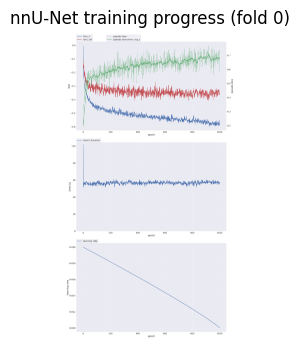

In [129]:
# Section 3.8.6 — Tail nnU-Net trainer log (authoritative) + show progress.png

import os
import time
from pathlib import Path


def _tail(path: Path, n: int = 120) -> str:
    try:
        with open(path, "r", errors="replace") as f:
            lines = f.readlines()
        return "".join(lines[-n:])
    except FileNotFoundError:
        return f"(missing: {path})"


results_root = Path(os.environ["nnUNet_results"])
dataset_dir = results_root / f"Dataset{int(DATASET_ID):03d}_{DATASET_NAME}"
trainer_dir = dataset_dir / "nnUNetTrainer__nnUNetPlans__3d_fullres"
fold_dir = trainer_dir / "fold_0"

print("results_root:", results_root)
print("fold_dir:", fold_dir)

log_files = sorted(fold_dir.glob("training_log_*.txt"))
if not log_files:
    print("No training_log_*.txt found yet.")
else:
    log_file = log_files[-1]
    st = log_file.stat()
    print("log:", log_file)
    print(f"size={st.st_size} bytes  mtime={time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(st.st_mtime))}")
    print("\n--- tail ---")
    print(_tail(log_file, n=160))

# Optional: show progress plot if available
png = fold_dir / "progress.png"
if png.exists():
    try:
        from PIL import Image
        import matplotlib.pyplot as plt
        img = Image.open(png)
        plt.figure(figsize=(10, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title("nnU-Net training progress (fold 0)")
        plt.show()
    except Exception as e:
        print("[WARN] Could not display progress.png:", e)

In [14]:
# Section 3.8.8 — Resume after kernel reconnect (detect completed folds + run remaining folds 1–4 sequentially)

import os
import time
import subprocess
from pathlib import Path

# Hard-set nnU-Net paths (safe even if already set)
os.environ["nnUNet_raw"] = "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw"
os.environ["nnUNet_preprocessed"] = "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results"

results_root = Path(os.environ["nnUNet_results"])
run_root = results_root / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

# Find dataset dir automatically (prefer Dataset501_*)
ds_dirs = sorted([p for p in results_root.glob("Dataset501_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset501_* under {results_root}")
dataset_dir = ds_dirs[0]
dataset_id = 501
dataset_name = dataset_dir.name.removeprefix("Dataset501_")

trainer_dir = dataset_dir / "nnUNetTrainer__nnUNetPlans__3d_fullres"
if not trainer_dir.exists():
    raise FileNotFoundError(f"Trainer dir not found: {trainer_dir}")

def fold_status(fold: int) -> dict:
    fdir = trainer_dir / f"fold_{fold}"
    return {
        "fold": fold,
        "dir": fdir,
        "exists": fdir.exists(),
        "checkpoint_final": (fdir / "checkpoint_final.pth").exists(),
        "checkpoint_best": (fdir / "checkpoint_best.pth").exists(),
        "progress_png": (fdir / "progress.png").exists(),
    }

folds = [fold_status(i) for i in range(5)]
print("Dataset:", dataset_dir.name)
print("Trainer:", trainer_dir)
print("\nFold status:")
for s in folds:
    print(
        f"fold_{s['fold']}: ",
"final" if s["checkpoint_final"] else "-",
"best" if s["checkpoint_best"] else "-",
"progress" if s["progress_png"] else "-"
    )
print()

# Check if any nnUNetv2_train is currently running (ignore zombies/defunct)
p = subprocess.run("ps -eo pid=,stat=,cmd=", shell=True, capture_output=True, text=True)
procs = []
for ln in (p.stdout or "").splitlines():
    ln = ln.strip()
    if not ln:
        continue
    parts = ln.split(None, 2)
    if len(parts) < 3:
        continue
    pid_s, stat, cmd = parts[0], parts[1], parts[2]
    if "nnUNetv2_train" not in cmd:
        continue
    procs.append((pid_s, stat, cmd))

active = [(pid_s, stat, cmd) for (pid_s, stat, cmd) in procs if "Z" not in stat and "<defunct>" not in cmd]
print("nnUNetv2_train processes found:")
if not procs:
    print("(none)")
else:
    for pid_s, stat, cmd in procs:
        tag = "ACTIVE" if (pid_s, stat, cmd) in active else "zombie/defunct"
        print(f"{tag}: pid={pid_s} stat={stat} cmd={cmd}")
print()

# If something active is already running, we do not start another to avoid GPU contention
if active:
    print("[INFO] Training already running; not starting any new folds.")
else:
    # Create a scheduler script that runs remaining folds sequentially, skipping completed ones
    ts = time.strftime("%Y%m%d_%H%M%S")
    script_path = run_root / f"nnunetv2_run_remaining_folds_501_3d_fullres_{ts}.sh"
    sched_log = run_root / f"nnunetv2_run_remaining_folds_501_3d_fullres_{ts}.log"

    # NOTE: this is an f-string; escape bash ${fold} as ${{fold}}
    script = f"""#!/usr/bin/env bash
set -euo pipefail

export nnUNet_raw=\"{os.environ['nnUNet_raw']}\"
export nnUNet_preprocessed=\"{os.environ['nnUNet_preprocessed']}\"
export nnUNet_results=\"{os.environ['nnUNet_results']}\"
export PYTHONUNBUFFERED=1

echo \"[resume] dataset={dataset_id}  config=3d_fullres  start=$(date)\"

for fold in 1 2 3 4; do
  fdir=\"$nnUNet_results/{dataset_dir.name}/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_${{fold}}\"
  if [[ -f \"$fdir/checkpoint_final.pth\" ]]; then
    echo \"[resume] fold=${{fold}}: already has checkpoint_final.pth, skipping\"
    continue
  fi
  echo \"[resume] starting fold=${{fold}} at $(date)\"
  nnUNetv2_train {dataset_id} 3d_fullres ${{fold}}
  echo \"[resume] finished fold=${{fold}} at $(date)\"
done

echo \"[resume] done $(date)\"
"""

    script_path.write_text(script)
    script_path.chmod(0o755)
    print("Wrote resume scheduler:", script_path)
    print("Log:", sched_log)
    cmd = f"nohup bash {script_path} > {sched_log} 2>&1 & echo $!"
    out = subprocess.check_output(cmd, shell=True, text=True).strip()
    print("Started PID:", out)
    print("\nNext: open/tail the log file in notebook_runs to see fold 1 start.")

Dataset: Dataset501_BraTS_PEDs2024
Trainer: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres

Fold status:
fold_0:  final best progress
fold_1:  - best progress
fold_2:  - - -
fold_3:  - - -
fold_4:  - - -

nnUNetv2_train processes found:
(none)

Wrote resume scheduler: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_run_remaining_folds_501_3d_fullres_20260111_163540.sh
Log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_run_remaining_folds_501_3d_fullres_20260111_163540.log
Started PID: 5602

Next: open/tail the log file in notebook_runs to see fold 1 start.


In [16]:
# Section 3.8.9 — Detailed progress across folds (0–4)

import os
import re
import time
import subprocess
from pathlib import Path

# Ensure nnU-Net env vars exist (safe to re-set)
os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")
results_root = Path(os.environ["nnUNet_results"])

def _fmt_ts(ts: float) -> str:
    return time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(ts))

def _safe_stat(path: Path):
    try:
        return path.stat()
    except FileNotFoundError:
        return None

def _tail(path: Path, n: int = 80) -> str:
    try:
        with open(path, "r", errors="replace") as f:
            lines = f.readlines()
        return "".join(lines[-n:])
    except FileNotFoundError:
        return ""

def _parse_last_epoch_and_best(txt: str):
    # Best-effort parse of nnU-Net log text
    last_epoch = None
    last_lr = None
    last_train_loss = None
    last_val_loss = None
    last_pseudo = None
    best_ema = None

    # scan line-by-line so we can catch the last occurrence
    for line in txt.splitlines():
        m = re.search(r"Epoch\s+(\d+)", line)
        if m:
            last_epoch = int(m.group(1))
        m = re.search(r"Current learning rate:\s*([0-9.eE+-]+)", line)
        if m:
            last_lr = float(m.group(1))
        m = re.search(r"train_loss\s*([0-9.eE+-]+)", line)
        if m:
            last_train_loss = float(m.group(1))
        m = re.search(r"val_loss\s*([0-9.eE+-]+)", line)
        if m:
            last_val_loss = float(m.group(1))
        m = re.search(r"Pseudo dice\s*\[([^\]]+)\]", line)
        if m:
            last_pseudo = m.group(1).strip()
        m = re.search(r"New best EMA pseudo Dice:\s*([0-9.eE+-]+)", line)
        if m:
            best_ema = float(m.group(1))
    return {
        "last_epoch": last_epoch,
        "last_lr": last_lr,
        "last_train_loss": last_train_loss,
        "last_val_loss": last_val_loss,
        "last_pseudo": last_pseudo,
        "best_ema": best_ema,
    }

def _find_dataset_dir() -> Path:
    ds_dirs = sorted([p for p in results_root.glob("Dataset501_*") if p.is_dir()])
    if not ds_dirs:
        raise FileNotFoundError(f"No Dataset501_* found under {results_root}")
    return ds_dirs[0]

dataset_dir = _find_dataset_dir()
trainer_dir = dataset_dir / "nnUNetTrainer__nnUNetPlans__3d_fullres"
print("results_root:", results_root)
print("dataset_dir:", dataset_dir)
print("trainer_dir:", trainer_dir)
print()

# Show any currently active nnU-Net training processes (server-side)
ps = subprocess.run("ps -eo pid=,stat=,cmd=", shell=True, capture_output=True, text=True)
active = []
for ln in (ps.stdout or "").splitlines():
    parts = ln.strip().split(None, 2)
    if len(parts) < 3:
        continue
    pid_s, stat, cmd = parts[0], parts[1], parts[2]
    if "nnUNetv2_train" in cmd and "Z" not in stat and "<defunct>" not in cmd:
        active.append((pid_s, stat, cmd))
print("Active nnUNetv2_train:")
if not active:
    print("(none)")
else:
    for pid_s, stat, cmd in active:
        print(f"pid={pid_s} stat={stat} cmd={cmd}")
print()

# Per-fold detailed status
for fold in range(5):
    fold_dir = trainer_dir / f"fold_{fold}"
    ck_final = fold_dir / "checkpoint_final.pth"
    ck_best = fold_dir / "checkpoint_best.pth"
    ck_latest = fold_dir / "checkpoint_latest.pth"
    prog = fold_dir / "progress.png"
    logs = sorted(fold_dir.glob("training_log_*.txt"))
    log = logs[-1] if logs else None

    print("=" * 80)
    print(f"fold_{fold}: {fold_dir}")

    if not fold_dir.exists():
        print("status: not started (fold directory missing)")
        continue

    # Checkpoint summary
    def _ck_line(label: str, p: Path):
        st = _safe_stat(p)
        if not st:
            return f"{label}: -"
        return f"{label}: present (mtime={_fmt_ts(st.st_mtime)}, size={st.st_size/1024/1024:.1f} MiB)"

    print(_ck_line("checkpoint_final", ck_final))
    print(_ck_line("checkpoint_best ", ck_best))
    print(_ck_line("checkpoint_latest", ck_latest))

    # Progress plot timestamp
    stp = _safe_stat(prog)
    if stp:
        print(f"progress.png: present (mtime={_fmt_ts(stp.st_mtime)}, size={stp.st_size/1024:.0f} KiB)")
    else:
        print("progress.png: -")

    # Log parsing
    if log is None:
        print("trainer log: -")
        # infer status from checkpoints
        if ck_final.exists():
            print("status: completed")
        elif ck_best.exists() or ck_latest.exists():
            print("status: started (no log found?)")
        else:
            print("status: created but no artifacts yet")
        continue

    stl = log.stat()
    print(f"trainer log: {log.name} (mtime={_fmt_ts(stl.st_mtime)}, size={stl.st_size/1024:.0f} KiB)")
    tail_txt = _tail(log, n=200)
    parsed = _parse_last_epoch_and_best(tail_txt)
    print("parsed (from log tail):", parsed)

    if ck_final.exists():
        print("status: completed")
    elif parsed.get("last_epoch") is not None:
        print("status: running or recently running")
    else:
        print("status: started (no epoch lines yet)")

print("=" * 80)
print("Done.")

results_root: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results
dataset_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024
trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres

Active nnUNetv2_train:
(none)

fold_0: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0
checkpoint_final: present (mtime=2026-01-08 18:19:54, size=235.5 MiB)
checkpoint_best : present (mtime=2026-01-08 17:00:13, size=235.5 MiB)
checkpoint_latest: -
progress.png: present (mtime=2026-01-08 18:19:54, size=1207 KiB)
trainer log: training_log_2026_1_8_02_17_59.txt (mtime=2026-01-08 18:21:55, size=349 KiB)
parsed (from log tail): {'last_epoch': 999, 'last_lr': 2e-05, 'last_train_loss': -0.5841, 'last_val_loss': -0.3637, 'last_pseudo': '0.6129, 0.8166, 0.689', 'best_ema': None}
status: completed
fold_1: /workspace/pediat

In [19]:
# Section 3.8.11 — Fresh-kernel diagnosis (nnU‑Net + GPU + paths)
import os
import sys
import shutil
import subprocess
from pathlib import Path

def _run(cmd, timeout=20):
    p = subprocess.run(cmd, shell=isinstance(cmd, str), capture_output=True, text=True, timeout=timeout)
    return p.returncode, (p.stdout or "").strip(), (p.stderr or "").strip()

print("=== Kernel / Python ===")
print("sys.executable:", sys.executable)
print("python:", sys.version.split()[0])
rc, out, err = _run([sys.executable, "-m", "pip", "--version"], timeout=30)
print("pip:", out or err or f"rc={rc}")

print("\n=== GPU (best-effort) ===")
rc, out, err = _run("nvidia-smi --query-gpu=name,driver_version,memory.total,memory.used --format=csv,noheader", timeout=10)
if rc == 0 and out:
    print(out)
else:
    print("nvidia-smi not available (or timed out / permissions restricted).")

print("\n=== nnU‑Net v2 availability ===")
train_cli = shutil.which("nnUNetv2_train")
print("nnUNetv2_train on PATH:", bool(train_cli), f"({train_cli})" if train_cli else "")
try:
    import importlib.util
    has_mod = importlib.util.find_spec("nnunetv2") is not None
except Exception:
    has_mod = False
print("nnunetv2 importable:", bool(has_mod))

print("\nTrying to list kernels (best-effort):")
rc, out, err = _run("jupyter kernelspec list", timeout=15)
print(out or err or f"rc={rc}")

AUTO_INSTALL_NNUNETV2 = True  # set False if you ONLY want to switch kernels/env manually
if not train_cli and not has_mod:
    print("\n[IMPORTANT] This fresh kernel does not have nnU‑Net v2 available yet.")
    if AUTO_INSTALL_NNUNETV2:
        print("\nAttempting to install nnunetv2 into THIS kernel via pip...")
        # Upgrade basics first (helps with some environments)
        rc, out, err = _run([sys.executable, "-m", "pip", "install", "-U", "pip", "setuptools", "wheel"], timeout=900)
        print(out)
        if err:
            print("\n[pip stderr]\n", err)
        print("upgrade rc:", rc)

        rc, out, err = _run([sys.executable, "-m", "pip", "install", "-U", "nnunetv2"], timeout=1800)
        print(out)
        if err:
            print("\n[pip stderr]\n", err)
        print("nnunetv2 install rc:", rc)

        # Re-check availability after install
        train_cli = shutil.which("nnUNetv2_train")
        try:
            import importlib.util
            has_mod = importlib.util.find_spec("nnunetv2") is not None
        except Exception:
            has_mod = False
        print("\nAfter install:")
        print("nnUNetv2_train on PATH:", bool(train_cli), f"({train_cli})" if train_cli else "")
        print("nnunetv2 importable:", bool(has_mod))
    else:
        print("\nAction required: switch the notebook kernel to the env used for fold 0, then rerun this cell.")

# Always verify persisted /workspace paths, even if nnU‑Net is missing in kernel
print("\n=== nnU‑Net paths (persisted on /workspace) ===")
os.environ.setdefault("nnUNet_raw", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw")
os.environ.setdefault("nnUNet_preprocessed", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed")
os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")
for k in ["nnUNet_raw", "nnUNet_preprocessed", "nnUNet_results"]:
    print(f"{k}:", os.environ.get(k))

results_root = Path(os.environ["nnUNet_results"])
ds_dirs = sorted([p for p in results_root.glob("Dataset501_*") if p.is_dir()])
print("Dataset501_* found:", [p.name for p in ds_dirs])
if ds_dirs:
    dataset_dir = ds_dirs[0]
    trainer_dir = dataset_dir / "nnUNetTrainer__nnUNetPlans__3d_fullres"
    print("dataset_dir:", dataset_dir)
    print("trainer_dir:", trainer_dir)
    f0_final = trainer_dir / "fold_0" / "checkpoint_final.pth"
    print("fold_0 checkpoint_final exists:", f0_final.exists())
else:
    print("[WARN] Could not find Dataset501_* under nnUNet_results.")

if not (train_cli or has_mod):
    raise RuntimeError("nnU‑Net v2 still not available in this kernel after install attempt. Switch kernel/env or fix pip access, then rerun.")

=== Kernel / Python ===
sys.executable: /usr/bin/python
python: 3.12.3
pip: pip 24.3.1 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)

=== GPU (best-effort) ===
NVIDIA H100 80GB HBM3, 535.161.08, [Insufficient Permissions], [Insufficient Permissions]

=== nnU‑Net v2 availability ===
nnUNetv2_train on PATH: False 
nnunetv2 importable: False

Trying to list kernels (best-effort):
Available kernels:
  python3    /usr/local/share/jupyter/kernels/python3

[IMPORTANT] This fresh kernel does not have nnU‑Net v2 available yet.

Attempting to install nnunetv2 into THIS kernel via pip...
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.8 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━ 1.0/1.8 MB 7.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.2 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [21]:
# Section 3.8.12 — Start/resume folds 1–4 sequentially (disconnect-safe)
import os
import sys
import time
import shutil
import subprocess
from pathlib import Path

# Re-establish nnU‑Net env vars
os.environ.setdefault("nnUNet_raw", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw")
os.environ.setdefault("nnUNet_preprocessed", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed")
os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")

results_root = Path(os.environ["nnUNet_results"])
run_root = results_root / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

# Locate dataset/trainer folders
ds_dirs = sorted([p for p in results_root.glob("Dataset501_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset501_* found under {results_root}")
dataset_dir = ds_dirs[0]
trainer_dir = dataset_dir / "nnUNetTrainer__nnUNetPlans__3d_fullres"

dataset_id = 501
config_name = "3d_fullres"
folds = [1, 2, 3, 4]

# Decide how to call training in THIS kernel env
train_cli = shutil.which("nnUNetv2_train")
if train_cli:
    train_kind = "cli"
    help_cmd = ["nnUNetv2_train", "-h"]
else:
    import importlib.util
    if importlib.util.find_spec("nnunetv2") is None:
        raise RuntimeError("nnU‑Net v2 not available in this kernel. Run Cell 35 and switch kernel/env as needed.")
    train_kind = "module"
    help_cmd = [sys.executable, "-m", "nnunetv2.run.run_training", "-h"]

help_p = subprocess.run(help_cmd, capture_output=True, text=True)
help_txt = (help_p.stdout or "") + "\n" + (help_p.stderr or "")
resume_flag = None
for c in ["--continue_training", "--continue", "--resume", "-c"]:
    if c in help_txt:
        resume_flag = c
        break
print("train_kind:", train_kind)
print("resume_flag detected:", resume_flag)

# Avoid overlap with any already-running nnU-Net training
ps = subprocess.run("ps -eo pid=,stat=,cmd=", shell=True, capture_output=True, text=True)
active = []
for ln in (ps.stdout or "").splitlines():
    parts = ln.strip().split(None, 2)
    if len(parts) < 3:
        continue
    pid_s, stat, cmd = parts[0], parts[1], parts[2]
    if "nnUNetv2_train" in cmd and "Z" not in stat and "<defunct>" not in cmd:
        active.append((pid_s, stat, cmd))
if active:
    print("Active nnUNetv2_train detected; not starting scheduler.")
    for pid_s, stat, cmd in active:
        print(f"pid={pid_s} stat={stat} cmd={cmd}")
    raise SystemExit

# Build a scheduler bash script that runs folds sequentially in foreground
ts = time.strftime("%Y%m%d_%H%M%S")
script_path = run_root / f"schedule_d{dataset_id}_{config_name}_folds_1_4_{ts}.sh"
sched_log = run_root / f"schedule_d{dataset_id}_{config_name}_folds_1_4_{ts}.log"

py_exe = sys.executable.replace('"', '')
trainer_dir_s = str(trainer_dir)
resume_flag_s = resume_flag or ""
folds_s = " ".join(str(f) for f in folds)

# NOTE: this is a Python f-string; any bash ${...} needs escaping as ${{...}}
script = f"""#!/usr/bin/env bash
set -euo pipefail

export nnUNet_raw=\"{os.environ['nnUNet_raw']}\"
export nnUNet_preprocessed=\"{os.environ['nnUNet_preprocessed']}\"
export nnUNet_results=\"{os.environ['nnUNet_results']}\"

DATASET_ID=\"{dataset_id}\"
CONFIG=\"{config_name}\"
TRAINER_DIR=\"{trainer_dir_s}\"
PY_EXE=\"{py_exe}\"
RESUME_FLAG=\"{resume_flag_s}\"

if command -v nnUNetv2_train >/dev/null 2>&1; then
  TRAIN_CMD=(nnUNetv2_train)
else
  # Use the same python as this kernel so it hits the same site-packages
  TRAIN_CMD=(\"$PY_EXE\" -m nnunetv2.run.run_training)
fi

echo \"[scheduler] Using TRAIN_CMD: ${{TRAIN_CMD[*]}}\"
echo \"[scheduler] Trainer dir: $TRAINER_DIR\"
echo \"[scheduler] Folds: {folds_s}\"

for f in {folds_s}; do
  FOLD_DIR=\"$TRAINER_DIR/fold_${{f}}\"
  CK_FINAL=\"$FOLD_DIR/checkpoint_final.pth\"
  CK_LATEST=\"$FOLD_DIR/checkpoint_latest.pth\"
  CK_BEST=\"$FOLD_DIR/checkpoint_best.pth\"

  if [[ -f \"$CK_FINAL\" ]]; then
    echo \"[scheduler] fold $f: already complete (checkpoint_final.pth)\"
    continue
  fi

  EXTRA=()
  if [[ -n \"$RESUME_FLAG\" ]] && ([[ -f \"$CK_LATEST\" ]] || [[ -f \"$CK_BEST\" ]]); then
    EXTRA=(\"$RESUME_FLAG\")
    echo \"[scheduler] fold $f: resume requested ($RESUME_FLAG)\"
  else
    echo \"[scheduler] fold $f: starting fresh (no resume flag or no checkpoints)\"
  fi

  echo \"[scheduler] launching fold $f...\"
  (PYTHONUNBUFFERED=1 ${{TRAIN_CMD[@]}} \"$DATASET_ID\" \"$CONFIG\" \"$f\" ${{EXTRA[@]}})

  if [[ -f \"$CK_FINAL\" ]]; then
    echo \"[scheduler] fold $f: finished OK (checkpoint_final.pth exists)\"
  else
    echo \"[scheduler] fold $f: training exited but checkpoint_final.pth missing -> stop\"
    exit 2
  fi
done

echo \"[scheduler] all requested folds done\"
"""
script_path.write_text(script)
subprocess.run(["chmod", "+x", str(script_path)], check=False)
print("Wrote scheduler:", script_path)
print("Scheduler log:", sched_log)

# Launch scheduler in background so it survives disconnects
cmd = f"nohup bash {script_path} > {sched_log} 2>&1 & echo $!"
pid = subprocess.check_output(cmd, shell=True, text=True).strip()
print("Scheduler PID:", pid)
print("Tip: run the fold-progress and epoch dashboard cells anytime to monitor.")

train_kind: cli
resume_flag detected: -c
Wrote scheduler: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/schedule_d501_3d_fullres_folds_1_4_20260111_172941.sh
Scheduler log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/schedule_d501_3d_fullres_folds_1_4_20260111_172941.log
Scheduler PID: 6563
Tip: run the fold-progress and epoch dashboard cells anytime to monitor.


In [170]:
# Section 3.8.13 — Epoch progress dashboard (folds 0–4)
import os
import re
from pathlib import Path
from datetime import datetime

os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")
results_root = Path(os.environ["nnUNet_results"])
ds_dirs = sorted([p for p in results_root.glob("Dataset501_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset501_* found under {results_root}")
dataset_dir = ds_dirs[0]
trainer_dir = dataset_dir / "nnUNetTrainer__nnUNetPlans__3d_fullres"

def _find_latest_log(fold_dir: Path) -> Path | None:
    if not fold_dir.exists():
        return None
    logs = sorted(fold_dir.glob("training_log_*.txt"), key=lambda p: p.stat().st_mtime, reverse=False)
    if logs:
        return logs[-1]
    # fallback names (older variants)
    for nm in ["training_log.txt", "log.txt"]:
        p = fold_dir / nm
        if p.exists():
            return p
    return None

def _parse_last_epoch(log_path: Path) -> int | None:
    try:
        txt = log_path.read_text(errors="ignore")
    except Exception:
        return None
    # prefer tail to speed up
    tail = "\n".join(txt.splitlines()[-300:])
    # nnU-Net often writes 'epoch: N' in JSON-ish logs
    m = None
    for pat in [r"\bepoch\s*:\s*(\d+)\b", r"\bEpoch\s+(\d+)\b", r"\bepoch\s+(\d+)\b"]:
        ms = list(re.finditer(pat, tail, flags=re.IGNORECASE))
        if ms:
            m = ms[-1]
            break
    return int(m.group(1)) if m else None

def _infer_target_epochs() -> int | None:
    # best-effort: if fold 0 is complete, use its last epoch + 1 as target
    f0 = trainer_dir / "fold_0"
    if (f0 / "checkpoint_final.pth").exists():
        lp = _find_latest_log(f0)
        if lp:
            last = _parse_last_epoch(lp)
            if last is not None and last >= 1:
                return last + 1
    return None

target_epochs = _infer_target_epochs() or 1000
print("dataset_dir:", dataset_dir)
print("trainer_dir:", trainer_dir)
print("target_epochs (inferred/assumed):", target_epochs)

rows = []
for f in range(0, 5):
    fold_dir = trainer_dir / f"fold_{f}"
    ck_final = fold_dir / "checkpoint_final.pth"
    ck_latest = fold_dir / "checkpoint_latest.pth"
    lp = _find_latest_log(fold_dir)
    last_epoch = _parse_last_epoch(lp) if lp else None
    if ck_final.exists():
        status = "completed"
    elif ck_latest.exists():
        status = "in-progress"
    elif fold_dir.exists():
        status = "started?"
    else:
        status = "not-started"
    # pick last update time
    cand = [p for p in [ck_latest if ck_latest.exists() else None, lp if lp and lp.exists() else None] if p]
    last_update = datetime.fromtimestamp(max(p.stat().st_mtime for p in cand)).isoformat(timespec="seconds") if cand else "-"
    pct = f"{((last_epoch + 1) / target_epochs * 100):.1f}%" if last_epoch is not None else "-"
    rows.append((f, status, last_epoch, target_epochs, pct, last_update, str(lp) if lp else "-"))

# Print a compact table
hdr = ["fold", "status", "last_epoch", "target", "%", "last_update", "log"]
print("\t".join(hdr))
for r in rows:
    print("\t".join(str(x) for x in r))

dataset_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024
trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres
target_epochs (inferred/assumed): 1000
fold	status	last_epoch	target	%	last_update	log
0	completed	999	1000	100.0%	2026-01-08T18:21:55	/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/training_log_2026_1_8_02_17_59.txt
1	completed	999	1000	100.0%	2026-01-13T21:40:20	/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_1/training_log_2026_1_12_17_32_55.txt
2	completed	999	1000	100.0%	2026-01-22T05:43:40	/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_2/training_log_2026_1_20_06_24_05.txt
3	in-progress	54	1000	5.5%	2026-01-22T10:09:46	/w

In [ ]:
# Section 3.8.16 — (Deprecated) Resume-only fold 2 launcher
print("This cell is deprecated.")
print("Use the next cell: 'Section 3.8.17 — START OVER fold 2 + run folds 2→3→4 sequentially (background)'.")

dataset_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024
trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres
fold_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_2
/workspace free: 74.7 GB
Resuming from existing checkpoint (-c).
Started fold 2 with PID=189742
Launch log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_train_d501_3d_fullres_fold2_manual_restart_20260119_153731.log

--- launch log tail (last 80 lines) ---
(log is empty so far; re-run this cell in ~1–2 min)


In [124]:
# Section 3.8.17 — START OVER fold 2 + run folds 2→3→4 sequentially (background)
import os
import shutil
import subprocess
import time
from datetime import datetime, timezone
from pathlib import Path

# --- settings ---
DATASET_ID = 501
CONFIG = "3d_fullres"
FOLDS = [2, 3, 4]

# Start over means: stop any running jobs, move fold dir to backup, and retrain from scratch.
START_OVER_FOLDS = {2}  # change to {2,3,4} if you want to wipe all three folds

# Safety: refuse to start if disk is too tight (nnU-Net writes lots of stuff).
MIN_FREE_GB_FOR_START = 20

# Stability toggles (recommended)
DISABLE_TORCH_COMPILE = True  # sets nnUNet_compile=0
DA_WORKERS = None  # optionally set an int to reduce DA workers (env nnUNet_n_proc_DA)

# IMPORTANT: set True to actually execute the destructive start-over + launch.
CONFIRM_START_OVER_AND_RUN = True

if os.name != "posix":
    raise RuntimeError("This cell expects a Linux (posix) kernel because it uses nohup/ps/pkill/bash.")

# Locate nnUNet_results + dataset folder
os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")
results_root = Path(os.environ["nnUNet_results"])
ds_dirs = sorted([p for p in results_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset{DATASET_ID:03d}_* found under {results_root}")
dataset_dir = ds_dirs[0]
trainer_dir = dataset_dir / "nnUNetTrainer__nnUNetPlans__3d_fullres"

print("dataset_dir:", dataset_dir)
print("trainer_dir:", trainer_dir)
print("FOLDS:", FOLDS)
print("START_OVER_FOLDS:", sorted(START_OVER_FOLDS))

# Disk check
ws = Path("/workspace")
du = shutil.disk_usage(str(ws))
free_gb = du.free / (1024**3)
print(f"/workspace free: {free_gb:.1f} GB")
if free_gb < MIN_FREE_GB_FOR_START:
    raise RuntimeError(
        f"Not starting: only ~{free_gb:.1f} GB free on /workspace; "
        f"need >= {MIN_FREE_GB_FOR_START} GB. Run the disk cleanup cell first."
    )

if not CONFIRM_START_OVER_AND_RUN:
    raise RuntimeError("Set CONFIRM_START_OVER_AND_RUN = True to proceed.")

# 1) Stop any running nnU-Net training processes for these folds
def _find_fold_pids(dataset_id: int, config: str, folds: list[int]) -> list[int]:
    ps = subprocess.run("ps -eo pid=,cmd=", shell=True, text=True, capture_output=True)
    lines = (ps.stdout or "").splitlines()
    wanted = []
    for ln in lines:
        ln = ln.strip()
        if not ln:
            continue
        try:
            pid_s, cmd = ln.split(None, 1)
            pid = int(pid_s)
        except Exception:
            continue
        if "nnUNetv2_train" not in cmd:
            continue
        if f"{dataset_id} {config}" not in cmd:
            continue
        if any(f" {f} " in f" {cmd} " for f in folds):
            wanted.append(pid)
    return sorted(set(wanted))

pids = _find_fold_pids(DATASET_ID, CONFIG, FOLDS)
if pids:
    print("Stopping running nnU-Net processes:", pids)
    # try graceful TERM then hard KILL
    subprocess.run("kill -TERM " + " ".join(map(str, pids)), shell=True, check=False)
    time.sleep(5)
    still = _find_fold_pids(DATASET_ID, CONFIG, FOLDS)
    if still:
        print("Still running after TERM; sending KILL:", still)
        subprocess.run("kill -KILL " + " ".join(map(str, still)), shell=True, check=False)
else:
    print("No running nnU-Net processes detected for folds 2–4.")

# 2) Start-over: move fold dirs to timestamped backup (only for START_OVER_FOLDS)
ts = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
backup_root = dataset_dir / "hard_restart_backups" / f"startover_folds_{'_'.join(map(str, sorted(START_OVER_FOLDS)))}_{ts}"
backup_root.mkdir(parents=True, exist_ok=True)

for f in sorted(START_OVER_FOLDS):
    fold_dir = trainer_dir / f"fold_{f}"
    if fold_dir.exists():
        dest = backup_root / fold_dir.name
        print(f"Backing up {fold_dir} -> {dest}")
        if dest.exists():
            raise RuntimeError(f"Backup destination already exists: {dest}")
        shutil.move(str(fold_dir), str(dest))
    # recreate directory so nnU-Net can write into it
    fold_dir.mkdir(parents=True, exist_ok=True)

# 3) Create a sequential runner script (fold 2 -> 3 -> 4) and launch via nohup
run_root = results_root / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

script_path = run_root / f"seq_train_d{DATASET_ID}_{CONFIG}_folds2to4_{ts}.sh"
sched_log = run_root / f"seq_train_d{DATASET_ID}_{CONFIG}_folds2to4_{ts}.log"

env_bits = ["PYTHONUNBUFFERED=1"]
if DISABLE_TORCH_COMPILE:
    env_bits.append("nnUNet_compile=0")
if DA_WORKERS is not None:
    env_bits.append(f"nnUNet_n_proc_DA={int(DA_WORKERS)}")
env_exports = "\n".join([f"export {e}" for e in env_bits])

script = f"""#!/usr/bin/env bash
set -euo pipefail

echo "[seq] started: $(date -Is)"
echo "[seq] dataset_id={DATASET_ID} config={CONFIG} folds={' '.join(map(str, FOLDS))}"
echo "[seq] nnUNet_results=$nnUNet_results"
echo "[seq] trainer_dir={trainer_dir}"
echo "[seq] logs live in: {run_root}"
echo
{env_exports}

maybe_resume_flag() {{
  local fold="$1"
  local fold_dir="{trainer_dir}/fold_${{fold}}"
  if [[ -f "${{fold_dir}}/checkpoint_latest.pth" || -f "${{fold_dir}}/checkpoint_best.pth" ]]; then
    echo "-c"
  else
    echo ""
  fi
}}

run_fold() {{
  local fold="$1"
  local resume_flag
  resume_flag="$(maybe_resume_flag "$fold")"
  local out_log="{run_root}/nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold${{fold}}_{ts}.log"
  echo "[seq] fold $fold starting: $(date -Is)" | tee -a "$out_log"
  echo "[seq] cmd: nnUNetv2_train {DATASET_ID} {CONFIG} $fold $resume_flag" | tee -a "$out_log"
  # note: resume_flag will be empty on fold 2 (fresh) because we just wiped it
  env {' '.join(env_bits)} nnUNetv2_train {DATASET_ID} {CONFIG} "$fold" $resume_flag >> "$out_log" 2>&1
  echo "[seq] fold $fold finished: $(date -Is)" | tee -a "$out_log"
}}

run_fold 2
run_fold 3
run_fold 4

echo "[seq] all done: $(date -Is)"
"""

script_path.write_text(script)
subprocess.run(f"chmod +x {script_path}", shell=True, check=False)

cmd = f"nohup bash {script_path} > {sched_log} 2>&1 & echo $!"
pid = subprocess.check_output(cmd, shell=True, text=True).strip()

# Expose paths for the next monitoring cell
SEQ_RUN_SCRIPT_PATH = str(script_path)
SEQ_RUN_SCHED_LOG = str(sched_log)
SEQ_RUN_PID = pid

print(f"Launched sequential runner PID={pid}")
print("Runner script:", script_path)
print("Runner log:", sched_log)
print("Per-fold logs:", run_root / f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold{{2,3,4}}_{ts}.log")

# Show immediate tail of scheduler log
try:
    tail = Path(SEQ_RUN_SCHED_LOG).read_text(errors="ignore").splitlines()[-80:]
    print("\n--- scheduler log tail (last 80 lines) ---")
    print("\n".join(tail) if tail else "(log is empty so far; re-run the next cell in ~1–2 min)")
except Exception as exc:
    print("Could not read scheduler log yet:", exc)

dataset_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024
trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres
FOLDS: [2, 3, 4]
START_OVER_FOLDS: [2]
/workspace free: 74.7 GB
No running nnU-Net processes detected for folds 2–4.
Backing up /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_2 -> /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/hard_restart_backups/startover_folds_2_20260119_154051/fold_2
Launched sequential runner PID=189994
Runner script: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/seq_train_d501_3d_fullres_folds2to4_20260119_154051.sh
Runner log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/seq_train_d501_3d_fullres_folds2to4_20260119_154051.log
Per-fold logs: /workspace/pediatric_tumor_data/nnune

In [158]:
# Section 3.8.X — TURBO: Optimize + (optionally) restart folds 3→4 ONLY (does not touch folds 0/1/2)
#
# What this does:
# - Detects and (optionally) stops any running nnU-Net training for fold 3 and/or 4
# - Relaunches fold 3 then fold 4 sequentially with high-throughput env settings
# - Uses resume flag if checkpoints exist
#
# Important: You cannot "speed up" an already-running nnU-Net process without restarting it.
# This cell is designed to restart fold 3 if it's currently running with slow debug settings.

import os
import re
import time
import subprocess
import multiprocessing
from pathlib import Path

# ---------------- user knobs ----------------
DATASET_ID = 501
CONFIG = "3d_fullres"
FOLDS = [3, 4]

# If fold 3 is currently running, set True to stop+relaunch with optimized env (recommended for your case).
RESTART_IF_RUNNING = True

# Safety gate (destructive: sends TERM/KILL to fold 3/4 processes only)
CONFIRM_TURBO_RESTART = True

# Data-augmentation workers (main throughput knob). If None, auto-pick based on CPU cores.
DA_WORKERS = None

# If you had this set to 0 for stability/debugging, that can reduce speed. We'll force it on.
FORCE_NNUNET_COMPILE = True

# Prevent CPU thread oversubscription (often helps dataloading/augmentation throughput).
PIN_CPU_THREADS = True

# ------------------------------------------------
if os.name != "posix":
    raise RuntimeError("This cell expects a Linux/posix kernel (uses ps/kill/nohup/bash).")

# Ensure nnU-Net env paths exist (safe to re-set)
os.environ.setdefault("nnUNet_raw", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw")
os.environ.setdefault("nnUNet_preprocessed", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed")
os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")

cpu_cores = multiprocessing.cpu_count()
auto_da = max(8, cpu_cores // 2)
auto_da = min(16, auto_da)  # usually sweet spot; raise manually if you have tons of CPU/RAM
da = int(DA_WORKERS) if DA_WORKERS is not None else int(auto_da)

# Detect resume flag spelling supported by this nnU-Net build
def _help_text(cmd: list[str]) -> str:
    p = subprocess.run(cmd, capture_output=True, text=True)
    return (p.stdout or "") + "\n" + (p.stderr or "")

help_txt = _help_text(["nnUNetv2_train", "-h"])
if re.search(r"\n\s*--c(\s|,|$)", help_txt):
    RESUME_FLAG = "--c"
elif re.search(r"\n\s*-c(\s|,|$)", help_txt):
    RESUME_FLAG = "-c"
elif "--continue" in help_txt:
    RESUME_FLAG = "--continue"
else:
    RESUME_FLAG = ""  # fallback: will still run, but won't auto-resume if interrupted

# Build optimized env for NEW training processes
env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"
env["nnUNet_n_proc_DA"] = str(da)
if FORCE_NNUNET_COMPILE:
    env["nnUNet_compile"] = "1"
if PIN_CPU_THREADS:
    env["OMP_NUM_THREADS"] = "1"
    env["MKL_NUM_THREADS"] = "1"

print("[turbo] dataset:", DATASET_ID, "config:", CONFIG, "folds:", FOLDS)
print("[turbo] cpu_cores:", cpu_cores)
print("[turbo] nnUNet_n_proc_DA:", env.get("nnUNet_n_proc_DA"))
print("[turbo] nnUNet_compile:", env.get("nnUNet_compile"))
print("[turbo] resume flag detected:", RESUME_FLAG if RESUME_FLAG else "(none)")
print()

# GPU visibility info (best-effort)
if subprocess.run("command -v nvidia-smi >/dev/null 2>&1", shell=True).returncode == 0:
    print("[turbo] nvidia-smi -L:")
    subprocess.run("nvidia-smi -L", shell=True, check=False)
    print()
else:
    print("[turbo] nvidia-smi not available in this kernel.")
    print()

# Locate trainer_dir (for checkpoints)
results_root = Path(env["nnUNet_results"])
ds_dirs = sorted([p for p in results_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset{DATASET_ID:03d}_* found under {results_root}")
dataset_dir = ds_dirs[0]
trainer_dir = dataset_dir / f"nnUNetTrainer__nnUNetPlans__{CONFIG}"
if not trainer_dir.exists():
    raise FileNotFoundError(f"Trainer dir not found: {trainer_dir}")
print("[turbo] trainer_dir:", trainer_dir)

# Find running nnU-Net processes for folds 3/4 only
def _find_fold_pids(dataset_id: int, config: str, folds: list[int]) -> list[int]:
    ps = subprocess.run("ps -eo pid=,cmd=", shell=True, text=True, capture_output=True)
    lines = (ps.stdout or "").splitlines()
    wanted: list[int] = []
    for ln in lines:
        ln = ln.strip()
        if not ln:
            continue
        try:
            pid_s, cmdline = ln.split(None, 1)
            pid = int(pid_s)
        except Exception:
            continue
        # match both direct CLI and python -m runner variants
        looks_like_train = ("nnUNetv2_train" in cmdline) or ("nnunetv2.run.run_training" in cmdline)
        if not looks_like_train:
            continue
        if f" {dataset_id} " not in f" {cmdline} ":
            continue
        if f" {config} " not in f" {cmdline} ":
            continue
        if any(re.search(rf"\b{f}\b", cmdline) for f in folds):
            # Extra guard: ensure it's one of the requested folds at the end-ish (avoid killing fold0/1/2)
            if any(f" {f} " in f" {cmdline} " for f in folds):
                wanted.append(pid)
    return sorted(set(wanted))

pids = _find_fold_pids(DATASET_ID, CONFIG, FOLDS)
print("[turbo] running fold 3/4 training PIDs:", pids if pids else "(none)")

if pids and RESTART_IF_RUNNING:
    if not CONFIRM_TURBO_RESTART:
        raise RuntimeError("Set CONFIRM_TURBO_RESTART=True to allow stopping fold 3/4 processes.")
    print("[turbo] Stopping fold 3/4 processes (TERM -> wait -> KILL if needed)...")
    subprocess.run("kill -TERM " + " ".join(map(str, pids)), shell=True, check=False)
    time.sleep(8)
    still = _find_fold_pids(DATASET_ID, CONFIG, FOLDS)
    if still:
        print("[turbo] Still running; sending KILL:", still)
        subprocess.run("kill -KILL " + " ".join(map(str, still)), shell=True, check=False)
        time.sleep(2)

# Launch fold 3 then fold 4 sequentially in background (nohup)
run_root = results_root / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)
ts = time.strftime("%Y%m%d_%H%M%S")
script_path = run_root / f"turbo_train_d{DATASET_ID}_{CONFIG}_folds3to4_{ts}.sh"
sched_log = run_root / f"turbo_train_d{DATASET_ID}_{CONFIG}_folds3to4_{ts}.log"

def _resume_flag_for_fold(fold: int) -> str:
    if not RESUME_FLAG:
        return ""
    fold_dir = trainer_dir / f"fold_{fold}"
    if (fold_dir / "checkpoint_latest.pth").exists() or (fold_dir / "checkpoint_best.pth").exists():
        return RESUME_FLAG
    return ""

# We bake the env into the bash script so it applies to the detached process.
env_exports = []
for k in ["PYTHONUNBUFFERED", "nnUNet_n_proc_DA", "nnUNet_compile", "OMP_NUM_THREADS", "MKL_NUM_THREADS", "nnUNet_raw", "nnUNet_preprocessed", "nnUNet_results"]:
    v = env.get(k)
    if v is not None:
        env_exports.append(f"export {k}=\"{v}\"")
env_exports_s = "\n".join(env_exports)

fold3_resume = _resume_flag_for_fold(3)
fold4_resume = _resume_flag_for_fold(4)

script = f"""#!/usr/bin/env bash
set -euo pipefail

echo "[turbo] started: $(date -Is)"
echo "[turbo] dataset_id={DATASET_ID} config={CONFIG} folds=3 4"
echo "[turbo] resume_flag(3)='{fold3_resume}' resume_flag(4)='{fold4_resume}'"
echo "[turbo] logs dir: {run_root}"
echo
{env_exports_s}
echo "[turbo] nnUNet_n_proc_DA=$nnUNet_n_proc_DA"
echo "[turbo] nnUNet_compile=${{nnUNet_compile:-}}"
echo "[turbo] OMP_NUM_THREADS=${{OMP_NUM_THREADS:-}} MKL_NUM_THREADS=${{MKL_NUM_THREADS:-}}"
echo

run_one() {{
  local fold="$1"
  local resume="$2"
  local out_log="{run_root}/nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold${{fold}}_turbo_{ts}.log"
  echo "[turbo] fold $fold starting: $(date -Is)" | tee -a "$out_log"
  echo "[turbo] cmd: nnUNetv2_train {DATASET_ID} {CONFIG} $fold $resume" | tee -a "$out_log"
  nnUNetv2_train {DATASET_ID} {CONFIG} "$fold" $resume >> "$out_log" 2>&1
  echo "[turbo] fold $fold finished: $(date -Is)" | tee -a "$out_log"
}}

run_one 3 "{fold3_resume}"
run_one 4 "{fold4_resume}"

echo "[turbo] all done: $(date -Is)"
"""

script_path.write_text(script)
subprocess.run(f"chmod +x {script_path}", shell=True, check=False)

cmd = f"nohup bash {script_path} > {sched_log} 2>&1 & echo $!"
pid = subprocess.check_output(cmd, shell=True, text=True).strip()

print("[turbo] Launched PID:", pid)
print("[turbo] Script:", script_path)
print("[turbo] Scheduler log:", sched_log)
print("[turbo] Per-fold logs:", run_root / f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold{{3,4}}_turbo_{ts}.log")
print()
print("Next: run the monitor cell below (or the epoch dashboard) to verify epoch time improves.")

[turbo] dataset: 501 config: 3d_fullres folds: [3, 4]
[turbo] cpu_cores: 224
[turbo] nnUNet_n_proc_DA: 16
[turbo] nnUNet_compile: 1
[turbo] resume flag detected: --c

[turbo] nvidia-smi -L:
GPU 0: NVIDIA H100 80GB HBM3 (UUID: GPU-96bde65c-8352-93fa-0b3b-10d9405068e7)
  MIG 3g.40gb     Device  0: (UUID: MIG-f8525aad-a61d-5e1e-bccb-c5285c52763e)

[turbo] trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres
[turbo] running fold 3/4 training PIDs: [248716, 248987, 249114, 249371]
[turbo] Stopping fold 3/4 processes (TERM -> wait -> KILL if needed)...
[turbo] Launched PID: 252695
[turbo] Script: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/turbo_train_d501_3d_fullres_folds3to4_20260122_093833.sh
[turbo] Scheduler log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/turbo_train_d501_3d_fullres_folds3to4_20260122_093833.log
[turbo] Per-fold logs: /workspace/pediatric

In [166]:
# Section 3.8.Y — TURBO triage: check if fold 3 is truly stalled (no restarts)
import os
import re
import time
import subprocess
from pathlib import Path
from datetime import datetime, timezone

DATASET_ID = 501
CONFIG = "3d_fullres"
FOLDS = [3, 4]
STALE_MINUTES = 10  # consider it "stalled" if logs not updated for this long

def _run(cmd: str) -> str:
    p = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    return ((p.stdout or "") + (p.stderr or "")).strip()

def _tail(path: Path, n: int = 60) -> str:
    if not path.exists():
        return "(missing)"
    try:
        lines = path.read_text(errors="ignore").splitlines()
        return "\n".join(lines[-n:]) if lines else "(empty)"
    except Exception as e:
        return f"(could not read: {e})"

def _latest(glob_pat: str) -> Path | None:
    paths = sorted(run_root.glob(glob_pat), key=lambda p: p.stat().st_mtime, reverse=True)
    return paths[0] if paths else None

results_root = Path(os.environ.get("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results"))
run_root = results_root / "notebook_runs"

print("Time (UTC):", datetime.now(timezone.utc).isoformat(timespec="seconds"))
print("results_root:", results_root)
print("run_root:", run_root)
print()

# 1) process status (folds 3/4 only)
print("--- processes (fold 3/4 only) ---")
ps_out = _run("ps -eo pid,etimes,stat,cmd")
lines = []
for ln in ps_out.splitlines():
    if "nnUNetv2_train" in ln and f" {DATASET_ID} " in ln and f" {CONFIG} " in ln:
        if any(re.search(rf"\b{f}\b", ln) for f in FOLDS):
            lines.append(ln)
    if "nnunetv2.run.run_training" in ln and f" {DATASET_ID} " in ln and f" {CONFIG} " in ln:
        if any(re.search(rf"\b{f}\b", ln) for f in FOLDS):
            lines.append(ln)
print("\n".join(lines) if lines else "(no fold 3/4 training process detected)")
print()

# 2) gpu sampling (best-effort; MIG sometimes limits fields)
if _run("command -v nvidia-smi"):
    print("--- GPU quick sample (dmon, 5s) ---")
    print(_run("nvidia-smi dmon -s pucvmt -d 1 -c 5") or "(no output)")
    print()

# 3) logs (scheduler + fold logs)
sched = _latest(f"turbo_train_d{DATASET_ID}_{CONFIG}_folds3to4_*.log")
log3  = _latest(f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold3_turbo_*.log")
log4  = _latest(f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold4_turbo_*.log")

def _print_log(tag: str, path: Path | None):
    print(f"--- {tag} ---")
    if not path:
        print("(not found)")
        print()
        return
    st = path.stat()
    mtime = datetime.fromtimestamp(st.st_mtime, tz=timezone.utc)
    age_min = (datetime.now(timezone.utc) - mtime).total_seconds() / 60.0
    print("path:", path)
    print("mtime (UTC):", mtime.isoformat(timespec="seconds"), f"(age {age_min:.1f} min)")
    print("size:", st.st_size, "bytes")
    print("tail:")
    print(_tail(path, 60))
    if age_min > STALE_MINUTES:
        print(f"[WARN] log looks stale (> {STALE_MINUTES} min without updates).")
    print()

_print_log("turbo scheduler", sched)
_print_log("fold 3 turbo", log3)
_print_log("fold 4 turbo", log4)

print("If fold 3 is running but GPU dmon shows near-0 activity and the fold-3 log is stale, it’s likely stalled in dataloading/augmentation.")
print("In that case, we should restart ONLY fold 3/4 with fewer DA workers (for stability) OR with higher workers if GPU is starved—depending on what dmon shows.")

Time (UTC): 2026-01-22T10:05:48+00:00
results_root: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results
run_root: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs

--- processes (fold 3/4 only) ---
 253609      14 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253741       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253742       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253743       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253744       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253745       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253746       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253747       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253748       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d

In [165]:
# Section 3.8.Z — TURBO recovery: inspect crash + relaunch folds 3→4 (safe, folds 0/1/2 untouched)
import os
import re
import time
import subprocess
import multiprocessing
from pathlib import Path
from datetime import datetime, timezone

# ------------ settings ------------
DATASET_ID = 501
CONFIG = "3d_fullres"
FOLDS = [3, 4]

# IMPORTANT: last run crashed due to batchgenerators workers dying.
# This is often fixed by reducing DA workers (less parallelism, more stable).
DA_WORKERS = 8   # try 8; if it still crashes, try 4

FORCE_NNUNET_COMPILE = True
PIN_CPU_THREADS = True

# Stop+relaunch only if something is currently running for fold 3/4
RESTART_IF_RUNNING = False

# Safety gate (may kill fold 3/4 processes if RESTART_IF_RUNNING=True)
CONFIRM_TURBO_RECOVERY = True

# ------------ helpers ------------
def _run(cmd: str) -> str:
    p = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    return ((p.stdout or "") + (p.stderr or "")).strip()

def _help_text(cmd: list[str]) -> str:
    p = subprocess.run(cmd, capture_output=True, text=True)
    return (p.stdout or "") + "\n" + (p.stderr or "")

def _find_fold_pids(dataset_id: int, config: str, folds: list[int]) -> list[int]:
    ps = subprocess.run("ps -eo pid=,cmd=", shell=True, text=True, capture_output=True)
    wanted: list[int] = []
    for ln in (ps.stdout or "").splitlines():
        ln = ln.strip()
        if not ln:
            continue
        try:
            pid_s, cmdline = ln.split(None, 1)
            pid = int(pid_s)
        except Exception:
            continue
        looks_like_train = ("nnUNetv2_train" in cmdline) or ("nnunetv2.run.run_training" in cmdline)
        if not looks_like_train:
            continue
        if f" {dataset_id} " not in f" {cmdline} ":
            continue
        if f" {config} " not in f" {cmdline} ":
            continue
        if any(f" {f} " in f" {cmdline} " for f in folds):
            wanted.append(pid)
    return sorted(set(wanted))

def _latest(run_root: Path, glob_pat: str) -> Path | None:
    paths = sorted(run_root.glob(glob_pat), key=lambda p: p.stat().st_mtime, reverse=True)
    return paths[0] if paths else None

def _show_crash_context(log_path: Path, needle: str = "One or more background workers") -> None:
    if not log_path.exists():
        print("(log missing)")
        return
    lines = log_path.read_text(errors="ignore").splitlines()
    idxs = [i for i, ln in enumerate(lines) if needle in ln]
    if not idxs:
        print(f"No '{needle}' found; showing last 120 lines:")
        print("\n".join(lines[-120:]))
        return
    i = idxs[0]
    start = max(0, i - 120)
    end = min(len(lines), i + 40)
    print(f"Showing context around first '{needle}' (lines {start}..{end}):")
    print("\n".join(lines[start:end]))

# ------------ env ------------
if os.name != "posix":
    raise RuntimeError("This cell expects a Linux/posix kernel.")

os.environ.setdefault("nnUNet_raw", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw")
os.environ.setdefault("nnUNet_preprocessed", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed")
os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")
results_root = Path(os.environ["nnUNet_results"])
run_root = results_root / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

cpu_cores = multiprocessing.cpu_count()
print("Time (UTC):", datetime.now(timezone.utc).isoformat(timespec="seconds"))
print("cpu_cores:", cpu_cores)
print("DA_WORKERS:", DA_WORKERS)
print()

# Detect resume flag spelling
help_txt = _help_text(["nnUNetv2_train", "-h"])
if re.search(r"\n\s*--c(\s|,|$)", help_txt):
    RESUME_FLAG = "--c"
elif re.search(r"\n\s*-c(\s|,|$)", help_txt):
    RESUME_FLAG = "-c"
elif "--continue" in help_txt:
    RESUME_FLAG = "--continue"
else:
    RESUME_FLAG = ""
print("resume flag:", RESUME_FLAG if RESUME_FLAG else "(none)")
print()

# Locate trainer dir
ds_dirs = sorted([p for p in results_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset{DATASET_ID:03d}_* found under {results_root}")
dataset_dir = ds_dirs[0]
trainer_dir = dataset_dir / f"nnUNetTrainer__nnUNetPlans__{CONFIG}"
print("trainer_dir:", trainer_dir)
print()

# 1) Inspect last turbo log crash (if any)
last_log3 = _latest(run_root, f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold3_turbo_*.log")
if last_log3:
    print("--- last fold3 turbo log ---")
    print("path:", last_log3)
    st = last_log3.stat()
    mtime = datetime.fromtimestamp(st.st_mtime, tz=timezone.utc)
    print("mtime (UTC):", mtime.isoformat(timespec="seconds"), "size:", st.st_size)
    _show_crash_context(last_log3)
else:
    print("No previous fold3 turbo log found.")
print()

# 2) Check running processes and optionally stop
pids = _find_fold_pids(DATASET_ID, CONFIG, FOLDS)
print("running fold 3/4 PIDs:", pids if pids else "(none)")
if pids and RESTART_IF_RUNNING:
    if not CONFIRM_TURBO_RECOVERY:
        raise RuntimeError("Set CONFIRM_TURBO_RECOVERY=True to allow stopping fold 3/4 processes.")
    print("Stopping fold 3/4 processes (TERM -> KILL if needed)...")
    subprocess.run("kill -TERM " + " ".join(map(str, pids)), shell=True, check=False)
    time.sleep(8)
    still = _find_fold_pids(DATASET_ID, CONFIG, FOLDS)
    if still:
        print("Still running; sending KILL:", still)
        subprocess.run("kill -KILL " + " ".join(map(str, still)), shell=True, check=False)
        time.sleep(2)
print()

# 3) Relaunch fold3->fold4 in background with safer DA workers
def _resume_for_fold(fold: int) -> str:
    if not RESUME_FLAG:
        return ""
    fold_dir = trainer_dir / f"fold_{fold}"
    if (fold_dir / "checkpoint_latest.pth").exists() or (fold_dir / "checkpoint_best.pth").exists():
        return RESUME_FLAG
    return ""

fold3_resume = _resume_for_fold(3)
fold4_resume = _resume_for_fold(4)

ts = time.strftime("%Y%m%d_%H%M%S")
script_path = run_root / f"turbo_recover_d{DATASET_ID}_{CONFIG}_folds3to4_{ts}.sh"
sched_log = run_root / f"turbo_recover_d{DATASET_ID}_{CONFIG}_folds3to4_{ts}.log"

env_exports = []
env_exports.append(f"export nnUNet_raw=\"{os.environ['nnUNet_raw']}\"")
env_exports.append(f"export nnUNet_preprocessed=\"{os.environ['nnUNet_preprocessed']}\"")
env_exports.append(f"export nnUNet_results=\"{os.environ['nnUNet_results']}\"")
env_exports.append("export PYTHONUNBUFFERED=1")
env_exports.append(f"export nnUNet_n_proc_DA=\"{int(DA_WORKERS)}\"")
if FORCE_NNUNET_COMPILE:
    env_exports.append("export nnUNet_compile=1")
if PIN_CPU_THREADS:
    env_exports.append("export OMP_NUM_THREADS=1")
    env_exports.append("export MKL_NUM_THREADS=1")
env_exports_s = "\n".join(env_exports)

script = f"""#!/usr/bin/env bash
set -euo pipefail

# Avoid 'Too many open files' style crashes
ulimit -n 1048576 || true

echo "[turbo_recover] started: $(date -Is)"
echo "[turbo_recover] dataset_id={DATASET_ID} config={CONFIG} folds=3 4"
echo "[turbo_recover] nnUNet_n_proc_DA={int(DA_WORKERS)} nnUNet_compile=${{nnUNet_compile:-}}"
echo "[turbo_recover] resume3='{fold3_resume}' resume4='{fold4_resume}'"
echo
{env_exports_s}
echo

run_one() {{
  local fold="$1"
  local resume="$2"
  local out_log="{run_root}/nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold${{fold}}_turboRecover_{ts}.log"
  echo "[turbo_recover] fold $fold starting: $(date -Is)" | tee -a "$out_log"
  echo "[turbo_recover] cmd: nnUNetv2_train {DATASET_ID} {CONFIG} $fold $resume" | tee -a "$out_log"
  nnUNetv2_train {DATASET_ID} {CONFIG} "$fold" $resume >> "$out_log" 2>&1
  echo "[turbo_recover] fold $fold finished: $(date -Is)" | tee -a "$out_log"
}}

run_one 3 "{fold3_resume}"
run_one 4 "{fold4_resume}"

echo "[turbo_recover] all done: $(date -Is)"
"""

script_path.write_text(script)
subprocess.run(f"chmod +x {script_path}", shell=True, check=False)
pid = subprocess.check_output(f"nohup bash {script_path} > {sched_log} 2>&1 & echo $!", shell=True, text=True).strip()

print("Launched turbo recovery PID:", pid)
print("Script:", script_path)
print("Scheduler log:", sched_log)
print("Per-fold logs:", run_root / f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold{{3,4}}_turboRecover_{ts}.log")
print()
print("Now run the triage cell again after ~1–2 minutes to confirm logs are updating.")

Time (UTC): 2026-01-22T10:05:25+00:00
cpu_cores: 224
DA_WORKERS: 8

resume flag: --c

trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres

--- last fold3 turbo log ---
path: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_train_d501_3d_fullres_fold3_turbo_20260122_093833.log
mtime (UTC): 2026-01-22T09:38:55+00:00 size: 13892
Showing context around first 'One or more background workers' (lines 19..169):
2026-01-22 09:38:38.554792: This split has 208 training and 52 validation cases.
using pin_memory on device 0
using pin_memory on device 0

This is the configuration used by this training:
Configuration name: 3d_fullres
 {'data_identifier': 'nnUNetPlans_3d_fullres', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patch_size': [96, 160, 160], 'median_image_size_in_voxels': [155.0, 240.0, 222.0], 'spacing': [1.0, 1.0, 1.0], 'normalization_schemes': ['ZScoreNormaliz

In [ ]:
# Section 3.8.ZZ — Quick status (compact): fold 3/4 processes + latest log tail
import os, re, subprocess
from pathlib import Path
from datetime import datetime, timezone

DATASET_ID=501
CONFIG="3d_fullres"

def _run(cmd: str) -> str:
    p = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    return ((p.stdout or "") + (p.stderr or "")).strip()

results_root = Path(os.environ.get("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results"))
run_root = results_root / "notebook_runs"

ps = _run("ps -eo pid,stat,etimes,cmd")
pat = re.compile(rf"\bnnUNetv2_train\s+{DATASET_ID}\s+{re.escape(CONFIG)}\s+(3|4)\b")
hits = [ln for ln in ps.splitlines() if pat.search(ln)]
print("Processes (fold 3/4):")
print("\n".join(hits[:10]) if hits else "(none)")
print()

def _latest(glob_pat: str):
    paths = sorted(run_root.glob(glob_pat), key=lambda p: p.stat().st_mtime, reverse=True)
    return paths[0] if paths else None

# Prefer the newest turboRecover logs, fall back to turbo logs if needed
for tag, pats in [
    ("sched", [f"turbo_recover_d{DATASET_ID}_{CONFIG}_folds3to4_*.log", f"turbo_train_d{DATASET_ID}_{CONFIG}_folds3to4_*.log"]),
    ("fold3", [f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold3_turboRecover_*.log", f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold3_turbo_*.log"]),
    ("fold4", [f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold4_turboRecover_*.log", f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold4_turbo_*.log"]),
]:
    p = None
    for gp in pats:
        p = _latest(gp)
        if p:
            break
    print(f"Latest {tag}:", p.name if p else "(none)")
    if p:
        st = p.stat()
        mtime = datetime.fromtimestamp(st.st_mtime, tz=timezone.utc)
        age_min = (datetime.now(timezone.utc) - mtime).total_seconds()/60
        print("  mtime age(min):", round(age_min,1), " size:", st.st_size)
        tail = p.read_text(errors="ignore").splitlines()[-15:]
        print("  tail:")
        print("\n".join(tail) if tail else "(empty)")
    print()

Processes (fold 3/4):
 253609 Sl        44 /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253741 Rl        35 /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253742 Rl        35 /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253743 Rl        35 /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253744 Rl        35 /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c

Latest sched: turbo_recover_d501_3d_fullres_folds3to4_20260122_100533.log
  mtime age(min): 0.7  size: 321
  tail:
[turbo_recover] started: 2026-01-22T10:05:33+00:00
[turbo_recover] dataset_id=501 config=3d_fullres folds=3 4
[turbo_recover] nnUNet_n_proc_DA=8 nnUNet_compile=0
[turbo_recover] resume3='--c' resume4=''


[turbo_recover] fold 3 starting: 2026-01-22T10:05:33+00:00
[turbo_recover] cmd: nnUNetv2_train 501 3d_fullres 3 --c

Latest fold3: nnunetv2_train_d501_3d_fullres_fold3_turboRecover_20260122_100533.log
  mtime age(min)

In [137]:
# Section 3.8.18 — Monitor sequential runner (PID + scheduler/per-fold log tails)
import os
from pathlib import Path
import re
import subprocess
from datetime import datetime, timezone

print("SEQ_RUN_PID:", globals().get("SEQ_RUN_PID"))
print("SEQ_RUN_SCRIPT_PATH:", globals().get("SEQ_RUN_SCRIPT_PATH"))
print("SEQ_RUN_SCHED_LOG:", globals().get("SEQ_RUN_SCHED_LOG"))

pid = globals().get("SEQ_RUN_PID")
if pid:
    ps = subprocess.run(f"ps -p {pid} -o pid,etimes,stat,cmd", shell=True, text=True, capture_output=True)
    print("\n--- ps (runner) ---")
    print((ps.stdout or "") + (ps.stderr or ""))

def _tail(path: Path, n: int = 120) -> str:
    if not path.exists():
        return ""
    lines = path.read_text(errors="ignore").splitlines()
    return "\n".join(lines[-n:])

def _last_epoch(text: str):
    epoch_pat = re.compile(r"Epoch\s+(\d+)")
    last = None
    for m in epoch_pat.finditer(text):
        last = int(m.group(1))
    return last

# Scheduler log
log_path = globals().get("SEQ_RUN_SCHED_LOG")
if log_path and Path(log_path).exists():
    lines = Path(log_path).read_text(errors="ignore").splitlines()
    print("\n--- scheduler log tail (last 120 lines) ---")
    print("\n".join(lines[-120:]) if lines else "(log is empty; wait ~1–2 min and re-run)")
else:
    print("\nScheduler log not found yet; if you restarted the kernel, re-run the sequential-runner launch/recovery cell.")

# Per-fold logs (latest per fold)
nnunet_results = Path(globals().get("results_root", Path(os.environ.get("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results"))))
run_root = nnunet_results / "notebook_runs"
print("\nnotebook_runs:", run_root)

for f in [2, 3, 4]:
    logs = sorted(run_root.glob(f"nnunetv2_train_d501_3d_fullres_fold{f}_*.log"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not logs:
        print(f"\nfold {f}: (no log yet)")
        continue
    lp = logs[0]
    age_min = (datetime.now(timezone.utc) - datetime.fromtimestamp(lp.stat().st_mtime, tz=timezone.utc)).total_seconds() / 60.0
    tail_txt = _tail(lp, 160)
    print(f"\nfold {f}: {lp.name} (mtime age {age_min:.1f} min, last_epoch {_last_epoch(tail_txt)})")
    print("--- tail (last 60 lines) ---")
    print(_tail(lp, 60) or "(empty)")

# Active nnU-Net training processes
ps_train = subprocess.run("ps -eo pid,etimes,cmd | grep -E 'nnUNetv2_train 501 3d_fullres [234]' | grep -v grep", shell=True, text=True, capture_output=True)
out = (ps_train.stdout or "") + (ps_train.stderr or "")
print("\n--- active nnUNetv2_train (folds 2–4) ---")
print(out.strip() if out.strip() else "(none)")

SEQ_RUN_PID: 203712
SEQ_RUN_SCRIPT_PATH: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/seq_resume_d501_3d_fullres_folds2to4_20260120_062359.sh
SEQ_RUN_SCHED_LOG: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/seq_resume_d501_3d_fullres_folds2to4_20260120_062359.log

--- ps (runner) ---
    PID ELAPSED STAT CMD
 203712     170 S    bash /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/seq_resume_d501_3d_fullres_folds2to4_20260120_062359.sh


--- scheduler log tail (last 120 lines) ---
[seq-resume] started: 2026-01-20T06:23:59+00:00
[seq-resume] dataset_id=501 config=3d_fullres folds=2 3 4
[seq-resume] trainer_dir=/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres
[seq-resume] logs=/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs
[seq-resume] fold 2 starting: 2026-01-20T06:23:59+00:00
[seq-resume] cmd: nnUNetv2_train 501 3d_fullres

In [133]:
# Section 3.8.19 — Fold 2 stuck at an epoch: triage + recover (resume folds 2→3→4)
import os
import re
import shutil
import subprocess
import time
from datetime import datetime, timezone
from pathlib import Path

# --- settings ---
DATASET_ID = 501
CONFIG = "3d_fullres"
FOLDS = [2, 3, 4]

STALL_MINUTES = 15
MIN_FREE_GB_FOR_START = 20

# Recovery toggles
RECOVER_IF_STALLED = True
CONFIRM_RECOVERY = True  # set False for triage-only

# Make dataloading more conservative (helps with batchgenerators worker crashes)
DISABLE_TORCH_COMPILE = True  # nnUNet_compile=0
DA_WORKERS = 2               # nnUNet_n_proc_DA
USE_RESUME_FLAG = "--c"      # IMPORTANT: this nnU-Net build expects --c (NOT -c)

if os.name != "posix":
    raise RuntimeError("This cell expects a Linux (posix) kernel (uses ps/kill/nohup/bash).")

os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")
results_root = Path(os.environ["nnUNet_results"])
run_root = results_root / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

ds_dirs = sorted([p for p in results_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset{DATASET_ID:03d}_* found under {results_root}")
dataset_dir = ds_dirs[0]
trainer_dir = dataset_dir / f"nnUNetTrainer__nnUNetPlans__{CONFIG}"
fold2_dir = trainer_dir / "fold_2"
ck_latest = fold2_dir / "checkpoint_latest.pth"
ck_best = fold2_dir / "checkpoint_best.pth"

print("dataset_dir:", dataset_dir)
print("trainer_dir:", trainer_dir)
print("/workspace free GB:", round(shutil.disk_usage("/workspace").free / (1024**3), 1))

free_gb = shutil.disk_usage("/workspace").free / (1024**3)
if free_gb < MIN_FREE_GB_FOR_START:
    raise RuntimeError(f"Not safe to recover: only ~{free_gb:.1f} GB free; need >= {MIN_FREE_GB_FOR_START} GB")

def _now_utc():
    return datetime.now(timezone.utc)

def _tail(path: Path, n: int = 160) -> str:
    if not path.exists():
        return ""
    return "\n".join(path.read_text(errors="ignore").splitlines()[-n:])

def _find_nnUNet_pids(dataset_id: int, config: str, folds: list[int]) -> list[int]:
    ps = subprocess.run("ps -eo pid=,cmd=", shell=True, text=True, capture_output=True)
    wanted = []
    for ln in (ps.stdout or "").splitlines():
        ln = ln.strip()
        if not ln:
            continue
        try:
            pid_s, cmd = ln.split(None, 1)
            pid = int(pid_s)
        except Exception:
            continue
        if "nnUNetv2_train" not in cmd:
            continue
        if f"{dataset_id} {config}" not in cmd:
            continue
        if any(f" {f} " in f" {cmd} " for f in folds):
            wanted.append(pid)
    return sorted(set(wanted))

def _last_epoch(text: str):
    m = None
    for m in re.finditer(r"Epoch\s+(\d+)", text):
        pass
    return int(m.group(1)) if m else None

# Find most recent fold-2 per-fold log
fold2_logs = sorted(run_root.glob(f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold2_*.log"), key=lambda p: p.stat().st_mtime, reverse=True)
fold2_log = fold2_logs[0] if fold2_logs else None
print("fold2_log:", fold2_log)

tail_txt = ""
age_min = None
if fold2_log and fold2_log.exists():
    tail_txt = _tail(fold2_log, 220)
    age_min = (_now_utc() - datetime.fromtimestamp(fold2_log.stat().st_mtime, tz=timezone.utc)).total_seconds() / 60.0
    print(f"fold2_log mtime age: {age_min:.1f} minutes; last_epoch: {_last_epoch(tail_txt)}")
    print("\n--- fold2 tail (last 60 lines) ---")
    print(_tail(fold2_log, 60) or "(empty)")
else:
    print("No fold-2 per-fold log found in notebook_runs.")

if ck_latest.exists():
    ck_age_min = (_now_utc() - datetime.fromtimestamp(ck_latest.stat().st_mtime, tz=timezone.utc)).total_seconds() / 60.0
    print(f"checkpoint_latest.pth mtime age: {ck_age_min:.1f} minutes")
else:
    print("checkpoint_latest.pth not found (resume may not be possible).")

pids = _find_nnUNet_pids(DATASET_ID, CONFIG, FOLDS)
print("\nActive nnUNetv2_train PIDs for folds 2–4:", pids if pids else "(none)")

# Detect definite crash signatures
crash_sig = any(s in tail_txt for s in [
    "One or more background workers are no longer alive",
    "Traceback (most recent call last)",
    "nnUNetv2_train: error:",
    "Killed",
    "CUDA out of memory",
])

stalled = False
if pids:
    stalled = False
else:
    # No training process. If log is old OR shows crash -> stalled.
    if crash_sig:
        stalled = True
    elif age_min is None:
        stalled = True
    elif age_min >= STALL_MINUTES:
        stalled = True

print("\nSTATUS:", "STALLED/CRASHED" if stalled else "RUNNING/ACTIVE")

if stalled and RECOVER_IF_STALLED:
    if not CONFIRM_RECOVERY:
        raise RuntimeError("Set CONFIRM_RECOVERY=True to actually recover.")

    # Stop any lingering processes just in case
    if pids:
        subprocess.run("kill -TERM " + " ".join(map(str, pids)), shell=True, check=False)
        time.sleep(5)
        still = _find_nnUNet_pids(DATASET_ID, CONFIG, FOLDS)
        if still:
            subprocess.run("kill -KILL " + " ".join(map(str, still)), shell=True, check=False)

    # Decide resume flag per fold
    def _resume_flag_for(fold: int) -> str:
        d = trainer_dir / f"fold_{fold}"
        if (d / "checkpoint_latest.pth").exists() or (d / "checkpoint_best.pth").exists():
            return USE_RESUME_FLAG
        return ""

    ts = _now_utc().strftime("%Y%m%d_%H%M%S")
    script_path = run_root / f"seq_resume_d{DATASET_ID}_{CONFIG}_folds2to4_{ts}.sh"
    sched_log = run_root / f"seq_resume_d{DATASET_ID}_{CONFIG}_folds2to4_{ts}.log"

    exports = ["export PYTHONUNBUFFERED=1"]
    if DISABLE_TORCH_COMPILE:
        exports.append("export nnUNet_compile=0")
    if DA_WORKERS is not None:
        exports.append(f"export nnUNet_n_proc_DA={int(DA_WORKERS)}")

    # write a simple sequential script (fold 2 -> 3 -> 4)
    script = "\n".join([
        "#!/usr/bin/env bash",
        "set -euo pipefail",
        "",
        "echo \"[seq-resume] started: $(date -Is)\"",
        f"echo \"[seq-resume] dataset_id={DATASET_ID} config={CONFIG} folds=2 3 4\"",
        f"echo \"[seq-resume] trainer_dir={trainer_dir}\"",
        f"echo \"[seq-resume] logs={run_root}\"",
        "",
        *exports,
        "",
        "run_fold() {",
        "  local fold=\"$1\"",
        "  local resume=\"$2\"",
        f"  local out_log=\"{run_root}/nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold${{fold}}_{ts}.log\"",
        "  echo \"[seq-resume] fold $fold starting: $(date -Is)\" | tee -a \"$out_log\"",
        f"  echo \"[seq-resume] cmd: nnUNetv2_train {DATASET_ID} {CONFIG} $fold $resume\" | tee -a \"$out_log\"",
        f"  env PYTHONUNBUFFERED=1 {'nnUNet_compile=0' if DISABLE_TORCH_COMPILE else ''} {'nnUNet_n_proc_DA=' + str(int(DA_WORKERS)) if DA_WORKERS is not None else ''} nnUNetv2_train {DATASET_ID} {CONFIG} \"$fold\" $resume >> \"$out_log\" 2>&1",
        "  echo \"[seq-resume] fold $fold finished: $(date -Is)\" | tee -a \"$out_log\"",
        "}",
        "",
        f"run_fold 2 '{_resume_flag_for(2)}'",
        f"run_fold 3 '{_resume_flag_for(3)}'",
        f"run_fold 4 '{_resume_flag_for(4)}'",
        "",
        "echo \"[seq-resume] all done: $(date -Is)\"",
    ])

    script_path.write_text(script)
    subprocess.run(f"chmod +x {script_path}", shell=True, check=False)
    pid = subprocess.check_output(f"nohup bash {script_path} > {sched_log} 2>&1 & echo $!", shell=True, text=True).strip()

    SEQ_RUN_SCRIPT_PATH = str(script_path)
    SEQ_RUN_SCHED_LOG = str(sched_log)
    SEQ_RUN_PID = pid

    print(f"\nRecovered: launched sequential runner PID={pid}")
    print("Runner script:", script_path)
    print("Runner log:", sched_log)
    print("\n--- scheduler log tail (last 80 lines) ---")
    print(_tail(Path(SEQ_RUN_SCHED_LOG), 80) or "(empty; wait 1–2 min and re-run monitor cell)")

dataset_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024
trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres
/workspace free GB: 73.6
fold2_log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_train_d501_3d_fullres_fold2_20260120_061915.log
fold2_log mtime age: 4.6 minutes; last_epoch: None

--- fold2 tail (last 60 lines) ---
[seq-resume] fold 2 starting: 2026-01-20T06:19:15+00:00
[seq-resume] cmd: nnUNetv2_train {DATASET_ID} {CONFIG} 2 -c
usage: nnUNetv2_train [-h] [-tr TR] [-p P]
                      [-pretrained_weights PRETRAINED_WEIGHTS]
                      [-num_gpus NUM_GPUS] [--npz] [--c] [--val] [--val_best]
                      [--disable_checkpointing] [-device DEVICE]
                      dataset_name_or_id configuration fold
nnUNetv2_train: error: unrecognized arguments: -c
checkpoint_latest.pth mtime age: 703.3 minutes

## Section 4 — Inference + Export (after folds 0–4)

At this point, folds **0–4** should be trained.

Next steps on the **remote CUDA GPU kernel**:
1. Verify all folds have `checkpoint_final.pth`.
2. Run ensemble prediction across folds using `nnUNetv2_predict`.
3. (Optional) compute quick WT/TC/ET Dice if ground-truth labels exist.
4. Package a submission `.zip` with the predicted segmentations.


In [57]:
# Section 4.1 — Remote CUDA gate + nnU‑Net paths (stop if not on GPU server)

import os
from pathlib import Path

# Hard requirement: we only want to run on the remote Linux GPU kernel.
if os.name != "posix":
    raise RuntimeError(
        "This notebook is configured for a remote Linux/CUDA kernel. "
        "Switch the kernel to the GPU server and re-run."
    )

if not Path("/workspace").exists():
    raise RuntimeError(
        "Expected /workspace to exist (remote server layout). "
        "This does not look like the GPU server kernel."
    )

# nnU-Net paths should point to server storage
os.environ.setdefault("nnUNet_raw", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw")
os.environ.setdefault("nnUNet_preprocessed", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed")
os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")

print("nnUNet_raw:", os.environ["nnUNet_raw"])
print("nnUNet_preprocessed:", os.environ["nnUNet_preprocessed"])
print("nnUNet_results:", os.environ["nnUNet_results"])

# GPU must be visible (best-effort fallback if nvidia-smi is blocked)
try:
    import torch

    print("torch:", torch.__version__)
    print("torch.cuda.is_available():", torch.cuda.is_available())
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available in this kernel. Switch to the GPU kernel.")
    print("GPU:", torch.cuda.get_device_name(0))
except Exception as e:
    raise RuntimeError(f"GPU validation failed: {e}")


nnUNet_raw: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw
nnUNet_preprocessed: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed
nnUNet_results: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results
torch: 2.6.0a0+df5bbc09d1.nv24.12
torch.cuda.is_available(): True
GPU: NVIDIA H100 80GB HBM3 MIG 3g.40gb


In [58]:
# Section 4.2 — Verify folds 0–4 are complete (checkpoint_final.pth)

import os
from pathlib import Path

DATASET_ID = 501
CONFIG = "3d_fullres"
FOLDS = [0, 1, 2, 3, 4]

results_root = Path(os.environ["nnUNet_results"])
ds_dirs = sorted([p for p in results_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset{DATASET_ID:03d}_* found under {results_root}")

dataset_dir = ds_dirs[0]
trainer_dir = dataset_dir / f"nnUNetTrainer__nnUNetPlans__{CONFIG}"

print("dataset_dir:", dataset_dir)
print("trainer_dir:", trainer_dir)
print()

missing = []
for f in FOLDS:
    fold_dir = trainer_dir / f"fold_{f}"
    ck_final = fold_dir / "checkpoint_final.pth"
    ok = ck_final.exists()
    print(f"fold_{f}: checkpoint_final.pth ->", ok)
    if not ok:
        missing.append(f)

if missing:
    raise RuntimeError(
        f"Missing checkpoint_final.pth for folds: {missing}. "
        "Finish training (or point to the correct nnUNet_results) before inference."
    )

print("\n[OK] All folds 0–4 have checkpoint_final.pth. Ready for ensemble prediction.")


dataset_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024
trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres

fold_0: checkpoint_final.pth -> True
fold_1: checkpoint_final.pth -> True
fold_2: checkpoint_final.pth -> True
fold_3: checkpoint_final.pth -> True
fold_4: checkpoint_final.pth -> True

[OK] All folds 0–4 have checkpoint_final.pth. Ready for ensemble prediction.


In [3]:
# Section 4.3 — (Optional) nnU‑Net best-config helper
#
# If you trained multiple configurations, nnU‑Net can pick the best.
# In our run we focused on 3d_fullres, but this is still useful as a sanity check.

import shutil
import subprocess

find_cli = shutil.which("nnUNetv2_find_best_configuration")
if not find_cli:
    print("nnUNetv2_find_best_configuration not found on PATH; skipping.")
else:
    dataset_id = int(globals().get("DATASET_ID", 501))
    # This server build uses positional dataset id/name (no -d flag).
    cmd = ["nnUNetv2_find_best_configuration", str(dataset_id)]
    print("$", " ".join(cmd))
    p = subprocess.run(cmd, text=True, capture_output=True)
    print((p.stdout or "") + (p.stderr or ""))
    if p.returncode != 0:
        print(f"[WARN] find_best_configuration failed with rc={p.returncode} (continuing).")


$ nnUNetv2_find_best_configuration 501
Traceback (most recent call last):
  File "/usr/local/bin/nnUNetv2_find_best_configuration", line 7, in <module>
    sys.exit(find_best_configuration_entry_point())
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/nnunetv2/evaluation/find_best_configuration.py", line 296, in find_best_configuration_entry_point
    find_best_configuration(dataset_name, model_dict, allow_ensembling=not args.disable_ensembling,
  File "/usr/local/lib/python3.12/dist-packages/nnunetv2/evaluation/find_best_configuration.py", line 92, in find_best_configuration
    allowed_trained_models = filter_available_models(deepcopy(allowed_trained_models), dataset_name_or_id)
                             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/nnunetv2/evaluation/find_best_configuration.py", line 44, in filter_available_models
    raise RuntimeEr

In [34]:
# Section 4.5a1 — Configure prediction target for Dice

# Predict on training images so labelsTr exist
PREDICT_SPLIT = "imagesTr"

# Keep Dice run outputs separate from your submission outputs
FORCE_NEW_OUTPUT = True

print("Configured:")
print("  PREDICT_SPLIT =", PREDICT_SPLIT)
print("  FORCE_NEW_OUTPUT =", FORCE_NEW_OUTPUT)
print("Next: run Section 4.4 (prediction) again, then monitor, then run Section 4.5 (Dice).")

Configured:
  PREDICT_SPLIT = imagesTr
  FORCE_NEW_OUTPUT = True
Next: run Section 4.4 (prediction) again, then monitor, then run Section 4.5 (Dice).


## Section 4.5a — Dice on `imagesTr` (adds ground-truth metrics)

This will run prediction on `imagesTr` (which has labels) and then you can compute WT/TC/ET Dice using the next Dice cell.

Notes:
- This is **not** needed for submission (submission uses `imagesTs`).
- Ensemble across folds `0–4` takes longer than single-fold prediction.

In [60]:
# Section 4.4 — Run ensemble prediction across folds (GPU)
#
# This launches nnUNetv2_predict in the background (detached) and writes a log file.
# If a previous prediction crashed, re-running will try again into the same output folder.

import os
import time
import shutil
import subprocess
from pathlib import Path

# What to predict:
# - "imagesTs" for unlabeled test/validation split (submission)
# - "imagesTr" for internal sanity metrics (has labelsTr)
PREDICT_SPLIT = str(globals().get("PREDICT_SPLIT", "imagesTs"))  # set to "imagesTr" for Dice
FORCE_NEW_OUTPUT = bool(globals().get("FORCE_NEW_OUTPUT", False))  # True keeps a separate output dir

# Which folds to ensemble:
folds = globals().get("FOLDS", [0, 1, 2, 3, 4])
folds = [str(f) for f in folds]

# Output folder (inside nnUNet_results so it stays on /workspace)
run_root = Path(os.environ["nnUNet_results"]) / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

# Prefer a stable output dir so we can resume if needed
base_name = f"pred_d{DATASET_ID}_{CONFIG}_{PREDICT_SPLIT}"
existing = sorted([p for p in run_root.glob(base_name + "*") if p.is_dir()], key=lambda p: p.stat().st_mtime, reverse=True)
if existing and not FORCE_NEW_OUTPUT:
    out_dir = existing[0]
else:
    stamp = time.strftime("%Y%m%d_%H%M%S")
    out_dir = run_root / f"{base_name}_{stamp}"
    out_dir.mkdir(parents=True, exist_ok=True)

# Locate nnU-Net raw dataset folder to find imagesTr/imagesTs
raw_root = Path(os.environ["nnUNet_raw"])
raw_ds_dirs = sorted([p for p in raw_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
if not raw_ds_dirs:
    raise FileNotFoundError(f"No Dataset{DATASET_ID:03d}_* found under {raw_root}")
raw_dataset_dir = raw_ds_dirs[0]

in_dir = raw_dataset_dir / PREDICT_SPLIT
if not in_dir.exists():
    raise FileNotFoundError(f"Input folder not found: {in_dir} (set PREDICT_SPLIT correctly)")

print("Input:", in_dir)
print("Output:", out_dir)
print("Folds:", " ".join(folds))

predict_cli = shutil.which("nnUNetv2_predict")
if not predict_cli:
    raise RuntimeError("nnUNetv2_predict not found on PATH in this kernel.")

# Detect supported flags (nnU-Net builds vary slightly)
help_p = subprocess.run(["nnUNetv2_predict", "-h"], text=True, capture_output=True)
help_txt = (help_p.stdout or "") + "\n" + (help_p.stderr or "")

# Safer defaults for this server (MIG 40GB + occasional worker crashes):
DISABLE_TTA = True
DEVICE = "cuda"  # change to "cpu" if you keep seeing CUDA OOM
STEP_SIZE = 1.0  # bigger => less overlap; can reduce compute/memory overhead
LIMIT_PREPROC_PROCS = 0  # 0/1 reduces worker-related crashes; slower but robust
LIMIT_EXPORT_PROCS = 0
USE_CONTINUE = True

# NOTE: must be a LIST (no trailing comma), not a tuple
args = [
    "nnUNetv2_predict",
    "-d",
    str(DATASET_ID),
    "-i",
    str(in_dir),
    "-o",
    str(out_dir),
    "-c",
    CONFIG,
    "-f",
    *folds,
 ]

if DISABLE_TTA and "--disable_tta" in help_txt:
    args.append("--disable_tta")

if "-step_size" in help_txt and STEP_SIZE is not None:
    args += ["-step_size", str(float(STEP_SIZE))]

if "-device" in help_txt and DEVICE:
    args += ["-device", DEVICE]

# Limit background worker processes (can help stability / RAM use)
if "-npp" in help_txt and LIMIT_PREPROC_PROCS is not None:
    args += ["-npp", str(int(LIMIT_PREPROC_PROCS))]
if "-nps" in help_txt and LIMIT_EXPORT_PROCS is not None:
    args += ["-nps", str(int(LIMIT_EXPORT_PROCS))]

# Resume if supported
if USE_CONTINUE and "--continue_prediction" in help_txt:
    args.append("--continue_prediction")

# If a previous PID is still running, do nothing
prev_pid = int(globals().get("PREDICT_PID", -1))
if prev_pid > 0:
    ps = subprocess.run(["ps", "-p", str(prev_pid), "-o", "pid="], text=True, capture_output=True)
    if ps.returncode == 0 and ps.stdout.strip():
        print(f"[OK] Prediction already running with PID={prev_pid}; not launching a second job.")
        PREDICT_OUT_DIR = str(out_dir)
        PREDICT_LOG = str(out_dir / "predict.log")
    else:
        prev_pid = -1

if prev_pid <= 0:
    # Log + detach so the notebook doesn't hang
    log_path = out_dir / "predict.log"
    env = os.environ.copy()

    # Workarounds for PyTorch NVML/allocator instability on some MIG setups
    env["PYTORCH_NVML_BASED_CUDA_CHECK"] = "0"
    env["PYTORCH_CUDA_ALLOC_CONF"] = "backend:cudaMallocAsync"
    env.setdefault("CUDA_MODULE_LOADING", "LAZY")

    print("$", " ".join(args))
    print("Log:", log_path)
    print("ENV: PYTORCH_NVML_BASED_CUDA_CHECK=0, PYTORCH_CUDA_ALLOC_CONF=backend:cudaMallocAsync")

    with open(log_path, "a", encoding="utf-8") as log_f:
        log_f.write("\n\n===== START " + time.strftime("%Y-%m-%d %H:%M:%S") + " =====\n")
        log_f.write("CMD: " + " ".join(args) + "\n")
        log_f.write("ENV: PYTORCH_NVML_BASED_CUDA_CHECK=0, PYTORCH_CUDA_ALLOC_CONF=backend:cudaMallocAsync\n")
        log_f.flush()
        p = subprocess.Popen(
            args,
            stdout=log_f,
            stderr=subprocess.STDOUT,
            text=True,
            env=env,
            start_new_session=True,
        )

    PREDICT_PID = int(p.pid)
    PREDICT_OUT_DIR = str(out_dir)
    PREDICT_LOG = str(log_path)
    print(f"[OK] Launched nnUNetv2_predict in background. PID={PREDICT_PID}")

    time.sleep(2)
    try:
        tail = log_path.read_text(encoding="utf-8", errors="ignore").splitlines()[-40:]
        if tail:
            print("\n".join(tail))
        else:
            print("(log not written yet)")
    except Exception as e:
        print("(could not read log tail)", e)

Input: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw/Dataset501_BraTS_PEDs2024/imagesTs
Output: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260127_080755
Folds: 0 1 2 3 4
$ nnUNetv2_predict -d 501 -i /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw/Dataset501_BraTS_PEDs2024/imagesTs -o /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260127_080755 -c 3d_fullres -f 0 1 2 3 4 --disable_tta -step_size 1.0 -device cuda -npp 0 -nps 0 --continue_prediction
Log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260127_080755/predict.log
ENV: PYTORCH_NVML_BASED_CUDA_CHECK=0, PYTORCH_CUDA_ALLOC_CONF=backend:cudaMallocAsync
[OK] Launched nnUNetv2_predict in background. PID=2462714


===== START 2026-01-27 08:08:27 =====
CMD: nnUNetv2_predict -d 501 -i /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw/Dataset501_BraTS_PEDs202

In [5]:
# Section 4.4x — Show relevant nnUNetv2_predict flags (for memory/stability)

import subprocess
import re

p = subprocess.run(["nnUNetv2_predict", "-h"], text=True, capture_output=True)
txt = (p.stdout or "") + "\n" + (p.stderr or "")
keys = ["device", "tta", "precision", "mixed", "amp", "perform", "results", "export", "overwrite", "continue", "npp", "nps", "step"]
lines = [ln.rstrip() for ln in txt.splitlines()]
hits = [ln for ln in lines if any(k in ln.lower() for k in keys)]
print("\n".join(hits[:250]))
if len(hits) > 250:
    print(f"... ({len(hits)-250} more lines omitted)")


                        [-f F [F ...]] [-step_size STEP_SIZE] [--disable_tta]
                        [--continue_prediction] [-chk CHK] [-npp NPP]
                        [-nps NPS]
                        [-device DEVICE] [--disable_progress_bar]
when the nnunet environment variables (nnUNet_results) are not set.
  -step_size STEP_SIZE  Step size for sliding window prediction. The larger it
  --disable_tta         Set this flag to disable test time data augmentation
  --save_probabilities  Set this to export predicted class "probabilities".
  --continue_prediction
                        Continue an aborted previous prediction (will not
                        overwrite existing files)
  -npp NPP              Number of processes used for preprocessing. More is
  -nps NPS              Number of processes used for segmentation export. More
                        CUDA_VISIBLE_DEVICES (google, yo!)
  -device DEVICE        Use this to set the device the inference should run
             

In [6]:
# Section 4.4y — GPU memory snapshot (why OOM?)

import torch
import subprocess

print("torch.cuda.is_available:", torch.cuda.is_available())
if torch.cuda.is_available():
    try:
        free, total = torch.cuda.mem_get_info()
        print(f"cuda mem free/total (GB): {free/1e9:.2f}/{total/1e9:.2f}")
    except Exception as e:
        print("cuda mem_get_info failed (CUDA may be in an error state):", repr(e))
    try:
        print("device:", torch.cuda.get_device_name(0))
    except Exception as e:
        print("get_device_name failed:", repr(e))

# nvidia-smi (if available)
try:
    smi = subprocess.run(["nvidia-smi"], text=True, capture_output=True)
    print(smi.stdout if smi.stdout else smi.stderr)
except Exception as e:
    print("nvidia-smi not available:", e)


torch.cuda.is_available: True
cuda mem free/total (GB): 41.97/42.28
device: NVIDIA H100 80GB HBM3 MIG 3g.40gb
Mon Jan 26 15:27:42 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.161.08             Driver Version: 535.161.08   CUDA Version: 12.6     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA H100 80GB HBM3          On  | 00000000:DF:00.0 Off |                   On |
| N/A   31C    P0              77W / 700W |                  N/A |     N/A      Default |
|                                         |     

In [7]:
# Section 4.4y2 — nvidia-smi process query (sometimes better than table)

import subprocess

cmds = [
    ["nvidia-smi", "--query-compute-apps=pid,process_name,used_gpu_memory", "--format=csv,noheader"],
    ["nvidia-smi", "--query-accounted-apps=pid,gpu_uuid,process_name,used_gpu_memory", "--format=csv,noheader"],
]
for cmd in cmds:
    try:
        p = subprocess.run(cmd, text=True, capture_output=True)
        print("$", " ".join(cmd))
        out = (p.stdout or "").strip()
        err = (p.stderr or "").strip()
        print(out if out else "(no rows)")
        if err:
            print("stderr:", err)
        print()
    except Exception as e:
        print("Failed:", cmd, e)
        print()


$ nvidia-smi --query-compute-apps=pid,process_name,used_gpu_memory --format=csv,noheader
[Insufficient Permissions], [Insufficient Permissions], [Insufficient Permissions]

$ nvidia-smi --query-accounted-apps=pid,gpu_uuid,process_name,used_gpu_memory --format=csv,noheader
Field "process_name" is not a valid field to query.



In [8]:
# Section 4.4z — Release cached VRAM in this kernel

import gc
import torch

print("Before:")
try:
    free, total = torch.cuda.mem_get_info()
    print(f"  free/total (GB): {free/1e9:.2f}/{total/1e9:.2f}")
except Exception as e:
    print("  mem_get_info failed:", repr(e))

gc.collect()
if torch.cuda.is_available():
    try:
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    except Exception as e:
        print("  empty_cache/ipc_collect failed:", repr(e))

print("After:")
try:
    free, total = torch.cuda.mem_get_info()
    print(f"  free/total (GB): {free/1e9:.2f}/{total/1e9:.2f}")
except Exception as e:
    print("  mem_get_info failed:", repr(e))


Before:
  free/total (GB): 41.97/42.28
After:
  free/total (GB): 41.97/42.28


In [9]:
# Section 4.4ac — PyTorch CUDA memory stats (kernel-held allocations?)

import torch

if torch.cuda.is_available():
    try:
        alloc = torch.cuda.memory_allocated()
        reserv = torch.cuda.memory_reserved()
        max_alloc = torch.cuda.max_memory_allocated()
        max_reserv = torch.cuda.max_memory_reserved()
        print(f"allocated GB: {alloc/1e9:.2f}")
        print(f"reserved  GB: {reserv/1e9:.2f}")
        print(f"max_alloc GB: {max_alloc/1e9:.2f}")
        print(f"max_reservGB: {max_reserv/1e9:.2f}")
    except Exception as e:
        print("Failed to query torch cuda memory stats:", repr(e))
else:
    print("CUDA not available")


allocated GB: 0.00
reserved  GB: 0.00
max_alloc GB: 0.00
max_reservGB: 0.00


In [10]:
# Section 4.4aa — Process snapshot (find who holds VRAM)

import subprocess

def _run(cmd):
    p = subprocess.run(cmd, text=True, capture_output=True)
    out = (p.stdout or "") + (p.stderr or "")
    return out.strip()

print("--- top 15 processes by %MEM ---")
print(_run(["bash", "-lc", "ps aux --sort=-%mem | head -n 15"]))
print("\n--- matching (nnunet|python|torch) top 25 ---")
print(_run(["bash", "-lc", "ps aux | egrep -i 'nnunet|python|torch' | head -n 25"]))


--- top 15 processes by %MEM ---
USER         PID %CPU %MEM    VSZ   RSS TTY      STAT START   TIME COMMAND
root      986708  1.3  0.0 10019212 1308896 ?    Sl   Jan24  36:06 /usr/bin/python /usr/local/bin/nnUNetv2_predict -d 501 -i /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw/Dataset501_BraTS_PEDs2024/imagesTs -o /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260124_182450 -c 3d_fullres -f 0 1 2 3 4 --disable_tta -npp 1 -nps 1 --continue_prediction
root      986700  0.3  0.0 9740204 1302584 ?     Sl   Jan24  10:17 /usr/bin/python /usr/local/bin/nnUNetv2_predict -d 501 -i /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw/Dataset501_BraTS_PEDs2024/imagesTs -o /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260124_182450 -c 3d_fullres -f 0 1 2 3 4 --disable_tta -npp 1 -nps 1 --continue_prediction
root      991163  1.3  0.0 10011424 1301224 ?    Sl   Jan24  35:58 /usr/bin/

In [11]:
# Section 4.4ab — PIDs of nnU-Net/python processes (minimal)

import subprocess

cmd = "ps -eo pid,cmd | egrep -i 'nnunet|nnUNet|python|torch' | head -n 30"
p = subprocess.run(["bash", "-lc", cmd], text=True, capture_output=True)
print(p.stdout if p.stdout else p.stderr)


      1 /usr/bin/python /usr/local/bin/jupyter-lab --allow-root --ip=0.0.0.0 --NotebookApp.token=PraTHaM --port=1001
   7207 [python] <defunct>
  19536 [python] <defunct>
  30005 [python] <defunct>
  41879 [nnUNetv2_train] <defunct>
  42151 [python] <defunct>
  42220 [nnUNetv2_train] <defunct>
  42292 [nnUNetv2_train] <defunct>
  42348 [nnUNetv2_train] <defunct>
  42488 [nnUNetv2_train] <defunct>
  42586 [nnUNetv2_train] <defunct>
  42652 [nnUNetv2_train] <defunct>
  42761 [nnUNetv2_train] <defunct>
  43011 [nnUNetv2_train] <defunct>
  43195 [nnUNetv2_train] <defunct>
  43237 [nnUNetv2_train] <defunct>
  43282 [nnUNetv2_train] <defunct>
  43424 [nnUNetv2_train] <defunct>
  43880 [nnUNetv2_train] <defunct>
  43989 [nnUNetv2_train] <defunct>
  44086 [nnUNetv2_train] <defunct>
  44259 [nnUNetv2_train] <defunct>
  44262 [nnUNetv2_train] <defunct>
  44515 [nnUNetv2_train] <defunct>
  45236 [python] <defunct>
  47859 [python] <defunct>
  47861 [python] <defunct>
  47863 [python] <defunct>
  

In [12]:
# Section 4.4b — Monitor prediction progress (log tail + file counts)

import os
import time
import subprocess
from pathlib import Path

if "PREDICT_PID" not in globals() or "PREDICT_LOG" not in globals() or "PREDICT_OUT_DIR" not in globals():
    raise RuntimeError("Prediction variables not found. Run Section 4.4 first.")

pid = int(PREDICT_PID)
log_path = Path(PREDICT_LOG)
out_dir = Path(PREDICT_OUT_DIR)

# Determine expected #cases from input folder (1 case per *_0000.nii.gz)
raw_root = Path(os.environ["nnUNet_raw"])
raw_ds_dirs = sorted([p for p in raw_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
raw_dataset_dir = raw_ds_dirs[0] if raw_ds_dirs else None
in_dir = raw_dataset_dir / PREDICT_SPLIT
expected = len(list(in_dir.glob("*_0000.nii.gz")))

# Determine current outputs (one nii.gz per case unless probabilities are saved)
pred_files = sorted(out_dir.glob("*.nii.gz"))
pred_count = len(pred_files)

print(f"PID: {pid}")
print(f"Log: {log_path}")
print(f"Out: {out_dir}")
print(f"Progress: {pred_count}/{expected} segmentations written")

# Check if process still running
ps = subprocess.run(["ps", "-p", str(pid), "-o", "pid=,etimes=,cmd="], text=True, capture_output=True)
if ps.returncode == 0 and ps.stdout.strip():
    print("Status: RUNNING")
    print(ps.stdout.strip())
else:
    print("Status: NOT RUNNING (finished or crashed)")

# Tail log
if log_path.exists():
    lines = log_path.read_text(encoding="utf-8", errors="ignore").splitlines()
    tail = lines[-120:]
    if tail:
        print("\n--- log tail (last 120 lines) ---")
        print("\n".join(tail))
    # Quick crash signature scan
    sigs = ["NVML_SUCCESS", "CUDACachingAllocator", "RuntimeError", "Traceback"]
    hits = [s for s in sigs if any(s in ln for ln in tail)]
    if hits:
        print("\n[WARN] Potential error signatures in log tail:", ", ".join(hits))
else:
    print("Log file not found yet.")


PID: 2443068
Log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260124_182450/predict.log
Out: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260124_182450
Progress: 0/91 segmentations written
Status: NOT RUNNING (finished or crashed)

--- log tail (last 120 lines) ---
[dgxhnode4:2443373:70:2443848] Caught signal 7 (Bus error: nonexistent physical address)
[1769441227.838840] [dgxhnode4:2443373:69]        spinlock.c:29   UCX  WARN  ucs_recursive_spinlock_destroy() failed: busy
[1769441227.838843] [dgxhnode4:2443373:70]        spinlock.c:29   UCX  WARN  ucs_recursive_spinlock_destroy() failed: busy
[1769441227.838323] [dgxhnode4:2443373:52]        spinlock.c:29   UCX  WARN  ucs_recursive_spinlock_destroy() failed: busy
[1769441227.838839] [dgxhnode4:2443373:71]           debug.c:1300 UCX  WARN  ucs_debug_disable_signal: signal 4 was not set in ucs
[1769441227.838878] [dgxhnode4

In [66]:
# Section 4.4c — Quick status (minimal output)
import os
import subprocess
from pathlib import Path

pid = int(globals().get("PREDICT_PID", -1))
log_path = Path(globals().get("PREDICT_LOG", ""))
out_dir = Path(globals().get("PREDICT_OUT_DIR", ""))

raw_root = Path(os.environ["nnUNet_raw"])
raw_ds_dirs = sorted([p for p in raw_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
raw_dataset_dir = raw_ds_dirs[0] if raw_ds_dirs else None
in_dir = raw_dataset_dir / PREDICT_SPLIT
expected = len(list(in_dir.glob("*_0000.nii.gz")))
pred_count = len(list(out_dir.glob("*.nii.gz"))) if out_dir.exists() else 0

ps = subprocess.run(["ps", "-p", str(pid), "-o", "pid="], text=True, capture_output=True)
running = (ps.returncode == 0 and ps.stdout.strip() != "")

print(f"Running: {running} (PID={pid})")
print(f"Progress: {pred_count}/{expected} outputs")
print(f"Out dir: {out_dir}")
print(f"Log: {log_path}")

if pred_count == expected and running:
    print("NOTE: All outputs are written, but the process is still alive.")
    print("      This is usually final export/postprocessing/worker shutdown.")
    print("      If this persists for >5-10 minutes with no log/file changes, run the deep-status cell below.")

if log_path.exists():
    txt = log_path.read_text(encoding="utf-8", errors="ignore")
    seg = txt.split("===== START")[-1]  # only inspect the most recent run segment
    sigs = ["CUDA out of memory", "OutOfMemoryError", "NVML_SUCCESS", "CUDACachingAllocator", "RuntimeError", "Traceback"]
    found = [s for s in sigs if s in seg]
    print("Last-run signatures:", (", ".join(found) if found else "(none)"))
    tail = [ln for ln in seg.splitlines() if ln.strip()][-12:]
    if tail:
        print("--- last 12 non-empty log lines (last run) ---")
        print("\n".join(tail))
else:
    print("Log missing.")

Running: False (PID=2462714)
Progress: 91/91 outputs
Out dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260127_080755
Log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260127_080755/predict.log
Last-run signatures: (none)
--- last 12 non-empty log lines (last run) ---
100%|██████████| 8/8 [00:00<00:00, 27.71it/s]


In [64]:
# Section 4.4c3 — Wait until prediction completes (blocking)
import os
import time
import subprocess
import signal
from pathlib import Path

MAX_WAIT_MIN = int(globals().get("MAX_WAIT_MIN", 90))
SLEEP_SEC = int(globals().get("SLEEP_SEC", 60))

# If all outputs are present but the PID refuses to exit (rare), we:
# - wait a grace period for finalization
# - then either (a) proceed anyway, or (b) terminate the PID (opt-in)
FINALIZATION_GRACE_SEC = int(globals().get("FINALIZATION_GRACE_SEC", 10 * 60))
AUTO_TERMINATE_AFTER_OUTPUTS = bool(globals().get("AUTO_TERMINATE_AFTER_OUTPUTS", False))

pid = int(globals().get("PREDICT_PID", -1))
log_path = Path(globals().get("PREDICT_LOG", ""))
out_dir = Path(globals().get("PREDICT_OUT_DIR", ""))

raw_root = Path(os.environ["nnUNet_raw"])
raw_ds_dirs = sorted([p for p in raw_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
raw_dataset_dir = raw_ds_dirs[0] if raw_ds_dirs else None
in_dir = raw_dataset_dir / PREDICT_SPLIT
expected = len(list(in_dir.glob("*_0000.nii.gz")))

print(f"Waiting up to {MAX_WAIT_MIN} min (sleep {SLEEP_SEC}s) for {expected} outputs...")
print("FINALIZATION_GRACE_SEC:", FINALIZATION_GRACE_SEC)
print("AUTO_TERMINATE_AFTER_OUTPUTS:", AUTO_TERMINATE_AFTER_OUTPUTS)


def _ps_row(p: int) -> str:
    ps = subprocess.run(
        ["ps", "-p", str(p), "-o", "pid=,stat=,etimes=,cmd="],
        text=True,
        capture_output=True,
    )
    return (ps.stdout or "").strip()


def _is_running(p: int) -> bool:
    if p <= 0:
        return False
    row = _ps_row(p)
    if not row:
        return False
    # If it's a zombie, treat as not running for our purposes
    # stat field is the 2nd column here: PID STAT ETIMES CMD
    parts = row.split(maxsplit=3)
    if len(parts) >= 2 and "Z" in parts[1]:
        return False
    return True


def _count() -> int:
    return len(list(out_dir.glob("*.nii.gz"))) if out_dir.exists() else 0


def _last_activity_age_sec() -> int | None:
    ages = []
    try:
        if log_path.exists():
            ages.append(int(time.time() - log_path.stat().st_mtime))
    except Exception:
        pass
    try:
        if out_dir.exists():
            files = list(out_dir.glob("*.nii.gz"))
            if files:
                newest = max(files, key=lambda p: p.stat().st_mtime)
                ages.append(int(time.time() - newest.stat().st_mtime))
    except Exception:
        pass
    return min(ages) if ages else None


def _terminate(pid: int) -> None:
    if pid <= 0:
        return
    try:
        print(f"[WARN] Sending SIGTERM to PID {pid}...")
        os.kill(pid, signal.SIGTERM)
    except Exception as e:
        print("[WARN] SIGTERM failed:", repr(e))
        return

    # Wait a bit
    for _ in range(30):
        if not _is_running(pid):
            print("[OK] Process exited after SIGTERM")
            return
        time.sleep(1)

    try:
        print(f"[WARN] Sending SIGKILL to PID {pid}...")
        os.kill(pid, signal.SIGKILL)
    except Exception as e:
        print("[WARN] SIGKILL failed:", repr(e))
        return


start = time.time()
last_count = -1
outputs_complete_since = None

for step in range(int((MAX_WAIT_MIN * 60) / max(SLEEP_SEC, 1)) + 1):
    count = _count()
    running = _is_running(pid)
    dt = int(time.time() - start)

    if count != last_count or step == 0 or (dt % 300) < SLEEP_SEC:
        print(f"t+{dt:>4}s | running={running} | outputs={count}/{expected} | out={out_dir.name}")
    last_count = count

    if count >= expected and outputs_complete_since is None:
        outputs_complete_since = time.time()

    if count >= expected and not running:
        print("[OK] Prediction finished and all outputs are present.")
        break

    if count >= expected and running:
        age = _last_activity_age_sec()
        age_str = f"{age}s" if age is not None else "(unknown)"
        print(f"[INFO] Outputs complete; waiting for process to exit... last_activity_age={age_str}")

        if outputs_complete_since is not None:
            stuck_for = int(time.time() - outputs_complete_since)
            if stuck_for >= FINALIZATION_GRACE_SEC:
                print(
                    "[WARN] Outputs have been complete for a long time; "
                    "proceeding so you can postprocess/zip."
                )
                if AUTO_TERMINATE_AFTER_OUTPUTS:
                    _terminate(pid)
                break

    if dt >= MAX_WAIT_MIN * 60:
        print("[WARN] Timed out waiting. Use the deep-status cell to inspect the process.")
        break

    time.sleep(SLEEP_SEC)

# Show last log tail for quick confirmation
if log_path.exists():
    tail = log_path.read_text(encoding="utf-8", errors="ignore").splitlines()[-20:]
    if tail:
        print("\n--- log tail (last 20 lines) ---")
        print("\n".join(tail))
else:
    print("Log missing:", log_path)

Waiting up to 90 min (sleep 60s) for 91 outputs...
t+   0s | running=True | outputs=5/91 | out=pred_d501_3d_fullres_imagesTs_20260127_080755
t+  60s | running=True | outputs=7/91 | out=pred_d501_3d_fullres_imagesTs_20260127_080755
t+ 120s | running=True | outputs=10/91 | out=pred_d501_3d_fullres_imagesTs_20260127_080755
t+ 180s | running=True | outputs=13/91 | out=pred_d501_3d_fullres_imagesTs_20260127_080755
t+ 240s | running=True | outputs=16/91 | out=pred_d501_3d_fullres_imagesTs_20260127_080755
t+ 300s | running=True | outputs=19/91 | out=pred_d501_3d_fullres_imagesTs_20260127_080755
t+ 360s | running=True | outputs=22/91 | out=pred_d501_3d_fullres_imagesTs_20260127_080755
t+ 420s | running=True | outputs=25/91 | out=pred_d501_3d_fullres_imagesTs_20260127_080755
t+ 480s | running=True | outputs=28/91 | out=pred_d501_3d_fullres_imagesTs_20260127_080755
t+ 540s | running=True | outputs=31/91 | out=pred_d501_3d_fullres_imagesTs_20260127_080755
t+ 600s | running=True | outputs=34/91 | 

KeyboardInterrupt: 

In [65]:
# Section 4.4c1 — Deep status (what is the PID doing?)
import os
import time
import subprocess
from datetime import datetime
from pathlib import Path

pid = int(globals().get("PREDICT_PID", -1))
log_path = Path(globals().get("PREDICT_LOG", ""))
out_dir = Path(globals().get("PREDICT_OUT_DIR", ""))

raw_root = Path(os.environ["nnUNet_raw"])
raw_ds_dirs = sorted([p for p in raw_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
raw_dataset_dir = raw_ds_dirs[0] if raw_ds_dirs else None
in_dir = raw_dataset_dir / PREDICT_SPLIT if raw_dataset_dir else None
expected = len(list(in_dir.glob("*_0000.nii.gz"))) if in_dir else None

def _ts(t: float) -> str:
    return datetime.fromtimestamp(t).strftime("%Y-%m-%d %H:%M:%S")

def _ps(args):
    return subprocess.run(args, text=True, capture_output=True)

print(f"PID={pid}")
if expected is not None:
    pred_count = len(list(out_dir.glob("*.nii.gz"))) if out_dir.exists() else 0
    print(f"Outputs: {pred_count}/{expected}")
else:
    print("Outputs: (could not determine expected count)")

# Process state / CPU / elapsed
p = _ps(["ps", "-p", str(pid), "-o", "pid=,ppid=,stat=,%cpu=,%mem=,etimes=,cmd="])
if p.returncode == 0 and p.stdout.strip():
    print("\n[Process]")
    print(p.stdout.strip())
    running = True
else:
    print("\n[Process]")
    print("NOT RUNNING (finished or crashed)")
    running = False

# Child processes (workers)
if running:
    c = _ps(["ps", "--ppid", str(pid), "-o", "pid=,stat=,%cpu=,cmd="])
    print("\n[Children]")
    print(c.stdout.strip() if c.stdout.strip() else "(no children)")

# Log + output directory “last activity”
print("\n[Activity]")
if log_path.exists():
    mt = log_path.stat().st_mtime
    age = time.time() - mt
    print(f"Log mtime: {_ts(mt)} (age {int(age)}s)")
else:
    print("Log mtime: (missing)")

if out_dir.exists():
    files = list(out_dir.glob("*.nii.gz"))
    if files:
        newest = max(files, key=lambda p: p.stat().st_mtime)
        mt = newest.stat().st_mtime
        age = time.time() - mt
        print(f"Newest output: {newest.name} @ {_ts(mt)} (age {int(age)}s)")
    else:
        print("No output files found.")
else:
    print("Out dir missing.")

# Heuristic guidance
if running and expected is not None:
    pred_count = len(list(out_dir.glob("*.nii.gz"))) if out_dir.exists() else 0
    if pred_count == expected:
        print("\n[Hint] Outputs are complete; remaining time is usually shutdown/finalization.")
        print("       If log+newest output are stale for >5-10 minutes and %CPU ~0, it may be safely stopped and then zipped.")

PID=2462714
Outputs: 91/91

[Process]
2462714 2442562 Zs    6.2  0.0    4765 [nnUNetv2_predic] <defunct>

[Children]
(no children)

[Activity]
Log mtime: 2026-01-27 08:41:58 (age 2754s)
Newest output: BraTS-PED-00357-000.nii.gz @ 2026-01-27 08:41:57 (age 2756s)

[Hint] Outputs are complete; remaining time is usually shutdown/finalization.
       If log+newest output are stale for >5-10 minutes and %CPU ~0, it may be safely stopped and then zipped.


In [63]:
# Section 4.4c2 — Wait & re-check (up to 2 minutes)
import os
import time
import subprocess
from pathlib import Path

pid = int(globals().get("PREDICT_PID", -1))
log_path = Path(globals().get("PREDICT_LOG", ""))
out_dir = Path(globals().get("PREDICT_OUT_DIR", ""))

raw_root = Path(os.environ["nnUNet_raw"])
raw_ds_dirs = sorted([p for p in raw_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
raw_dataset_dir = raw_ds_dirs[0] if raw_ds_dirs else None
in_dir = raw_dataset_dir / PREDICT_SPLIT
expected = len(list(in_dir.glob("*_0000.nii.gz")))

def _is_running(pid: int) -> bool:
    ps = subprocess.run(["ps", "-p", str(pid), "-o", "pid="], text=True, capture_output=True)
    return ps.returncode == 0 and ps.stdout.strip() != ""

def _progress() -> int:
    return len(list(out_dir.glob("*.nii.gz"))) if out_dir.exists() else 0

print(f"Watching PID={pid} for up to 2 minutes...")
start = time.time()
last = _progress()
for i in range(4):
    time.sleep(30)
    now = _progress()
    running = _is_running(pid)
    dt = int(time.time() - start)
    print(f"t+{dt}s | running={running} | outputs={now}/{expected} | delta={now-last}")
    last = now
    if not running:
        break
    if now > 0:
        break

# Inspect only the last run segment in the log (keeps output small)
if log_path.exists():
    txt = log_path.read_text(encoding="utf-8", errors="ignore")
    seg = txt.split("===== START")[-1]
    sigs = ["CUDA out of memory", "OutOfMemoryError", "NVML_SUCCESS", "CUDACachingAllocator", "RuntimeError", "Traceback"]
    found = [s for s in sigs if s in seg]
    print("Last-run signatures:", (", ".join(found) if found else "(none)"))
    tail = [ln for ln in seg.splitlines() if ln.strip()][-10:]
    if tail:
        print("--- last 10 lines of last run segment ---")
        print("\n".join(tail))
else:
    print("Log missing.")

Watching PID=2462714 for up to 2 minutes...
t+30s | running=True | outputs=3/91 | delta=1
Last-run signatures: (none)
--- last 10 lines of last run segment ---
100%|██████████| 8/8 [00:00<00:00, 42.20it/s]


In [18]:
# Section 4.4d — Stop prediction job (if needed)
import os
import signal
import subprocess
import time

CONFIRM_STOP_PREDICTION = False  # set True only if you really want to stop the job

pid = int(globals().get("PREDICT_PID", -1))
if pid <= 0:
    print("No PREDICT_PID set; nothing to stop.")
elif not CONFIRM_STOP_PREDICTION:
    print(f"Prediction stop is disabled (CONFIRM_STOP_PREDICTION=False). PID={pid}")
else:
    ps = subprocess.run(["ps", "-p", str(pid), "-o", "pid="], text=True, capture_output=True)
    running = (ps.returncode == 0 and ps.stdout.strip() != "")
    if not running:
        print(f"PID {pid} is not running.")
    else:
        print(f"Stopping PID {pid} ...")
        try:
            os.kill(pid, signal.SIGTERM)
        except ProcessLookupError:
            print("Already gone.")
        time.sleep(3)
        ps2 = subprocess.run(["ps", "-p", str(pid), "-o", "pid="], text=True, capture_output=True)
        still = (ps2.returncode == 0 and ps2.stdout.strip() != "")
        if still:
            print("Still running; sending SIGKILL...")
            try:
                os.kill(pid, signal.SIGKILL)
            except ProcessLookupError:
                pass
        else:
            print("Stopped.")

Prediction stop is disabled (CONFIRM_STOP_PREDICTION=False). PID=2444434


In [51]:
# Section 4.5a2 — Label audit (detect ET label value)
#
# Some pediatric datasets use ET label=3 instead of 4. This scans labelsTr to auto-pick the ET label.
from pathlib import Path
import numpy as np
import nibabel as nib

labels_dir = raw_dataset_dir / "labelsTr"

if not labels_dir.exists():
    print(f"labelsTr not found at: {labels_dir}")
else:
    label_files = sorted(labels_dir.glob("*.nii.gz"))
    if not label_files:
        raise FileNotFoundError(f"No label files found in {labels_dir}")

    MAX_AUDIT_CASES = int(globals().get("MAX_AUDIT_CASES", 60))  # raise to 260 for full scan
    audit_files = label_files[:MAX_AUDIT_CASES]
    label_case_counts = {}  # label_value -> number of cases where it appears
    for lf in audit_files:
        arr = np.asanyarray(nib.load(str(lf)).dataobj)
        uniq = np.unique(arr)
        for u in uniq:
            u = int(u)
            label_case_counts[u] = label_case_counts.get(u, 0) + 1

    present = sorted(label_case_counts.keys())
    print(f"Audited {len(audit_files)}/{len(label_files)} label files")
    print("Labels present (value: #cases):")
    for u in present:
        print(f"  {u}: {label_case_counts[u]}")

    # Heuristic ET label selection
    if 4 in present:
        ET_LABEL = 4
    elif 3 in present:
        ET_LABEL = 3
    else:
        ET_LABEL = None

    TC_LABELS = {1} | ({ET_LABEL} if ET_LABEL is not None else set())
    print("\nAuto-mapping:")
    print("  WT: label > 0")
    print("  TC:", "labels {" + ",".join(map(str, sorted(TC_LABELS))) + "}")
    print("  ET:", (f"label == {ET_LABEL}" if ET_LABEL is not None else "(no ET label detected)"))
    if ET_LABEL is None:
        print("[WARN] No ET label detected in audited labels. Dice(ET) will be computed as empty-vs-empty only.")

Audited 60/260 label files
Labels present (value: #cases):
  0: 60
  1: 52
  2: 60
  3: 51

Auto-mapping:
  WT: label > 0
  TC: labels {1,3}
  ET: label == 3


In [52]:
# Section 4.5 — Quick WT/TC/ET Dice (only if ground truth exists)
#
# Works if you predicted on imagesTr (so labelsTr exist). If you predicted on imagesTs, this will likely skip.

from pathlib import Path
import numpy as np
import nibabel as nib

# Using variables from Section 4.4: raw_dataset_dir, PREDICT_SPLIT, out_dir
labels_dir = raw_dataset_dir / "labelsTr"

if PREDICT_SPLIT != "imagesTr" or not labels_dir.exists():
    print("Skipping Dice: need PREDICT_SPLIT='imagesTr' and labelsTr to exist.")
else:
    # Use audited mapping if available; default to BraTS convention ET=4
    ET_LABEL = globals().get("ET_LABEL", 4)
    if ET_LABEL is not None:
        ET_LABEL = int(ET_LABEL)
    TC_LABELS = set(globals().get("TC_LABELS", {1, ET_LABEL} if ET_LABEL is not None else {1}))
    TC_LABELS = {int(x) for x in TC_LABELS if x is not None}
    print("Using mapping:")
    print("  WT: label > 0")
    print("  TC labels:", sorted(TC_LABELS))
    print("  ET label:", ET_LABEL)

    def _dice(a: np.ndarray, b: np.ndarray) -> float:
        a = a.astype(bool)
        b = b.astype(bool)
        sa = int(a.sum())
        sb = int(b.sum())
        if sa == 0 and sb == 0:
            return 1.0
        inter = int(np.logical_and(a, b).sum())
        denom = sa + sb
        return float((2.0 * inter) / (denom + 1e-8))

    def _load_nii(path: Path) -> np.ndarray:
        return np.asanyarray(nib.load(str(path)).dataobj)

    # Pred files are typically case.nii.gz; labels are case.nii.gz
    pred_files = sorted(out_dir.glob("*.nii.gz"))
    if not pred_files:
        raise FileNotFoundError(f"No predictions found in {out_dir}")

    rows = []
    for pf in pred_files:
        gt = labels_dir / pf.name
        if not gt.exists():
            continue
        pred = _load_nii(pf)
        true = _load_nii(gt)

        wt_p = pred > 0
        wt_t = true > 0

        # TC = union of label 1 and ET label (if present)
        tc_p = (pred == 1)
        tc_t = (true == 1)
        for lv in TC_LABELS:
            if lv == 1:
                continue
            tc_p = np.logical_or(tc_p, pred == lv)
            tc_t = np.logical_or(tc_t, true == lv)

        # ET = the chosen ET_LABEL (if None, treat as empty)
        if ET_LABEL is None:
            et_p = np.zeros(pred.shape, dtype=bool)
            et_t = np.zeros(true.shape, dtype=bool)
        else:
            et_p = (pred == ET_LABEL)
            et_t = (true == ET_LABEL)

        rows.append(
            (
                pf.name,
                _dice(wt_p, wt_t),
                _dice(tc_p, tc_t),
                _dice(et_p, et_t),
            )
        )

    if not rows:
        print("No matching label files found to score.")
    else:
        wt = np.array([r[1] for r in rows], dtype=float)
        tc = np.array([r[2] for r in rows], dtype=float)
        et = np.array([r[3] for r in rows], dtype=float)

        print(f"Scored cases: {len(rows)}")
        print("Mean Dice:")
        print("  WT:", float(wt.mean()))
        print("  TC:", float(tc.mean()))
        print("  ET:", float(et.mean()))

        print("\nRoadmap gating targets (rough): WT≥0.85, TC≥0.75, ET≥0.65")


Using mapping:
  WT: label > 0
  TC labels: [1, 3]
  ET label: 3
Scored cases: 260
Mean Dice:
  WT: 0.9502204121125888
  TC: 0.7994896875516215
  ET: 0.8052476922944073

Roadmap gating targets (rough): WT≥0.85, TC≥0.75, ET≥0.65


In [53]:
# Section 4.5b — ET prevalence / empty-region sanity check
from pathlib import Path
import numpy as np
import nibabel as nib

labels_dir = raw_dataset_dir / "labelsTr"

if PREDICT_SPLIT != "imagesTr" or not labels_dir.exists():
    print("Skipping ET prevalence: need PREDICT_SPLIT='imagesTr' and labelsTr to exist.")
else:
    ET_LABEL = globals().get("ET_LABEL", 4)
    if ET_LABEL is not None:
        ET_LABEL = int(ET_LABEL)
    print("Using ET label:", ET_LABEL)

    def _load_nii(path: Path) -> np.ndarray:
        return np.asanyarray(nib.load(str(path)).dataobj)

    pred_files = sorted(out_dir.glob("*.nii.gz"))
    if not pred_files:
        raise FileNotFoundError(f"No predictions found in {out_dir}")

    n_scored = 0
    n_et_gt_pos = 0
    n_et_pred_pos = 0
    n_et_both_empty = 0
    n_et_mismatch_empty = 0
    for pf in pred_files:
        gt_path = labels_dir / pf.name
        if not gt_path.exists():
            continue
        pred = _load_nii(pf)
        true = _load_nii(gt_path)

        if ET_LABEL is None:
            sp = 0
            st = 0
        else:
            et_p = (pred == ET_LABEL)
            et_t = (true == ET_LABEL)
            sp = int(et_p.sum())
            st = int(et_t.sum())

        n_scored += 1
        if st > 0:
            n_et_gt_pos += 1
        if sp > 0:
            n_et_pred_pos += 1
        if st == 0 and sp == 0:
            n_et_both_empty += 1
        if (st == 0) ^ (sp == 0):
            n_et_mismatch_empty += 1

    print(f"Scored cases: {n_scored}")
    print("ET prevalence:")
    print(f"  GT has ET:     {n_et_gt_pos}/{n_scored} ({(n_et_gt_pos/max(n_scored,1))*100:.1f}%)")
    print(f"  Pred has ET:   {n_et_pred_pos}/{n_scored} ({(n_et_pred_pos/max(n_scored,1))*100:.1f}%)")
    print("ET empty sanity:")
    print(f"  Both empty:    {n_et_both_empty}/{n_scored} ({(n_et_both_empty/max(n_scored,1))*100:.1f}%)")
    print(f"  Empty mismatch:{n_et_mismatch_empty}/{n_scored} ({(n_et_mismatch_empty/max(n_scored,1))*100:.1f}%)")

Using ET label: 3
Scored cases: 260
ET prevalence:
  GT has ET:     192/260 (73.8%)
  Pred has ET:   180/260 (69.2%)
ET empty sanity:
  Both empty:    62/260 (23.8%)
  Empty mismatch:24/260 (9.2%)


In [54]:
# Section 4.5c — WT/TC/ET voxel-volume summary (GT vs prediction)
from pathlib import Path
import numpy as np
import nibabel as nib

labels_dir = raw_dataset_dir / "labelsTr"

if PREDICT_SPLIT != "imagesTr" or not labels_dir.exists():
    print("Skipping volume summary: need PREDICT_SPLIT='imagesTr' and labelsTr to exist.")
else:
    ET_LABEL = globals().get("ET_LABEL", 4)
    if ET_LABEL is not None:
        ET_LABEL = int(ET_LABEL)
    TC_LABELS = set(globals().get("TC_LABELS", {1, ET_LABEL} if ET_LABEL is not None else {1}))
    TC_LABELS = {int(x) for x in TC_LABELS if x is not None}

    def _load(path: Path) -> np.ndarray:
        return np.asanyarray(nib.load(str(path)).dataobj)

    def _region_masks(arr: np.ndarray) -> dict:
        wt = arr > 0
        tc = (arr == 1)
        for lv in TC_LABELS:
            if lv == 1:
                continue
            tc = np.logical_or(tc, arr == lv)
        if ET_LABEL is None:
            et = np.zeros(arr.shape, dtype=bool)
        else:
            et = arr == ET_LABEL
        return {"WT": wt, "TC": tc, "ET": et}

    pred_files = sorted(out_dir.glob("*.nii.gz"))
    if not pred_files:
        raise FileNotFoundError(f"No predictions found in {out_dir}")

    # Optional: limit for quick iterations; set to 0 to use all
    MAX_VOLUME_CASES = int(globals().get("MAX_VOLUME_CASES", 0))
    use_files = pred_files if MAX_VOLUME_CASES <= 0 else pred_files[:MAX_VOLUME_CASES]

    gt_counts = {"WT": [], "TC": [], "ET": []}
    pr_counts = {"WT": [], "TC": [], "ET": []}
    n_scored = 0
    for idx, pf in enumerate(use_files, start=1):
        gt_path = labels_dir / pf.name
        if not gt_path.exists():
            continue
        pred = _load(pf)
        true = _load(gt_path)

        pm = _region_masks(pred)
        tm = _region_masks(true)
        for k in ("WT", "TC", "ET"):
            pr_counts[k].append(int(pm[k].sum()))
            gt_counts[k].append(int(tm[k].sum()))
        n_scored += 1
        if idx % 50 == 0:
            print(f"...processed {idx}/{len(use_files)}")

    def _summ(arr: list[int]) -> dict:
        a = np.array(arr, dtype=np.int64)
        if a.size == 0:
            return {}
        q = np.percentile(a, [0, 25, 50, 75, 90, 95, 99]).astype(float)
        return {
            "n": int(a.size),
            "nonzero": int((a > 0).sum()),
            "mean": float(a.mean()),
            "p0": float(q[0]),
            "p25": float(q[1]),
            "p50": float(q[2]),
            "p75": float(q[3]),
            "p90": float(q[4]),
            "p95": float(q[5]),
            "p99": float(q[6]),
            "max": float(a.max()),
        }

    print("Using mapping:")
    print("  WT: label > 0")
    print("  TC labels:", sorted(TC_LABELS))
    print("  ET label:", ET_LABEL)
    print(f"\nScored cases: {n_scored}")
    if MAX_VOLUME_CASES > 0:
        print(f"(Volume summary limited to first {len(use_files)} predictions via MAX_VOLUME_CASES={MAX_VOLUME_CASES})")

    for region in ("WT", "TC", "ET"):
        gs = _summ(gt_counts[region])
        ps = _summ(pr_counts[region])
        print(f"\n[{region}] voxel counts")
        print("  GT  :", gs)
        print("  Pred:", ps)

...processed 50/260
...processed 100/260
...processed 150/260
...processed 200/260
...processed 250/260
Using mapping:
  WT: label > 0
  TC labels: [1, 3]
  ET label: 3

Scored cases: 260

[WT] voxel counts
  GT  : {'n': 260, 'nonzero': 260, 'mean': 52946.20769230769, 'p0': 854.0, 'p25': 22659.0, 'p50': 36698.0, 'p75': 63520.5, 'p90': 119910.59999999998, 'p95': 161111.49999999997, 'p99': 220803.86000000036, 'max': 270472.0}
  Pred: {'n': 260, 'nonzero': 260, 'mean': 51194.71153846154, 'p0': 743.0, 'p25': 22711.5, 'p50': 36183.0, 'p75': 61497.25, 'p90': 112769.49999999997, 'p95': 155468.34999999998, 'p99': 206305.91000000061, 'max': 255705.0}

[TC] voxel counts
  GT  : {'n': 260, 'nonzero': 209, 'mean': 13984.576923076924, 'p0': 0.0, 'p25': 7.5, 'p50': 1946.5, 'p75': 10354.75, 'p90': 42916.89999999999, 'p95': 86060.79999999986, 'p99': 149038.00000000006, 'max': 168862.0}
  Pred: {'n': 260, 'nonzero': 193, 'mean': 13082.08076923077, 'p0': 0.0, 'p25': 0.0, 'p50': 1774.5, 'p75': 9252.0, 'p

## Section 4.6 — Post-process predictions (recommended)

This step is optional but often gives a “free” Dice boost by removing small spurious components.

- Keep only the largest connected component of WT (labels > 0)
- Remove tiny ET components (label = `ET_LABEL`) smaller than a threshold

It writes into a new folder and does **not** overwrite your original predictions.

In [67]:
# Section 4.6a — Run post-processing into a new directory
from __future__ import annotations

from pathlib import Path
import numpy as np
import nibabel as nib

# Ensure we postprocess the *current* prediction output directory
out_dir = Path(globals().get("PREDICT_OUT_DIR", globals().get("out_dir", "")))

# Optional dependency; if missing, we skip postprocessing rather than failing the whole pipeline.
try:
    import scipy.ndimage as ndi
except Exception as e:
    ndi = None
    _scipy_err = e

# Controls
POSTPROCESS_ENABLED = bool(globals().get("POSTPROCESS_ENABLED", True))
KEEP_LARGEST_WT = bool(globals().get("KEEP_LARGEST_WT", True))
MIN_ET_VOXELS = int(globals().get("MIN_ET_VOXELS", 20))

# Label mapping (should already be set by the label-audit cell; fall back safely)
ET_LABEL = globals().get("ET_LABEL", 4)
if ET_LABEL is not None:
    ET_LABEL = int(ET_LABEL)

print("Input prediction out_dir:", out_dir)
print("Postprocess enabled:", POSTPROCESS_ENABLED)
print("KEEP_LARGEST_WT:", KEEP_LARGEST_WT)
print("MIN_ET_VOXELS:", MIN_ET_VOXELS)
print("ET_LABEL:", ET_LABEL)

if not out_dir or not out_dir.exists():
    raise FileNotFoundError(f"Prediction output directory not found: {out_dir}")

if not POSTPROCESS_ENABLED:
    SUBMISSION_DIR = out_dir
    print("Skipping postprocessing; SUBMISSION_DIR = out_dir")
elif ndi is None:
    SUBMISSION_DIR = out_dir
    print("scipy is not available; skipping postprocessing.")
    print("Import error:", repr(_scipy_err))
else:
    pred_files = sorted(out_dir.glob("*.nii.gz"))
    if not pred_files:
        raise FileNotFoundError(f"No predictions found in {out_dir}")

    post_dir = Path(out_dir).parent / f"{Path(out_dir).name}_post"
    post_dir.mkdir(parents=True, exist_ok=True)

    struct = ndi.generate_binary_structure(rank=3, connectivity=2)  # 26-connectivity

    def _keep_largest_component(mask: np.ndarray) -> np.ndarray:
        lab, n = ndi.label(mask, structure=struct)
        if n <= 1:
            return mask
        sizes = np.bincount(lab.reshape(-1))
        sizes[0] = 0
        keep_id = int(sizes.argmax())
        return lab == keep_id

    def _filter_small_components(mask: np.ndarray, min_voxels: int) -> np.ndarray:
        if min_voxels <= 1:
            return mask
        lab, n = ndi.label(mask, structure=struct)
        if n == 0:
            return mask
        sizes = np.bincount(lab.reshape(-1))
        keep = sizes >= min_voxels
        keep[0] = False
        return keep[lab]

    def _postprocess_labels(lbl: np.ndarray) -> np.ndarray:
        out = lbl.copy()

        # 1) keep largest WT component (removes tiny false positive islands)
        if KEEP_LARGEST_WT:
            wt = out > 0
            wt_keep = _keep_largest_component(wt)
            out[~wt_keep] = 0

        # 2) remove tiny ET components
        if ET_LABEL is not None:
            et = out == ET_LABEL
            et_f = _filter_small_components(et, MIN_ET_VOXELS)
            out[et & ~et_f] = 0

        return out

    # Run
    n_done = 0
    for i, pf in enumerate(pred_files, start=1):
        img = nib.load(str(pf))
        arr = np.asanyarray(img.dataobj).astype(np.int16)

        arr_pp = _postprocess_labels(arr)

        hdr = img.header.copy()
        hdr.set_data_dtype(np.uint8)
        out_img = nib.Nifti1Image(arr_pp.astype(np.uint8), img.affine, hdr)
        nib.save(out_img, str(post_dir / pf.name))

        n_done += 1
        if i % 25 == 0:
            print(f"...postprocessed {i}/{len(pred_files)}")

    SUBMISSION_DIR = post_dir
    print("Postprocessed files:", n_done)
    print("Postprocessed output dir:", SUBMISSION_DIR)

Input prediction out_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260127_080755
Postprocess enabled: True
KEEP_LARGEST_WT: True
MIN_ET_VOXELS: 20
ET_LABEL: 3
...postprocessed 25/91
...postprocessed 50/91
...postprocessed 75/91
Postprocessed files: 91
Postprocessed output dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260127_080755_post


In [68]:
# Section 4.7 — Package predictions as a submission zip
import os
import time
import zipfile
import subprocess
from pathlib import Path

# Prefer postprocessed outputs if Section 4.6 ran; otherwise fall back to out_dir
submission_dir = Path(globals().get("SUBMISSION_DIR", out_dir))

# If True, require the predict PID to fully exit before zipping.
# Default is False because nnU-Net occasionally keeps a PID alive after all outputs are written.
REQUIRE_PROCESS_EXIT_FOR_ZIP = bool(globals().get("REQUIRE_PROCESS_EXIT_FOR_ZIP", False))

submissions_root = Path("/workspace/pediatric_tumor_data") / "submissions"
submissions_root.mkdir(parents=True, exist_ok=True)

# Compute expected outputs
raw_root = Path(os.environ["nnUNet_raw"])
raw_ds_dirs = sorted([p for p in raw_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
raw_dataset_dir = raw_ds_dirs[0] if raw_ds_dirs else None
in_dir = raw_dataset_dir / PREDICT_SPLIT
expected = len(list(in_dir.glob("*_0000.nii.gz")))

pred_files = sorted(submission_dir.glob("*.nii.gz"))
pred_count = len(pred_files)

pid = int(globals().get("PREDICT_PID", -1))
row = subprocess.run(["ps", "-p", str(pid), "-o", "pid=,stat="], text=True, capture_output=True)
row_txt = (row.stdout or "").strip()
# treat zombies as not-running
running = False
if pid > 0 and row.returncode == 0 and row_txt:
    parts = row_txt.split()
    stat = parts[1] if len(parts) > 1 else ""
    running = ("Z" not in stat)

print(f"Prediction running: {running} (PID={pid})")
print(f"Predictions found: {pred_count}/{expected} in {submission_dir}")
print("REQUIRE_PROCESS_EXIT_FOR_ZIP:", REQUIRE_PROCESS_EXIT_FOR_ZIP)

if pred_count == 0:
    print("No predictions yet; re-run the prediction launcher until outputs appear.")
elif pred_count < expected:
    print("Prediction not complete yet; wait for it to finish, then re-run this cell to build the submission zip.")
elif running and REQUIRE_PROCESS_EXIT_FOR_ZIP:
    print("Outputs are complete but the predict process is still alive.")
    print("Wait a few minutes or stop it, then re-run this cell.")
else:
    if running and not REQUIRE_PROCESS_EXIT_FOR_ZIP:
        print("[WARN] PID is still alive, but outputs are complete; zipping anyway.")

    stamp = time.strftime("%Y%m%d_%H%M%S")
    zip_path = submissions_root / f"nnunet_d{DATASET_ID}_{CONFIG}_{PREDICT_SPLIT}_{stamp}.zip"
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for p in pred_files:
            zf.write(p, arcname=p.name)
    print("Wrote:", zip_path)
    print("Files:", pred_count)
    print("Tip: validate naming requirements against the challenge rules (case IDs, extensions).")

Prediction running: False (PID=2462714)
Predictions found: 91/91 in /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260127_080755_post
REQUIRE_PROCESS_EXIT_FOR_ZIP: False
Wrote: /workspace/pediatric_tumor_data/submissions/nnunet_d501_3d_fullres_imagesTs_20260127_093237.zip
Files: 91
Tip: validate naming requirements against the challenge rules (case IDs, extensions).


## Section 5 — Final challenge submission (imagesTs)

You just produced an `imagesTr` zip (great for internal evaluation). For the actual challenge submission you typically need **imagesTs**.

This section:
- switches the pipeline to `imagesTs`
- guides the minimal cells to re-run
- validates the resulting `.zip` against `imagesTs` inputs (count + naming + no subfolders).

In [59]:
# Section 5.1 — Switch to imagesTs + recommended settings for final submission
# This does NOT run prediction by itself; it sets variables so you can re-run the existing
# prediction/postprocess/zip cells safely.

from pathlib import Path
import os

PREDICT_SPLIT = "imagesTs"
FORCE_NEW_OUTPUT = True  # ensures a fresh output folder, avoids mixing with imagesTr
USE_CONTINUE = True

# Postprocessing is usually safe for test submissions too
POSTPROCESS_ENABLED = True
KEEP_LARGEST_WT = True
MIN_ET_VOXELS = int(globals().get("MIN_ET_VOXELS", 20))

print("Configured for:")
print("  PREDICT_SPLIT:", PREDICT_SPLIT)
print("  FORCE_NEW_OUTPUT:", FORCE_NEW_OUTPUT)
print("  USE_CONTINUE:", USE_CONTINUE)
print("  POSTPROCESS_ENABLED:", POSTPROCESS_ENABLED)
print("  KEEP_LARGEST_WT:", KEEP_LARGEST_WT)
print("  MIN_ET_VOXELS:", MIN_ET_VOXELS)

raw_root = Path(os.environ["nnUNet_raw"])
raw_ds_dirs = sorted([p for p in raw_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
raw_dataset_dir = raw_ds_dirs[0] if raw_ds_dirs else None
in_dir = raw_dataset_dir / PREDICT_SPLIT
n_cases = len(list(in_dir.glob("*_0000.nii.gz")))
print(f"imagesTs cases detected: {n_cases}")

print("\nNext (run these existing cells in order):")
print("  1) Section 4.3 / 4.4 (build out_dir + run nnUNetv2_predict for imagesTs)")
print("  2) Section 4.6a (post-process into *_post)")
print("  3) Section 4.7 (zip submission from SUBMISSION_DIR)")

Configured for:
  PREDICT_SPLIT: imagesTs
  FORCE_NEW_OUTPUT: True
  USE_CONTINUE: True
  POSTPROCESS_ENABLED: True
  KEEP_LARGEST_WT: True
  MIN_ET_VOXELS: 20
imagesTs cases detected: 91

Next (run these existing cells in order):
  1) Section 4.3 / 4.4 (build out_dir + run nnUNetv2_predict for imagesTs)
  2) Section 4.6a (post-process into *_post)
  3) Section 4.7 (zip submission from SUBMISSION_DIR)


In [69]:
# Section 5.2 — Validate latest submission zip against imagesTs inputs
from __future__ import annotations

from pathlib import Path
import os
import re
import zipfile

submissions_root = Path("/workspace/pediatric_tumor_data") / "submissions"
raw_root = Path(os.environ["nnUNet_raw"])
raw_ds_dirs = sorted([p for p in raw_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
raw_dataset_dir = raw_ds_dirs[0] if raw_ds_dirs else None
in_dir = raw_dataset_dir / "imagesTs"

# Pick the newest imagesTs zip by mtime
zips = sorted(submissions_root.glob(f"nnunet_d{DATASET_ID}_*imagesTs_*.zip"), key=lambda p: p.stat().st_mtime, reverse=True)
if not zips:
    print("No imagesTs zip found in", submissions_root)
    print("Run prediction+postprocess+zip for imagesTs first.")
else:
    zip_path = zips[0]
    print("Validating zip:", zip_path)

    expected_inputs = sorted(in_dir.glob("*_0000.nii.gz"))
    expected_ids = [p.name.replace("_0000.nii.gz", "") for p in expected_inputs]
    expected_set = set(expected_ids)
    print("Expected cases:", len(expected_ids))

    with zipfile.ZipFile(zip_path, "r") as zf:
        names = [n for n in zf.namelist() if not n.endswith("/")]

    # Basic structure checks
    has_folders = any("/" in n for n in names)
    if has_folders:
        print("[WARN] Zip contains folders. Expected files at zip root only.")

    nii = [n for n in names if n.endswith(".nii.gz")]
    non_nii = [n for n in names if not n.endswith(".nii.gz")]
    if non_nii:
        print("[WARN] Non-.nii.gz entries present (showing up to 10):", non_nii[:10])

    # Naming checks
    # nnU-Net typically outputs <case_id>.nii.gz for each <case_id>_0000.nii.gz input
    pred_ids = [Path(n).name.replace(".nii.gz", "") for n in nii]
    pred_set = set(pred_ids)

    print("Zip nii.gz files:", len(nii))

    missing = sorted(expected_set - pred_set)
    extra = sorted(pred_set - expected_set)

    if missing:
        print(f"[FAIL] Missing predictions for {len(missing)} cases (showing up to 10):", missing[:10])
    if extra:
        print(f"[WARN] Extra predictions not in imagesTs: {len(extra)} (showing up to 10):", extra[:10])

    # Common mistake: accidentally zipped *_0000.nii.gz outputs or double extensions
    bad_suffix = [n for n in nii if re.search(r"_000\d\.nii\.gz$", Path(n).name)]
    if bad_suffix:
        print("[WARN] Found channel-suffixed filenames inside zip (showing up to 10):", bad_suffix[:10])

    if (not missing) and (len(nii) == len(expected_ids)) and (not has_folders):
        print("[OK] Zip structure and naming match imagesTs inputs.")
    else:
        print("Review warnings above before submitting.")

Validating zip: /workspace/pediatric_tumor_data/submissions/nnunet_d501_3d_fullres_imagesTs_20260127_093237.zip
Expected cases: 91
Zip nii.gz files: 91
[OK] Zip structure and naming match imagesTs inputs.


## Section 6 — Visual QC overlays (FLAIR / T1ce + prediction)

This is the mandatory “visual sanity check” step:
- Loads **FLAIR** and **T1ce** from the nnU‑Net raw dataset
- Overlays your **predicted segmentation** (from `SUBMISSION_DIR` if available, else `PREDICT_OUT_DIR`)
- Shows a small set of cases so you can quickly spot alignment issues, leakage, and missing ET

Notes:
- Works for both `imagesTs` and `imagesTr`.
- For `imagesTr`, this is still *prediction overlay only* (no GT overlay in this section).

In [70]:
# Section 6.1 — Configure QC + pick cases
from __future__ import annotations

from pathlib import Path
import os
import json
import random

# Which split to QC (defaults to whatever the notebook is currently configured for)
QC_SPLIT = str(globals().get("QC_SPLIT", globals().get("PREDICT_SPLIT", "imagesTs")))
QC_N_CASES = int(globals().get("QC_N_CASES", 6))
QC_RANDOM_SEED = int(globals().get("QC_RANDOM_SEED", 123))

# Prefer the postprocessed folder for display if it exists
QC_PRED_DIR = Path(globals().get("SUBMISSION_DIR", globals().get("PREDICT_OUT_DIR", "")))

raw_root = Path(os.environ["nnUNet_raw"])
raw_ds_dirs = sorted([p for p in raw_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
raw_dataset_dir = raw_ds_dirs[0] if raw_ds_dirs else None
if raw_dataset_dir is None:
    raise RuntimeError("Could not locate nnU-Net raw dataset directory")

images_dir = raw_dataset_dir / QC_SPLIT
if not images_dir.exists():
    raise FileNotFoundError(f"Split folder not found: {images_dir}")

# Load channel -> modality mapping (best-effort)
dataset_json = raw_dataset_dir / "dataset.json"
channel_names = None
if dataset_json.exists():
    try:
        ds = json.loads(dataset_json.read_text(encoding="utf-8"))
        # nnU-Net dataset.json usually has 'channel_names' or 'modality'
        channel_names = ds.get("channel_names") or ds.get("modality")
    except Exception:
        channel_names = None

# Candidate case IDs are based on *_0000.nii.gz
case_ids = sorted([p.name.replace("_0000.nii.gz", "") for p in images_dir.glob("*_0000.nii.gz")])
if not case_ids:
    raise RuntimeError(f"No cases found in {images_dir}")

# If predictions exist, prefer cases that have a prediction file
pred_case_ids = set([p.name.replace(".nii.gz", "") for p in QC_PRED_DIR.glob("*.nii.gz")]) if QC_PRED_DIR.exists() else set()
if pred_case_ids:
    eligible = [c for c in case_ids if c in pred_case_ids]
else:
    eligible = list(case_ids)

rng = random.Random(QC_RANDOM_SEED)
qc_cases = eligible if len(eligible) <= QC_N_CASES else rng.sample(eligible, QC_N_CASES)
qc_cases = sorted(qc_cases)

print("QC_SPLIT:", QC_SPLIT)
print("QC_PRED_DIR:", QC_PRED_DIR)
print("Cases found:", len(case_ids), "| Eligible:", len(eligible))
print("Selected cases (qc_cases):")
for c in qc_cases:
    print(" -", c)

print("\nIf you want specific cases, set qc_cases = [...] manually and re-run.")

QC_SPLIT: imagesTs
QC_PRED_DIR: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260127_080755_post
Cases found: 91 | Eligible: 91
Selected cases (qc_cases):
 - BraTS-PED-00271-000
 - BraTS-PED-00273-000
 - BraTS-PED-00278-000
 - BraTS-PED-00280-000
 - BraTS-PED-00301-000
 - BraTS-PED-00319-000

If you want specific cases, set qc_cases = [...] manually and re-run.


Channel idx selection:
  FLAIR: 3
  T1ce : 1


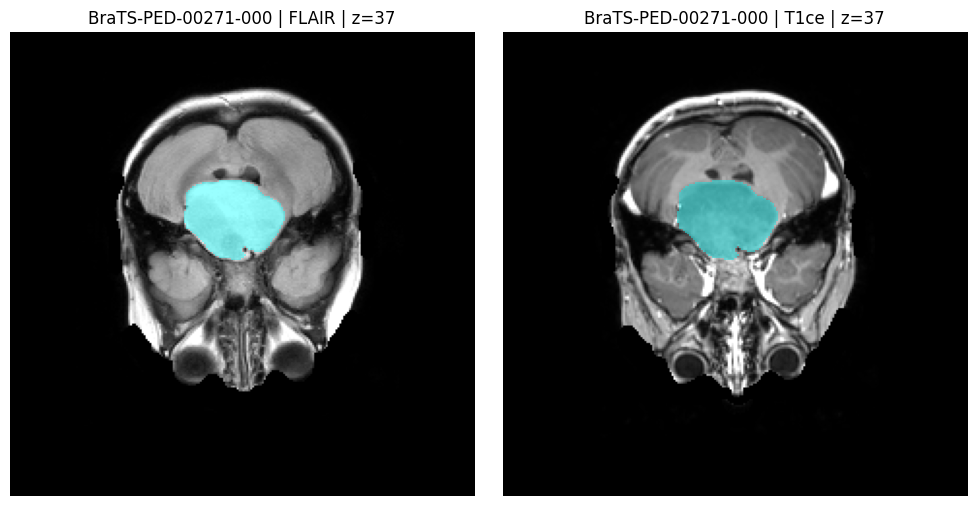

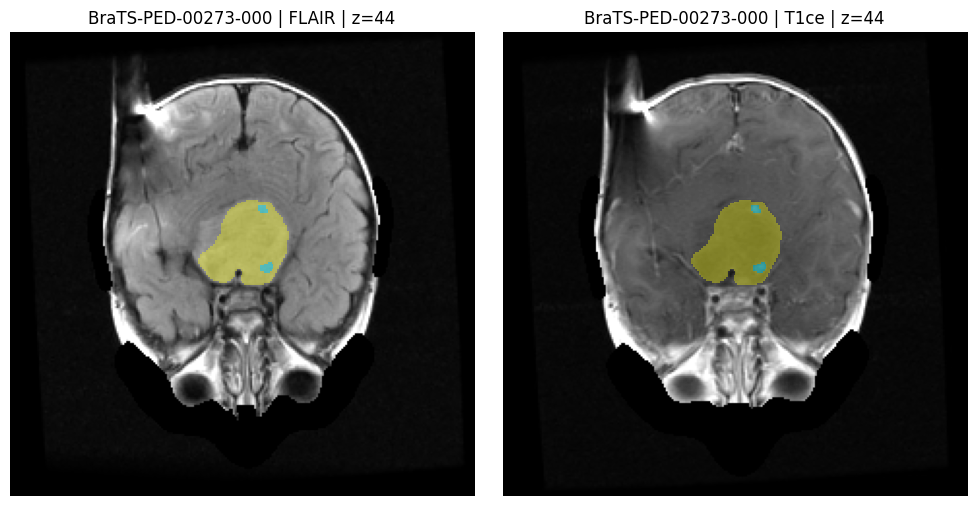

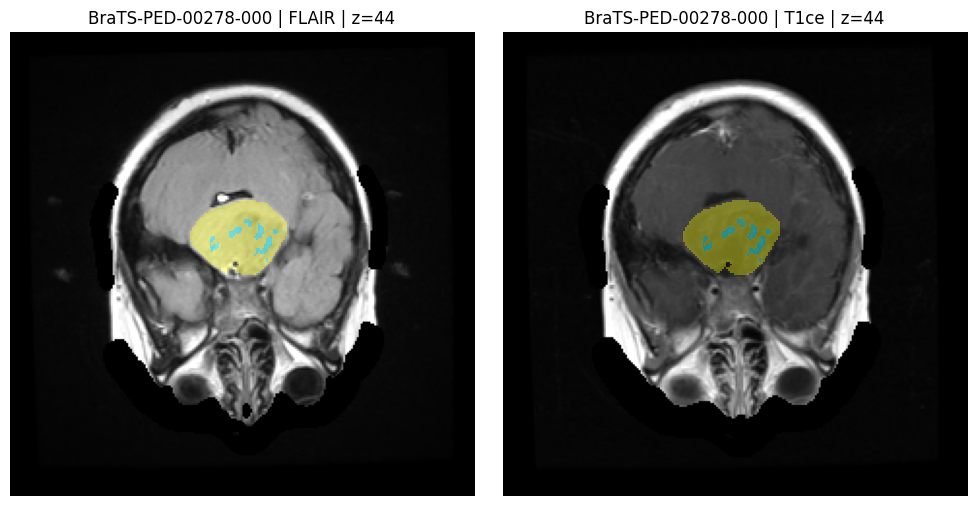

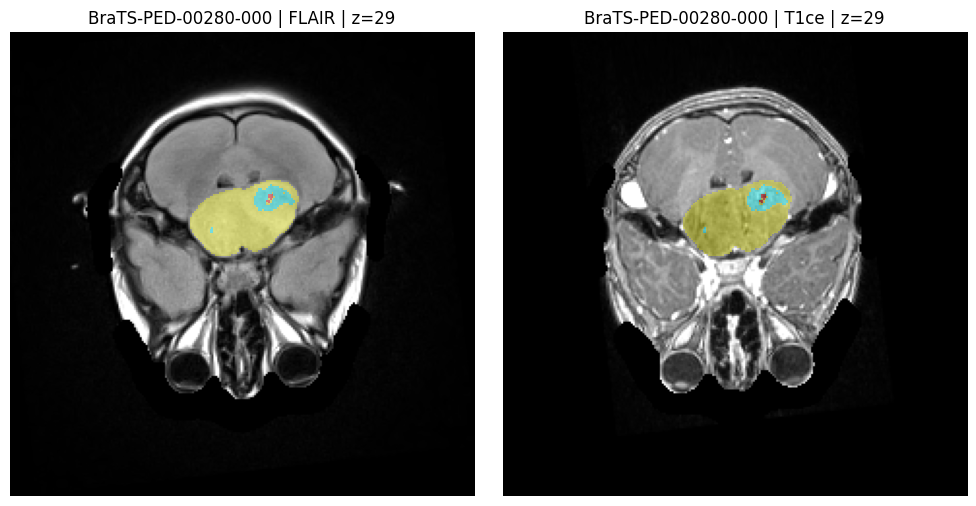

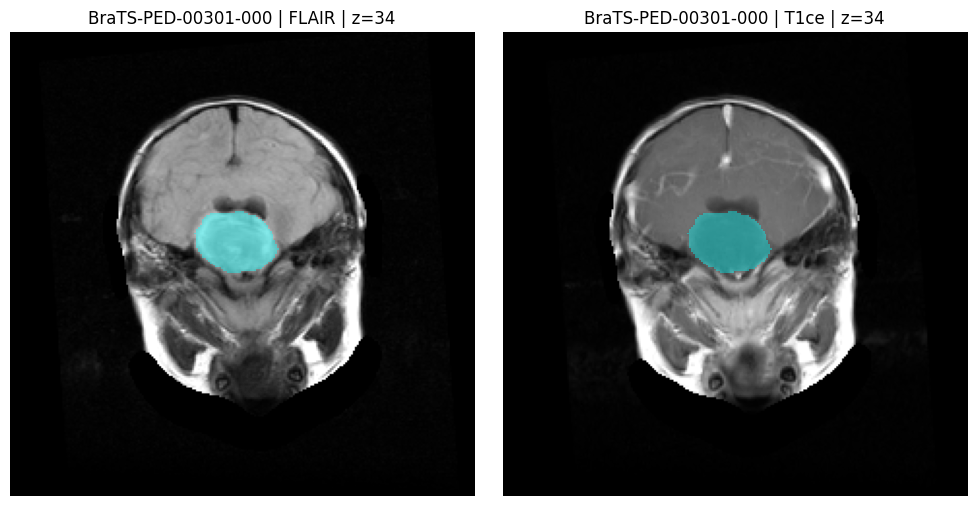

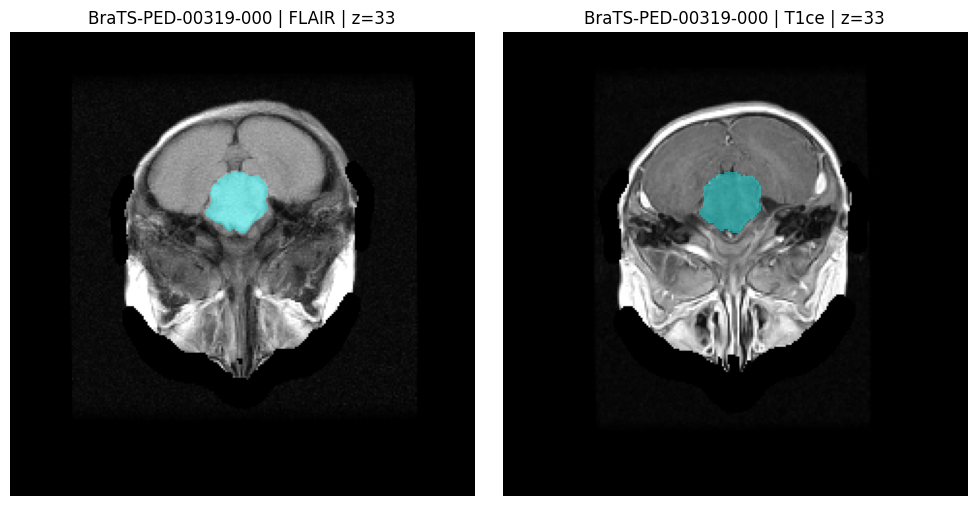

In [71]:
# Section 6.2 — Render overlays (FLAIR + pred, T1ce + pred)
from __future__ import annotations

from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

ET_LABEL = int(globals().get("ET_LABEL", 3))


def _load_nii(path: Path) -> np.ndarray:
    return np.asanyarray(nib.load(str(path)).dataobj)


def _pick_channel_idx(names: dict | None, want: str) -> int | None:
    if not names:
        return None
    # names can be like {"0": "T1", "1": "T1ce", ...} or {0: "T1", ...}
    items = []
    for k, v in names.items():
        try:
            ki = int(k)
        except Exception:
            try:
                ki = int(str(k))
            except Exception:
                continue
        items.append((ki, str(v).lower()))
    items.sort(key=lambda x: x[0])

    want = want.lower()
    for ki, nm in items:
        if want in nm:
            return ki
    # common aliases
    if want == "t1ce":
        for ki, nm in items:
            if any(x in nm for x in ["t1gd", "t1c", "ce", "t1ce"]):
                return ki
    return None


def _norm(img2d: np.ndarray) -> np.ndarray:
    x = img2d.astype(np.float32)
    lo, hi = np.percentile(x, [1, 99])
    if hi <= lo:
        return np.zeros_like(x)
    x = np.clip((x - lo) / (hi - lo), 0, 1)
    return x


# Choose channels (best-effort via dataset.json names)
idx_flair = _pick_channel_idx(channel_names, "flair")
idx_t1ce = _pick_channel_idx(channel_names, "t1ce")

# Reasonable fallbacks for BraTS-like ordering
# Typical order: 0=T1, 1=T1ce, 2=T2, 3=FLAIR
if idx_t1ce is None:
    idx_t1ce = 1
if idx_flair is None:
    idx_flair = 3

print("Channel idx selection:")
print("  FLAIR:", idx_flair)
print("  T1ce :", idx_t1ce)

# Colormap for segmentation overlay: background transparent, labels colored
# label 1: red, 2: yellow, ET_LABEL: cyan
max_label = max(ET_LABEL, 2, 1)
colors = [(0, 0, 0, 0)] * (max_label + 1)
colors[1] = (1.0, 0.0, 0.0, 0.35)
if len(colors) > 2:
    colors[2] = (1.0, 1.0, 0.0, 0.35)
if ET_LABEL < len(colors):
    colors[ET_LABEL] = (0.0, 1.0, 1.0, 0.40)
seg_cmap = ListedColormap(colors)


def show_case(case_id: str, z: int | None = None) -> None:
    p0 = images_dir / f"{case_id}_0000.nii.gz"
    pt1ce = images_dir / f"{case_id}_{idx_t1ce:04d}.nii.gz"
    pflair = images_dir / f"{case_id}_{idx_flair:04d}.nii.gz"
    segp = QC_PRED_DIR / f"{case_id}.nii.gz"

    if not p0.exists():
        raise FileNotFoundError(p0)
    if not pt1ce.exists() or not pflair.exists():
        # fallback: if only _0000 exists in some datasets, we can still show that
        pt1ce = p0
        pflair = p0

    if not segp.exists():
        raise FileNotFoundError(f"Missing prediction: {segp}")

    t1ce = _load_nii(pt1ce)
    flair = _load_nii(pflair)
    seg = _load_nii(segp).astype(np.int16)

    # choose a slice: middle of WT if present, else mid volume
    if z is None:
        wt = seg > 0
        if wt.any():
            zs = np.where(wt)[2]
            z = int(np.median(zs))
        else:
            z = int(seg.shape[2] // 2)

    t1ce2 = _norm(t1ce[:, :, z])
    flair2 = _norm(flair[:, :, z])
    seg2 = seg[:, :, z]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(flair2.T, cmap="gray", origin="lower")
    axes[0].imshow(seg2.T, cmap=seg_cmap, origin="lower", interpolation="nearest")
    axes[0].set_title(f"{case_id} | FLAIR | z={z}")
    axes[0].axis("off")

    axes[1].imshow(t1ce2.T, cmap="gray", origin="lower")
    axes[1].imshow(seg2.T, cmap=seg_cmap, origin="lower", interpolation="nearest")
    axes[1].set_title(f"{case_id} | T1ce | z={z}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


# Render selected cases
for c in qc_cases:
    show_case(c)

## Section 7 — Export a comprehensive visualisations pack

This section creates `/workspace/pediatric_tumor_data/visualisations/` and exports:
- many overlay images (FLAIR/T1ce) for `imagesTs` and `imagesTr`
- before/after post-processing comparisons (raw vs `_post`)
- summary charts (volumes, Dice histograms if GT is available)
- an `index.html` gallery so judges can browse quickly

In [72]:
# Section 7.1 — Create /workspace/pediatric_tumor_data/visualisations structure
from __future__ import annotations

from pathlib import Path
import os
import time

VIS_ROOT = Path("/workspace/pediatric_tumor_data") / "visualisations"
STAMP = time.strftime("%Y%m%d_%H%M%S")
RUN_DIR = VIS_ROOT / f"run_{STAMP}"

# Subfolders
DIRS = {
    "qc_imagesTs": RUN_DIR / "qc" / "imagesTs",
    "qc_imagesTr": RUN_DIR / "qc" / "imagesTr",
    "compare_imagesTs": RUN_DIR / "comparisons" / "imagesTs_raw_vs_post",
    "compare_imagesTr": RUN_DIR / "comparisons" / "imagesTr_raw_vs_post",
    "metrics": RUN_DIR / "metrics",
    "volumes": RUN_DIR / "volumes",
    "gallery": RUN_DIR / "gallery",
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

print("Created visualisations folder:")
print("  VIS_ROOT:", VIS_ROOT)
print("  RUN_DIR :", RUN_DIR)
for k, p in DIRS.items():
    print(f"  {k}: {p}")

Created visualisations folder:
  VIS_ROOT: /workspace/pediatric_tumor_data/visualisations
  RUN_DIR : /workspace/pediatric_tumor_data/visualisations/run_20260127_100402
  qc_imagesTs: /workspace/pediatric_tumor_data/visualisations/run_20260127_100402/qc/imagesTs
  qc_imagesTr: /workspace/pediatric_tumor_data/visualisations/run_20260127_100402/qc/imagesTr
  compare_imagesTs: /workspace/pediatric_tumor_data/visualisations/run_20260127_100402/comparisons/imagesTs_raw_vs_post
  compare_imagesTr: /workspace/pediatric_tumor_data/visualisations/run_20260127_100402/comparisons/imagesTr_raw_vs_post
  metrics: /workspace/pediatric_tumor_data/visualisations/run_20260127_100402/metrics
  volumes: /workspace/pediatric_tumor_data/visualisations/run_20260127_100402/volumes
  gallery: /workspace/pediatric_tumor_data/visualisations/run_20260127_100402/gallery


In [73]:
# Section 7.2 — Locate raw data + prediction folders (imagesTs/imagesTr, raw/post)
from __future__ import annotations

from pathlib import Path
import os

raw_root = Path(os.environ["nnUNet_raw"])
raw_ds_dirs = sorted([p for p in raw_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
raw_dataset_dir = raw_ds_dirs[0] if raw_ds_dirs else None
if raw_dataset_dir is None:
    raise RuntimeError("Could not locate nnU-Net raw dataset directory")

results_root = Path(os.environ["nnUNet_results"])
notebook_runs = results_root / "notebook_runs"


def _latest_dir(glob_pat: str) -> Path | None:
    cands = sorted(notebook_runs.glob(glob_pat), key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0] if cands else None


# Latest runs by pattern (best-effort)
latest_ts_raw = _latest_dir(f"pred_d{DATASET_ID}_{CONFIG}_imagesTs_*")
latest_tr_raw = _latest_dir(f"pred_d{DATASET_ID}_{CONFIG}_imagesTr_*")

# If the latest dir is already *_post, derive raw by stripping suffix

def _raw_post_pair(p: Path | None) -> tuple[Path | None, Path | None]:
    if p is None:
        return None, None
    if str(p).endswith("_post"):
        post = p
        raw = Path(str(p)[:-5])
        return (raw if raw.exists() else None), post
    post = Path(str(p) + "_post")
    return p, (post if post.exists() else None)


TS_RAW, TS_POST = _raw_post_pair(latest_ts_raw)
TR_RAW, TR_POST = _raw_post_pair(latest_tr_raw)

print("Raw dataset:", raw_dataset_dir)
print("Notebook runs:", notebook_runs)
print("\nimagesTs")
print("  raw :", TS_RAW)
print("  post:", TS_POST)
print("imagesTr")
print("  raw :", TR_RAW)
print("  post:", TR_POST)

# Prefer current session outputs if they match the configured split
cur_pred = Path(globals().get("PREDICT_OUT_DIR", "")) if "PREDICT_OUT_DIR" in globals() else None
cur_sub = Path(globals().get("SUBMISSION_DIR", "")) if "SUBMISSION_DIR" in globals() else None
if cur_pred and cur_pred.exists() and "imagesTs" in str(cur_pred):
    TS_RAW = cur_pred
if cur_sub and cur_sub.exists() and "imagesTs" in str(cur_sub):
    TS_POST = cur_sub

print("\nAfter considering current session vars:")
print("  TS_RAW :", TS_RAW)
print("  TS_POST:", TS_POST)

Raw dataset: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw/Dataset501_BraTS_PEDs2024
Notebook runs: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs

imagesTs
  raw : /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260127_080755
  post: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260127_080755_post
imagesTr
  raw : /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTr_20260126_161109
  post: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTr_20260126_161109_post

After considering current session vars:
  TS_RAW : /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260127_080755
  TS_POST: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/pred_d501_3d_fullres_imagesTs_20260127_080755_post

In [74]:
# Section 7.3 — Bulk export overlays + comparisons + summary plots
from __future__ import annotations

from pathlib import Path
import os
import json
import math
import random
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Controls (tune these to control how “many” images you export)
EXPORT_TS_ALL = bool(globals().get("EXPORT_TS_ALL", True))      # export all 91 imagesTs cases
EXPORT_TR_SAMPLE = int(globals().get("EXPORT_TR_SAMPLE", 40))  # export this many imagesTr cases (0 to skip)
EXPORT_COMPARE = bool(globals().get("EXPORT_COMPARE", True))   # raw vs post side-by-side
EXPORT_PLOTS = bool(globals().get("EXPORT_PLOTS", True))

QC_RANDOM_SEED = int(globals().get("QC_RANDOM_SEED", 123))

# Modalities/channels
ET_LABEL = int(globals().get("ET_LABEL", 3))

# Determine channel -> modality mapping (best-effort)
dataset_json = raw_dataset_dir / "dataset.json"
channel_names = None
if dataset_json.exists():
    try:
        ds = json.loads(dataset_json.read_text(encoding="utf-8"))
        channel_names = ds.get("channel_names") or ds.get("modality")
    except Exception:
        channel_names = None


def _pick_channel_idx(names: dict | None, want: str) -> int | None:
    if not names:
        return None
    items = []
    for k, v in names.items():
        try:
            ki = int(k)
        except Exception:
            try:
                ki = int(str(k))
            except Exception:
                continue
        items.append((ki, str(v).lower()))
    items.sort(key=lambda x: x[0])

    want = want.lower()
    for ki, nm in items:
        if want in nm:
            return ki
    if want == "t1ce":
        for ki, nm in items:
            if any(x in nm for x in ["t1gd", "t1c", "ce", "t1ce"]):
                return ki
    return None


def _norm(img2d: np.ndarray) -> np.ndarray:
    x = img2d.astype(np.float32)
    lo, hi = np.percentile(x, [1, 99])
    if hi <= lo:
        return np.zeros_like(x)
    return np.clip((x - lo) / (hi - lo), 0, 1)


def _load(path: Path) -> np.ndarray:
    return np.asanyarray(nib.load(str(path)).dataobj)


idx_t1ce = _pick_channel_idx(channel_names, "t1ce")
idx_flair = _pick_channel_idx(channel_names, "flair")
if idx_t1ce is None:
    idx_t1ce = 1
if idx_flair is None:
    idx_flair = 3

# Transparent background + colored labels (1 red, 2 yellow, ET cyan)
max_label = max(ET_LABEL, 2, 1)
colors = [(0, 0, 0, 0)] * (max_label + 1)
colors[1] = (1.0, 0.0, 0.0, 0.35)
if len(colors) > 2:
    colors[2] = (1.0, 1.0, 0.0, 0.35)
if ET_LABEL < len(colors):
    colors[ET_LABEL] = (0.0, 1.0, 1.0, 0.40)
seg_cmap = ListedColormap(colors)


def _slice_z(seg: np.ndarray) -> int:
    wt = seg > 0
    if wt.any():
        zs = np.where(wt)[2]
        return int(np.median(zs))
    return int(seg.shape[2] // 2)


def _render_pair(case_id: str, split_dir: Path, pred_path: Path, out_png: Path, z: int | None = None, title_suffix: str = ""):
    p0 = split_dir / f"{case_id}_0000.nii.gz"
    pt1ce = split_dir / f"{case_id}_{idx_t1ce:04d}.nii.gz"
    pflair = split_dir / f"{case_id}_{idx_flair:04d}.nii.gz"

    if not p0.exists():
        raise FileNotFoundError(p0)
    if not pt1ce.exists() or not pflair.exists():
        # fallback if only _0000 exists
        pt1ce = p0
        pflair = p0

    seg = _load(pred_path).astype(np.int16)
    if z is None:
        z = _slice_z(seg)

    t1ce = _norm(_load(pt1ce)[:, :, z])
    flair = _norm(_load(pflair)[:, :, z])
    seg2 = seg[:, :, z]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(flair.T, cmap="gray", origin="lower")
    axes[0].imshow(seg2.T, cmap=seg_cmap, origin="lower", interpolation="nearest")
    axes[0].set_title(f"{case_id} | FLAIR | z={z}{title_suffix}")
    axes[0].axis("off")

    axes[1].imshow(t1ce.T, cmap="gray", origin="lower")
    axes[1].imshow(seg2.T, cmap=seg_cmap, origin="lower", interpolation="nearest")
    axes[1].set_title(f"{case_id} | T1ce | z={z}{title_suffix}")
    axes[1].axis("off")

    plt.tight_layout()
    fig.savefig(out_png, dpi=140)
    plt.close(fig)


def _render_compare(case_id: str, split_dir: Path, raw_pred: Path, post_pred: Path, out_png: Path):
    seg_raw = _load(raw_pred).astype(np.int16)
    seg_post = _load(post_pred).astype(np.int16)
    z = _slice_z(seg_post)

    # background from FLAIR for interpretability
    pflair = split_dir / f"{case_id}_{idx_flair:04d}.nii.gz"
    p0 = split_dir / f"{case_id}_0000.nii.gz"
    if not pflair.exists():
        pflair = p0
    bg = _norm(_load(pflair)[:, :, z])

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(bg.T, cmap="gray", origin="lower")
    axes[0].imshow(seg_raw[:, :, z].T, cmap=seg_cmap, origin="lower", interpolation="nearest")
    axes[0].set_title(f"{case_id} | RAW pred | z={z}")
    axes[0].axis("off")

    axes[1].imshow(bg.T, cmap="gray", origin="lower")
    axes[1].imshow(seg_post[:, :, z].T, cmap=seg_cmap, origin="lower", interpolation="nearest")
    axes[1].set_title(f"{case_id} | POST pred | z={z}")
    axes[1].axis("off")

    plt.tight_layout()
    fig.savefig(out_png, dpi=140)
    plt.close(fig)


def _hist(data: np.ndarray, title: str, out_png: Path, bins: int = 60, log: bool = True):
    fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
    ax.hist(data, bins=bins)
    ax.set_title(title)
    ax.set_xlabel("voxels")
    ax.set_ylabel("count")
    if log:
        ax.set_xscale("log")
    fig.tight_layout()
    fig.savefig(out_png, dpi=160)
    plt.close(fig)


def _voxel_counts(pred_dir: Path) -> dict[str, np.ndarray]:
    counts = {"WT": [], "TC": [], "ET": []}
    files = sorted(pred_dir.glob("*.nii.gz"))
    for pf in files:
        seg = _load(pf).astype(np.int16)
        wt = int((seg > 0).sum())
        # TC: label==1 or ==ET_LABEL (BraTS-like core). If your mapping differs, adjust here.
        tc = int(((seg == 1) | (seg == ET_LABEL)).sum())
        et = int((seg == ET_LABEL).sum())
        counts["WT"].append(wt)
        counts["TC"].append(tc)
        counts["ET"].append(et)
    return {k: np.array(v, dtype=np.int64) for k, v in counts.items()}


print("Export settings:")
print("  EXPORT_TS_ALL:", EXPORT_TS_ALL)
print("  EXPORT_TR_SAMPLE:", EXPORT_TR_SAMPLE)
print("  EXPORT_COMPARE:", EXPORT_COMPARE)
print("  EXPORT_PLOTS:", EXPORT_PLOTS)
print("  Channels: FLAIR idx", idx_flair, "| T1ce idx", idx_t1ce)

# Build case lists
rng = random.Random(QC_RANDOM_SEED)

# imagesTs
split_ts = raw_dataset_dir / "imagesTs"
ts_case_ids = sorted([p.name.replace("_0000.nii.gz", "") for p in split_ts.glob("*_0000.nii.gz")])
if not ts_case_ids:
    raise RuntimeError("No imagesTs cases found")

if TS_POST is None:
    raise RuntimeError("TS_POST not found (need postprocessed imagesTs folder)")

ts_cases = ts_case_ids if EXPORT_TS_ALL else (rng.sample(ts_case_ids, min(20, len(ts_case_ids))))

# imagesTr
split_tr = raw_dataset_dir / "imagesTr"
tr_case_ids = sorted([p.name.replace("_0000.nii.gz", "") for p in split_tr.glob("*_0000.nii.gz")])
tr_cases = []
if EXPORT_TR_SAMPLE > 0 and tr_case_ids:
    tr_cases = rng.sample(tr_case_ids, min(EXPORT_TR_SAMPLE, len(tr_case_ids)))
    tr_cases = sorted(tr_cases)

# Export overlays

def _safe(name: str) -> str:
    return name.replace("/", "_").replace("\\", "_")

print("\nExporting overlays...")

# imagesTs overlays (post)
for i, cid in enumerate(ts_cases, start=1):
    pred = TS_POST / f"{cid}.nii.gz"
    if not pred.exists():
        continue
    out_png = DIRS["qc_imagesTs"] / f"{_safe(cid)}.png"
    _render_pair(cid, split_ts, pred, out_png)
    if i % 25 == 0:
        print(f"  imagesTs overlays: {i}/{len(ts_cases)}")

# imagesTr overlays (post, sample)
if tr_cases:
    # Prefer TR_POST if present, else TR_RAW
    pred_dir = TR_POST if TR_POST is not None else TR_RAW
    if pred_dir is not None:
        for i, cid in enumerate(tr_cases, start=1):
            pred = pred_dir / f"{cid}.nii.gz"
            if not pred.exists():
                continue
            out_png = DIRS["qc_imagesTr"] / f"{_safe(cid)}.png"
            _render_pair(cid, split_tr, pred, out_png)
            if i % 25 == 0:
                print(f"  imagesTr overlays: {i}/{len(tr_cases)}")

# Export raw vs post comparisons
if EXPORT_COMPARE and TS_RAW is not None and TS_POST is not None:
    print("\nExporting raw vs post comparisons...")
    for i, cid in enumerate(ts_cases, start=1):
        raw_p = TS_RAW / f"{cid}.nii.gz"
        post_p = TS_POST / f"{cid}.nii.gz"
        if not raw_p.exists() or not post_p.exists():
            continue
        out_png = DIRS["compare_imagesTs"] / f"{_safe(cid)}_raw_vs_post.png"
        _render_compare(cid, split_ts, raw_p, post_p, out_png)
        if i % 25 == 0:
            print(f"  imagesTs comparisons: {i}/{len(ts_cases)}")

# Summary plots (volumes)
if EXPORT_PLOTS:
    print("\nExporting summary plots...")
    ts_counts = _voxel_counts(TS_POST)
    for region in ("WT", "TC", "ET"):
        _hist(ts_counts[region] + 1, f"imagesTs predicted {region} voxel counts (+1) | postprocessed", DIRS["volumes"] / f"imagesTs_{region}_hist.png")

    # Optional: imagesTr pred vs GT volumes if labelsTr is present and we have a prediction dir
    labels_tr = raw_dataset_dir / "labelsTr"
    pred_dir_tr = TR_POST if TR_POST is not None else TR_RAW
    if labels_tr.exists() and pred_dir_tr is not None and pred_dir_tr.exists():
        # GT volumes
        gt_counts = {"WT": [], "TC": [], "ET": []}
        pr_counts = {"WT": [], "TC": [], "ET": []}
        files = sorted([p for p in pred_dir_tr.glob("*.nii.gz")])
        for idx, pf in enumerate(files, start=1):
            gt_path = labels_tr / pf.name
            if not gt_path.exists():
                continue
            pr = _load(pf).astype(np.int16)
            gt = _load(gt_path).astype(np.int16)
            pr_counts["WT"].append(int((pr > 0).sum()))
            gt_counts["WT"].append(int((gt > 0).sum()))
            pr_counts["TC"].append(int(((pr == 1) | (pr == ET_LABEL)).sum()))
            gt_counts["TC"].append(int(((gt == 1) | (gt == ET_LABEL)).sum()))
            pr_counts["ET"].append(int((pr == ET_LABEL).sum()))
            gt_counts["ET"].append(int((gt == ET_LABEL).sum()))
            if idx % 75 == 0:
                print(f"  volumes imagesTr: processed {idx}/{len(files)}")

        for region in ("WT", "TC", "ET"):
            _hist(np.array(gt_counts[region], dtype=np.int64) + 1, f"imagesTr GT {region} voxel counts (+1)", DIRS["volumes"] / f"imagesTr_GT_{region}_hist.png")
            _hist(np.array(pr_counts[region], dtype=np.int64) + 1, f"imagesTr Pred {region} voxel counts (+1)", DIRS["volumes"] / f"imagesTr_Pred_{region}_hist.png")

print("\n[OK] Visualisations export completed.")
print("Open folder:", RUN_DIR)

Export settings:
  EXPORT_TS_ALL: True
  EXPORT_TR_SAMPLE: 40
  EXPORT_COMPARE: True
  EXPORT_PLOTS: True
  Channels: FLAIR idx 3 | T1ce idx 1

Exporting overlays...
  imagesTs overlays: 25/91
  imagesTs overlays: 50/91
  imagesTs overlays: 75/91
  imagesTr overlays: 25/40

Exporting raw vs post comparisons...
  imagesTs comparisons: 25/91
  imagesTs comparisons: 50/91
  imagesTs comparisons: 75/91

Exporting summary plots...
  volumes imagesTr: processed 75/260
  volumes imagesTr: processed 150/260
  volumes imagesTr: processed 225/260

[OK] Visualisations export completed.
Open folder: /workspace/pediatric_tumor_data/visualisations/run_20260127_100402


In [77]:
# Section 7.4 — Build a simple HTML gallery for judges
from __future__ import annotations

from pathlib import Path
import hashlib
import html
import shutil


def _stage_asset(*, run_dir: Path, assets_dir: Path, src: Path) -> Path:
    """Copy an image into gallery/assets and return its URL path (relative to gallery HTML)."""
    try:
        rel_under_run = src.relative_to(run_dir)
        dst = assets_dir / rel_under_run
        url = Path("assets") / rel_under_run
    except ValueError:
        # If somehow outside RUN_DIR, still include it deterministically
        h = hashlib.sha1(str(src).encode("utf-8")).hexdigest()[:10]
        dst = assets_dir / "external" / f"{h}_{src.name}"
        url = Path("assets") / "external" / f"{h}_{src.name}"

    dst.parent.mkdir(parents=True, exist_ok=True)
    if not dst.exists():
        shutil.copy2(src, dst)
    return url


def _write_gallery(title: str, image_paths: list[Path], out_html: Path, run_dir: Path):
    out_html.parent.mkdir(parents=True, exist_ok=True)
    assets_dir = out_html.parent / "assets"
    assets_dir.mkdir(parents=True, exist_ok=True)

    rows: list[str] = []
    for p in image_paths:
        url = _stage_asset(run_dir=run_dir, assets_dir=assets_dir, src=p)
        rows.append(
            f"<div class='card'><a href='{url.as_posix()}' target='_blank'>"
            f"<img src='{url.as_posix()}' loading='lazy'/></a>"
            f"<div class='cap'>{html.escape(p.stem)}</div></div>"
        )

    page = f"""<!doctype html>
<html>
<head>
<meta charset='utf-8'/>
<title>{html.escape(title)}</title>
<style>
body {{ font-family: Arial, sans-serif; margin: 16px; }}
.grid {{ display: grid; grid-template-columns: repeat(auto-fill, minmax(320px, 1fr)); gap: 12px; }}
.card {{ border: 1px solid #ddd; border-radius: 8px; padding: 8px; }}
img {{ width: 100%; height: auto; border-radius: 6px; }}
.cap {{ margin-top: 6px; font-size: 12px; color: #444; word-break: break-all; }}
.small {{ color: #666; font-size: 12px; }}
</style>
</head>
<body>
<h2>{html.escape(title)}</h2>
<p class='small'>Generated from {html.escape(str(RUN_DIR))}</p>
<div class='grid'>
{''.join(rows)}
</div>
</body>
</html>"""
    out_html.write_text(page, encoding="utf-8")


gallery_dir = RUN_DIR / "gallery"
gallery_dir.mkdir(parents=True, exist_ok=True)

# Collect images
qc_ts_imgs = sorted(DIRS["qc_imagesTs"].glob("*.png"))
qc_tr_imgs = sorted(DIRS["qc_imagesTr"].glob("*.png"))
cmp_ts_imgs = sorted(DIRS["compare_imagesTs"].glob("*.png"))
plot_imgs = sorted(DIRS["volumes"].glob("*.png"))

index = RUN_DIR / "index.html"
parts: list[str] = []

# Write sub-galleries
if qc_ts_imgs:
    _write_gallery("QC overlays — imagesTs", qc_ts_imgs, gallery_dir / "qc_imagesTs.html", RUN_DIR)
    parts.append("<li><a href='gallery/qc_imagesTs.html'>QC overlays — imagesTs</a></li>")
if qc_tr_imgs:
    _write_gallery("QC overlays — imagesTr", qc_tr_imgs, gallery_dir / "qc_imagesTr.html", RUN_DIR)
    parts.append("<li><a href='gallery/qc_imagesTr.html'>QC overlays — imagesTr</a></li>")
if cmp_ts_imgs:
    _write_gallery("Raw vs Post comparisons — imagesTs", cmp_ts_imgs, gallery_dir / "compare_imagesTs.html", RUN_DIR)
    parts.append("<li><a href='gallery/compare_imagesTs.html'>Raw vs Post — imagesTs</a></li>")
if plot_imgs:
    _write_gallery("Summary plots", plot_imgs, gallery_dir / "plots.html", RUN_DIR)
    parts.append("<li><a href='gallery/plots.html'>Summary plots</a></li>")

index_html = f"""<!doctype html>
<html>
<head>
<meta charset='utf-8'/>
<title>Visualisations Pack</title>
<style>body {{ font-family: Arial, sans-serif; margin: 16px; }}</style>
</head>
<body>
<h2>Visualisations Pack</h2>
<p>Folder: <code>{RUN_DIR}</code></p>
<ul>
{''.join(parts) if parts else '<li>(No PNGs found)</li>'}
</ul>
</body>
</html>"""
index.write_text(index_html, encoding="utf-8")

print("Wrote gallery index:", index)
print("Staged assets under:", gallery_dir / "assets")

Wrote gallery index: /workspace/pediatric_tumor_data/visualisations/run_20260127_100402/index.html
Staged assets under: /workspace/pediatric_tumor_data/visualisations/run_20260127_100402/gallery/assets


In [ ]:
# Section 7.5 — Backup /workspace/pediatric_tumor_data as an archive (for local download)
from __future__ import annotations

from pathlib import Path
import subprocess
import time

SRC_DIR = Path("/workspace/pediatric_tumor_data")
BACKUP_DIR = Path("/workspace/pediatric_tumor_data_backups")
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

# Safety switch (folder can be very large).
CONFIRM_BACKUP = True

# Optional: exclude bulky folders (uncomment if you *don't* need them).
# EXCLUDES = ["nnunetv2/nnUNet_preprocessed", "nnunetv2/nnUNet_results"]
EXCLUDES: list[str] = []

def _run(cmd: list[str]) -> str:
    p = subprocess.run(cmd, capture_output=True, text=True)
    if p.returncode != 0:
        raise RuntimeError(f"Command failed ({p.returncode}): {' '.join(cmd)}\n{p.stderr}")
    return p.stdout.strip()

print("Source:", SRC_DIR)
print("Backup dir:", BACKUP_DIR)

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Not found: {SRC_DIR}")

# Quick size + free space checks
try:
    print("Size:", _run(["du", "-sh", str(SRC_DIR)]))
except Exception as exc:
    print("[WARN] Could not run du -sh:", exc)

try:
    # df -h on the filesystem where the archive will be written
    print("Free:", _run(["df", "-h", str(BACKUP_DIR)]))
except Exception as exc:
    print("[WARN] Could not run df -h:", exc)

stamp = time.strftime("%Y%m%d_%H%M%S")
archive_path = BACKUP_DIR / f"pediatric_tumor_data_{stamp}.tar.gz"

if not CONFIRM_BACKUP:
    print("\n[INFO] Backup is NOT running because CONFIRM_BACKUP=False")
    print("Set CONFIRM_BACKUP=True and re-run this cell to create:")
    print(" ", archive_path)
else:
    # Create tar.gz: tar -czf <archive> -C <parent> <foldername> [--exclude ...]
    tar_cmd = ["tar", "-czf", str(archive_path)]
    for ex in EXCLUDES:
        tar_cmd += ["--exclude", ex]
    tar_cmd += ["-C", str(SRC_DIR.parent), SRC_DIR.name]

    print("\n[RUN]", " ".join(tar_cmd))
    t0 = time.time()
    subprocess.run(tar_cmd, check=True)
    dt = time.time() - t0

    print("\n[OK] Wrote:", archive_path)
    print("Time (min):", round(dt / 60, 2))
    try:
        print("Archive size:", _run(["ls", "-lh", str(archive_path)]))
    except Exception:
        pass
    try:
        print("SHA256:", _run(["sha256sum", str(archive_path)]))
    except Exception:
        print("[WARN] sha256sum not available")
    print("\nNext: download this archive to your local machine.")

Source: /workspace/pediatric_tumor_data
Backup dir: /workspace/pediatric_tumor_data_backups
Size: 54G	/workspace/pediatric_tumor_data
Free: Filesystem               Size  Used Avail Use% Mounted on
172.16.225.216:/pratham  190G  130G   61G  69% /workspace

[RUN] tar -czf /workspace/pediatric_tumor_data_backups/pediatric_tumor_data_20260127_104431.tar.gz -C /workspace pediatric_tumor_data


In [ ]:
# Section 7.6 — Upload /workspace/pediatric_tumor_data to Google Drive (no local PC transfer)
#
# Approach: rclone + Google Drive remote
# - Runs entirely on the remote server
# - Requires a one-time Google OAuth approval (copy/paste code) OR a service account
# - Upload can be launched with nohup so it keeps running if you disconnect

from __future__ import annotations

import os
import subprocess
from pathlib import Path

SRC_DIR = Path("/workspace/pediatric_tumor_data")

# Where rclone will store its config (keep in /workspace so it's persistent)
RCLONE_CONFIG_DIR = Path("/workspace/.config/rclone")
RCLONE_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
RCLONE_CONFIG = RCLONE_CONFIG_DIR / "rclone.conf"

# Name of the rclone remote (you'll create this in the next cell)
RCLONE_REMOTE_NAME = "gdrive"

print("SRC_DIR:", SRC_DIR)
print("RCLONE_CONFIG:", RCLONE_CONFIG)

# 1) Ensure rclone exists
try:
    out = subprocess.check_output(["rclone", "version"], text=True)
    print(out.splitlines()[0])
except Exception:
    print("[INFO] rclone not found; installing...")
    # Debian/Ubuntu-safe install (works on most Jupyter GPU images)
    subprocess.run(["bash", "-lc", "curl -fsSL https://rclone.org/install.sh | bash"], check=True)
    out = subprocess.check_output(["rclone", "version"], text=True)
    print(out.splitlines()[0])

print("\nNext: run Section 7.6B to configure the Google Drive remote.")
print("If you already configured it, you can skip to Section 7.7.")

In [ ]:
# Section 7.6B — One-time rclone config for Google Drive (OAuth)
#
# This does NOT upload anything yet.
# It will open a URL in the output. You approve access in your Google account, then paste the code back.
# Minimal PC involvement: only for OAuth approval.

from __future__ import annotations

import os
import subprocess
from pathlib import Path

RCLONE_CONFIG = Path("/workspace/.config/rclone/rclone.conf")
RCLONE_REMOTE_NAME = "gdrive"

print("Config path:", RCLONE_CONFIG)
print("Remote name:", RCLONE_REMOTE_NAME)

# Use rclone's interactive config. If the environment has no browser, choose 'n' for auto config.
# Then rclone prints a URL; open it anywhere, approve, paste the code back.
cmd = f"RCLONE_CONFIG={RCLONE_CONFIG} rclone config"
print("\n[RUN]", cmd)
print("Follow the prompts:")
print("- New remote? -> n")
print(f"- name -> {RCLONE_REMOTE_NAME}")
print("- Storage -> drive")
print("- client_id/client_secret -> leave blank (or set your own)")
print("- scope -> 1 (Full access) or 2 (Read-only won't work for upload)")
print("- root_folder_id -> blank")
print("- service_account_file -> blank (unless you use service account)")
print("- Edit advanced config -> n")
print("- Use auto config -> n (if no browser on server)")
print("\nIf you want zero-interaction later, consider using a Google Cloud service account.")

# Launch interactive config in the notebook cell
subprocess.run(["bash", "-lc", cmd], check=True)

print("\n[OK] Config complete. Verify remotes:")
subprocess.run(["bash", "-lc", f"RCLONE_CONFIG={RCLONE_CONFIG} rclone listremotes"], check=True)

In [ ]:
# Section 7.7 — Start remote upload (continues even if you disconnect)
#
# Uses nohup so the copy keeps running without the notebook staying open.

from __future__ import annotations

import shlex
import subprocess
import time
from pathlib import Path

SRC_DIR = Path("/workspace/pediatric_tumor_data")
RCLONE_CONFIG = Path("/workspace/.config/rclone/rclone.conf")
RCLONE_REMOTE_NAME = "gdrive"

# Destination folder *in your Drive* (it will create this folder if needed)
GDRIVE_DEST = f"{RCLONE_REMOTE_NAME}:pediatric_tumor_data_backup"

# Where logs + PID are written
RUN_DIR = Path("/workspace/pediatric_tumor_data_backups")
RUN_DIR.mkdir(parents=True, exist_ok=True)
stamp = time.strftime("%Y%m%d_%H%M%S")
LOG = RUN_DIR / f"rclone_upload_{stamp}.log"
PID_FILE = RUN_DIR / f"rclone_upload_{stamp}.pid"

# You can tune these for speed/reliability
TRANSFERS = 4
CHECKERS = 8
BW_LIMIT = "0"  # e.g. "20M" to cap upload

# Safety switch
CONFIRM_UPLOAD = False

base_cmd = [
    "rclone",
    "copy",
    str(SRC_DIR),
    GDRIVE_DEST,
    "--config",
    str(RCLONE_CONFIG),
    "--create-empty-src-dirs",
    "--transfers",
    str(TRANSFERS),
    "--checkers",
    str(CHECKERS),
    "--drive-chunk-size",
    "64M",
    "--stats",
    "30s",
    "--stats-one-line",
    "--progress",
]
if BW_LIMIT and BW_LIMIT != "0":
    base_cmd += ["--bwlimit", BW_LIMIT]

print("Will upload:", SRC_DIR)
print("To:", GDRIVE_DEST)
print("Log:", LOG)
print("PID:", PID_FILE)
print("\nCommand:")
print(" ", " ".join(shlex.quote(x) for x in base_cmd))

if not CONFIRM_UPLOAD:
    print("\n[INFO] Upload NOT started because CONFIRM_UPLOAD=False")
    print("Set CONFIRM_UPLOAD=True and re-run this cell.")
else:
    # nohup ... > LOG 2>&1 & echo $! > PID_FILE
    cmd = "nohup " + " ".join(shlex.quote(x) for x in base_cmd) + f" > {shlex.quote(str(LOG))} 2>&1 & echo $! > {shlex.quote(str(PID_FILE))}"
    print("\n[RUN]", cmd)
    subprocess.run(["bash", "-lc", cmd], check=True)
    print("\n[OK] Upload started.")
    print("Use the next cell to monitor progress.")

In [ ]:
# Section 7.8 — Monitor upload status (tail log + check PID)
from __future__ import annotations

import glob
import os
import subprocess
from pathlib import Path

RUN_DIR = Path("/workspace/pediatric_tumor_data_backups")

pid_files = sorted(RUN_DIR.glob("rclone_upload_*.pid"))
log_files = sorted(RUN_DIR.glob("rclone_upload_*.log"))

if not pid_files or not log_files:
    print("No upload PID/LOG files found yet in:", RUN_DIR)
else:
    pid_file = pid_files[-1]
    log_file = log_files[-1]
    pid = int(pid_file.read_text().strip())

    print("Latest PID file:", pid_file)
    print("Latest LOG file:", log_file)
    print("PID:", pid)

    # Check process exists
    ps = subprocess.run(["bash", "-lc", f"ps -p {pid} -o pid,stat,etimes,cmd"], capture_output=True, text=True)
    if ps.returncode != 0:
        print("\n[INFO] Process not running (ps returned non-zero).")
        print("Last 50 log lines:")
        subprocess.run(["bash", "-lc", f"tail -n 50 {log_file}"], check=False)
    else:
        print("\n[OK] Process appears to be running:")
        print(ps.stdout)
        print("Last 20 log lines:")
        subprocess.run(["bash", "-lc", f"tail -n 20 {log_file}"], check=False)

print("\nTip: You can safely disconnect; nohup keeps it running.")

# Section 8 — Model Comparison: Benchmarking nnU-Net v2 Against Alternatives

Rationale: Show why nnU-Net v2 3d_fullres + ensemble is the best choice for pediatric BraTS.

In [36]:
# Section 8.0 — Dependencies (auto-install if missing)

from __future__ import annotations

import importlib
import sys
import subprocess

REQUIRED = ["nibabel", "scipy", "seaborn"]
missing = []
for pkg in REQUIRED:
    try:
        importlib.import_module(pkg)
    except Exception:
        missing.append(pkg)

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages already installed")

# Re-import after install
import nibabel as nib  # noqa: F401
from scipy import ndimage  # noqa: F401
import seaborn as sns  # noqa: F401
print("✓ Dependencies ready")

All required packages already installed
✓ Dependencies ready


In [37]:
# Section 8.1 — Setup: Define models to compare

from __future__ import annotations

from pathlib import Path
import json
import numpy as np
import pandas as pd

# Models to benchmark
MODELS_TO_COMPARE = {
    "nnUNet v2 3d_fullres (5-fold ensemble)": {
        "type": "nnunet_existing",
        "config": "3d_fullres",
        "ensem_folds": [0, 1, 2, 3, 4],
        "desc": "Main pipeline (already trained)"
    },
    "nnUNet v2 3d_lowres": {
        "type": "nnunet_config",
        "config": "3d_lowres",
        "ensem_folds": [0, 1, 2, 3, 4],
        "desc": "Lower resolution for speed"
    },
    "nnUNet v2 2d": {
        "type": "nnunet_config",
        "config": "2d",
        "ensem_folds": [0, 1, 2, 3, 4],
        "desc": "2D slices (fast baseline)"
    },
    "Simple 3D U-Net": {
        "type": "simple_unet",
        "desc": "Custom minimal 3D U-Net"
    },
    "SegResNet (MONAI)": {
        "type": "segresnet",
        "desc": "Residual segmentation network"
    },
    "3D FCN Baseline": {
        "type": "fcn_3d",
        "desc": "Basic fully-convolutional network"
    }
}

print("Models to compare:", len(MODELS_TO_COMPARE))
for name, cfg in MODELS_TO_COMPARE.items():
    print(f"  - {name}: {cfg['desc']}")

Models to compare: 6
  - nnUNet v2 3d_fullres (5-fold ensemble): Main pipeline (already trained)
  - nnUNet v2 3d_lowres: Lower resolution for speed
  - nnUNet v2 2d: 2D slices (fast baseline)
  - Simple 3D U-Net: Custom minimal 3D U-Net
  - SegResNet (MONAI): Residual segmentation network
  - 3D FCN Baseline: Basic fully-convolutional network


In [38]:
# Section 8.2 — Locate Dataset + nnU-Net Results + Output Folders

from __future__ import annotations

import os
from pathlib import Path


def _find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "Pediatric_Type").exists():
            return p
    return cwd


REPO_ROOT = Path(os.environ.get("REPO_ROOT", "")) if os.environ.get("REPO_ROOT") else _find_repo_root()
PEDIATRIC_DIR = Path(os.environ.get("PEDIATRIC_DIR", "")) if os.environ.get("PEDIATRIC_DIR") else (REPO_ROOT / "Pediatric_Type")
if not PEDIATRIC_DIR.exists():
    PEDIATRIC_DIR = Path.cwd().resolve()

RESULTS_DIR = PEDIATRIC_DIR / "results" / "model_comparison"
VIZ_DIR = PEDIATRIC_DIR / "visualisations" / "model_comparison"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Prefer env vars if set (nnU-Net v2 convention)
NNUNET_RAW = Path(os.environ.get("nnUNet_raw", "")) if os.environ.get("nnUNet_raw") else None
NNUNET_RESULTS = Path(os.environ.get("nnUNet_results", "")) if os.environ.get("nnUNet_results") else None

# Fallback: common server layout from earlier runs
if NNUNET_RAW is None:
    p = Path("/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw")
    if p.exists():
        NNUNET_RAW = p
if NNUNET_RESULTS is None:
    p = Path("/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")
    if p.exists():
        NNUNET_RESULTS = p

if NNUNET_RAW is None or NNUNET_RESULTS is None:
    raise RuntimeError(
        "Cannot locate nnU-Net folders. Set env vars nnUNet_raw/nnUNet_results, or ensure /workspace/pediatric_tumor_data/nnunetv2 exists."
    )

DATASET_NAME = os.environ.get("NNUNET_DATASET_NAME", "Dataset501_BraTS_PEDs2024")
dataset_folder = NNUNET_RAW / DATASET_NAME
labels_dir = dataset_folder / "labelsTr"

if not labels_dir.exists():
    raise FileNotFoundError(f"labelsTr not found at: {labels_dir}")

all_gt_paths = sorted(labels_dir.glob("*.nii.gz"))
if not all_gt_paths:
    raise FileNotFoundError(f"No ground-truth labels found under: {labels_dir}")

DEFAULT_SAMPLE_SIZE = int(os.environ.get("MODEL_COMPARE_SAMPLE", "30"))
SAMPLE_SIZE = min(DEFAULT_SAMPLE_SIZE, len(all_gt_paths))

print("REPO_ROOT:", REPO_ROOT)
print("PEDIATRIC_DIR:", PEDIATRIC_DIR)
print("NNUNET_RAW:", NNUNET_RAW)
print("NNUNET_RESULTS:", NNUNET_RESULTS)
print("Dataset folder:", dataset_folder)
print(f"SAMPLE_SIZE={SAMPLE_SIZE} (of {len(all_gt_paths)} available)")

REPO_ROOT: /workspace
PEDIATRIC_DIR: /workspace/Pediatric_Type
NNUNET_RAW: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw
NNUNET_RESULTS: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results
Dataset folder: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw/Dataset501_BraTS_PEDs2024
SAMPLE_SIZE=30 (of 260 available)


In [39]:
# Section 8.3 — Metrics: Dice (WT/TC/ET) + HD95 (Hausdorff 95%) in mm

from __future__ import annotations

import numpy as np
from scipy import ndimage

# Label mapping for BraTS PEDs after consecutive-label conversion:
# - Background: 0
# - NCR/NET:   1
# - ED:        2
# - ET:        3
ET_LABEL = 3
ED_LABEL = 2
TC_LABELS = (1, 3)  # NCR/NET + ET


def _dice_binary(pred_mask: np.ndarray, gt_mask: np.ndarray) -> float:
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)
    pred_sum = int(pred.sum())
    gt_sum = int(gt.sum())
    if pred_sum == 0 and gt_sum == 0:
        return 1.0
    if pred_sum == 0 or gt_sum == 0:
        return 0.0
    inter = int((pred & gt).sum())
    return float((2.0 * inter) / (pred_sum + gt_sum))


def _surface(mask: np.ndarray) -> np.ndarray:
    """1-voxel thick surface of a binary mask."""
    m = mask.astype(bool)
    if int(m.sum()) == 0:
        return m
    # erosion removes boundary; XOR gives surface shell
    er = ndimage.binary_erosion(m, iterations=1)
    return m ^ er


def _diag_mm(shape: tuple[int, int, int], spacing: tuple[float, float, float]) -> float:
    # maximum possible distance inside the volume (mm)
    dims = (np.array(shape, dtype=np.float64) - 1.0) * np.array(spacing, dtype=np.float64)
    return float(np.linalg.norm(dims))


def _hd95_binary(
    pred_mask: np.ndarray,
    gt_mask: np.ndarray,
    *,
    spacing: tuple[float, float, float] = (1.0, 1.0, 1.0),
    percentile: float = 95.0,
) -> float:
    """
    Symmetric Hausdorff distance at given percentile (default 95%). Returns distance in mm.

    Empty-mask handling (explicit, for reproducibility):
    - If both masks are empty: HD95 = 0.0
    - If exactly one is empty: HD95 = diagonal length of the volume (mm)
    """
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)
    pred_sum = int(pred.sum())
    gt_sum = int(gt.sum())
    if pred_sum == 0 and gt_sum == 0:
        return 0.0
    if pred_sum == 0 or gt_sum == 0:
        return _diag_mm(pred.shape, spacing)

    pred_s = _surface(pred)
    gt_s = _surface(gt)
    if int(pred_s.sum()) == 0 and int(gt_s.sum()) == 0:
        return 0.0
    if int(pred_s.sum()) == 0 or int(gt_s.sum()) == 0:
        return _diag_mm(pred.shape, spacing)

    # distance to nearest surface voxel
    dt_gt = ndimage.distance_transform_edt(~gt_s, sampling=spacing)
    dt_pred = ndimage.distance_transform_edt(~pred_s, sampling=spacing)

    d_pred_to_gt = dt_gt[pred_s]
    d_gt_to_pred = dt_pred[gt_s]
    d = np.concatenate([d_pred_to_gt, d_gt_to_pred]).astype(np.float64)
    return float(np.percentile(d, percentile))


def evaluate_segmentation(
    pred: np.ndarray,
    gt: np.ndarray,
    *,
    spacing: tuple[float, float, float] | None = None,
) -> dict[str, float]:
    """Returns Dice and HD95 (mm) for WT/TC/ET plus macro-averages."""
    if pred.shape != gt.shape:
        raise ValueError(f"Shape mismatch pred={pred.shape} gt={gt.shape}")
    sp = spacing if spacing is not None else (1.0, 1.0, 1.0)

    wt_pred = pred > 0
    wt_gt = gt > 0
    tc_pred = np.isin(pred, TC_LABELS)
    tc_gt = np.isin(gt, TC_LABELS)
    et_pred = pred == ET_LABEL
    et_gt = gt == ET_LABEL

    wt = _dice_binary(wt_pred, wt_gt)
    tc = _dice_binary(tc_pred, tc_gt)
    et = _dice_binary(et_pred, et_gt)
    mean = float(np.mean([wt, tc, et]))

    wt_hd95 = _hd95_binary(wt_pred, wt_gt, spacing=sp)
    tc_hd95 = _hd95_binary(tc_pred, tc_gt, spacing=sp)
    et_hd95 = _hd95_binary(et_pred, et_gt, spacing=sp)
    hd95_mean = float(np.mean([wt_hd95, tc_hd95, et_hd95]))

    return {
        "WT": wt, "TC": tc, "ET": et, "mean": mean,
        "WT_hd95": wt_hd95, "TC_hd95": tc_hd95, "ET_hd95": et_hd95, "hd95_mean": hd95_mean,
    }


print("✓ Metrics ready: Dice (WT/TC/ET) + HD95 (mm)")

✓ Metrics ready: Dice (WT/TC/ET) + HD95 (mm)


In [40]:
# Section 8.4 — Load nnU-Net validation predictions (robust: .npz softmax OR .nii.gz seg) and (if possible) ensemble

from __future__ import annotations

from pathlib import Path
import numpy as np

try:
    import nibabel as nib
except Exception as e:
    raise RuntimeError("nibabel is required for loading .nii.gz predictions") from e


def _find_trainer_dir(dataset_results_root: Path, config: str) -> Path:
    if not dataset_results_root.exists():
        raise FileNotFoundError(f"Dataset results root not found: {dataset_results_root}")
    candidates = [p for p in dataset_results_root.iterdir() if p.is_dir() and config in p.name]
    candidates = candidates or [p for p in dataset_results_root.iterdir() if p.is_dir() and config.replace("_", "") in p.name.replace("_", "")]
    if not candidates:
        raise FileNotFoundError(f"No trainer dirs found for config '{config}' under {dataset_results_root}")
    candidates.sort(key=lambda p: ("nnUNetTrainer" not in p.name, len(p.name)))
    return candidates[0]


def _load_npz_softmax(npz_path: Path) -> np.ndarray:
    data = np.load(npz_path)
    if "softmax" not in data:
        raise KeyError(f"Expected key 'softmax' in {npz_path}")
    return data["softmax"]


def _load_nii_seg(nii_path: Path) -> np.ndarray:
    return np.asanyarray(nib.load(str(nii_path)).dataobj).astype(np.int32)


def _find_prediction_files(fold_dir: Path):
    """Return (kind, files) where kind in {'npz','nii'}"""
    # Prefer softmax npz if present
    for cand in [fold_dir / "validation", fold_dir / "validation_raw", fold_dir]:
        if cand.exists():
            npz = sorted(cand.glob("*.npz"))
            if npz:
                return "npz", npz
    # Else try segmentation nii.gz
    for cand in [fold_dir / "validation", fold_dir / "validation_raw", fold_dir]:
        if cand.exists():
            nii = sorted(cand.glob("*.nii.gz"))
            if nii:
                return "nii", nii
    # Shallow rglob fallback
    npz = sorted(fold_dir.rglob("*.npz"))
    if npz:
        return "npz", npz
    nii = sorted(fold_dir.rglob("*.nii.gz"))
    if nii:
        return "nii", nii
    return None, []


def _majority_vote_from_stack(pred_stack: np.ndarray, n_labels: int = 4) -> np.ndarray:
    """pred_stack: (K, D, H, W) int labels -> majority vote per voxel."""
    counts = []
    for lab in range(n_labels):
        counts.append((pred_stack == lab).sum(axis=0))
    counts = np.stack(counts, axis=0)  # (L, D, H, W)
    return np.argmax(counts, axis=0).astype(np.int32)


def load_nnunet_ensemble_predictions(
    dataset_name: str,
    config: str,
    folds: list[int],
    limit: int | None = None,
    *,
    n_labels: int = 4,
) -> dict[str, np.ndarray]:
    """
    Loads predictions from each fold. If the same case exists for all folds, creates a true ensemble.
    If folds contain disjoint validation subsets (typical CV output), returns a stitched dict over the union of cases
    (and majority-votes if a case appears in >1 fold).
    """
    dataset_results_root = NNUNET_RESULTS / dataset_name
    trainer_dir = _find_trainer_dir(dataset_results_root, config)
    print("Using trainer dir:", trainer_dir)

    per_fold: dict[int, dict[str, np.ndarray]] = {}
    kind_used = None

    for fold_id in folds:
        fold_dir = trainer_dir / f"fold_{fold_id}"
        if not fold_dir.exists():
            print(f"  Warning: fold_{fold_id} not found: {fold_dir}")
            continue

        kind, files = _find_prediction_files(fold_dir)
        if kind is None or not files:
            print(f"  Warning: no predictions found under {fold_dir}")
            continue
        kind_used = kind_used or kind
        if kind_used != kind:
            print(f"  Warning: fold_{fold_id} has kind={kind}, expected {kind_used}; skipping")
            continue

        fold_preds: dict[str, np.ndarray] = {}
        for fp in files:
            case_id = fp.name.replace(".nii.gz", "").replace(".npz", "")
            if kind == "npz":
                softmax = _load_npz_softmax(fp)
                fold_preds[case_id] = np.argmax(softmax, axis=0).astype(np.int32)
            else:
                fold_preds[case_id] = _load_nii_seg(fp)
        per_fold[fold_id] = fold_preds

    if not per_fold:
        return {}

    case_sets = [set(d.keys()) for d in per_fold.values()]
    common_cases = sorted(set.intersection(*case_sets)) if case_sets else []

    # Prefer a true ensemble if possible
    if common_cases:
        if limit is not None:
            common_cases = common_cases[:limit]
        ensembled: dict[str, np.ndarray] = {}
        fold_ids = sorted(per_fold.keys())
        for case_id in common_cases:
            stack = np.stack([per_fold[f][case_id] for f in fold_ids], axis=0)
            ensembled[case_id] = _majority_vote_from_stack(stack, n_labels=n_labels)
        print(f"  Ensemble built from kind={kind_used} using {len(fold_ids)} folds")
        return ensembled

    # Otherwise fall back to stitched CV predictions over the union
    all_cases = sorted(set.union(*case_sets)) if case_sets else []
    if limit is not None:
        all_cases = all_cases[:limit]

    stitched: dict[str, np.ndarray] = {}
    for case_id in all_cases:
        preds = [fold_preds[case_id] for fold_preds in per_fold.values() if case_id in fold_preds]
        if not preds:
            continue
        if len(preds) == 1:
            stitched[case_id] = preds[0]
        else:
            stack = np.stack(preds, axis=0)
            stitched[case_id] = _majority_vote_from_stack(stack, n_labels=n_labels)

    print(
        f"  Note: folds appear to contain disjoint case sets (no common cases). "
        f"Using stitched CV predictions over union (kind={kind_used})."
    )
    return stitched


print("Loading nnU-Net v2 3d_fullres predictions from folds...")
ref_ensemble = load_nnunet_ensemble_predictions(DATASET_NAME, "3d_fullres", [0, 1, 2, 3, 4], limit=SAMPLE_SIZE)
print(f"  ✓ Loaded {len(ref_ensemble)} cases")

Loading nnU-Net v2 3d_fullres predictions from folds...
Using trainer dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres
  Note: folds appear to contain disjoint case sets (no common cases). Using stitched CV predictions over union (kind=nii).
  ✓ Loaded 30 cases


In [41]:
# Section 8.5 — Load Ground Truth Labels (labelsTr) + voxel spacing (mm)

from __future__ import annotations

from pathlib import Path
import numpy as np

try:
    import nibabel as nib
except Exception as e:
    raise RuntimeError("nibabel is required to load .nii.gz labels. Install it and re-run.") from e

labels_dir = dataset_folder / "labelsTr"
if not labels_dir.exists():
    raise FileNotFoundError(f"labelsTr not found at: {labels_dir}")


def load_ground_truths(limit: int | None = None):
    """Returns (ground_truths, spacings_mm)."""
    gt_dict: dict[str, np.ndarray] = {}
    sp_dict: dict[str, tuple[float, float, float]] = {}
    label_files = sorted(labels_dir.glob("*.nii.gz"))
    if limit is not None:
        label_files = label_files[:limit]
    for label_file in label_files:
        case_id = label_file.name.replace(".nii.gz", "")
        img = nib.load(str(label_file))
        gt_dict[case_id] = np.asanyarray(img.dataobj).astype(np.int32)
        zooms = img.header.get_zooms()
        sp_dict[case_id] = (float(zooms[0]), float(zooms[1]), float(zooms[2]))
    return gt_dict, sp_dict


print(f"Loading ground truth labels from {labels_dir}...")
ground_truths, case_spacings = load_ground_truths(limit=SAMPLE_SIZE)
print(f"  ✓ Loaded {len(ground_truths)} ground truth labels")

# Quick sanity output (first case spacing)
if ground_truths:
    any_case = next(iter(case_spacings.keys()))
    print("  Example spacing (mm):", any_case, case_spacings[any_case])

Loading ground truth labels from /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw/Dataset501_BraTS_PEDs2024/labelsTr...
  ✓ Loaded 30 ground truth labels
  Example spacing (mm): BraTS-PED-00001-000 (1.0, 1.0, 1.0)


In [25]:
# Section 8.6 — Optional baselines (MONAI) [not required for nnU-Net comparison]

from __future__ import annotations

try:
    import torch
    from monai.networks.nets import UNet, SegResNet
    from monai.networks.layers import Norm
    MONAI_OK = True
except Exception as e:
    MONAI_OK = False
    print("[INFO] MONAI baselines skipped (missing deps):", e)

if MONAI_OK:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    def create_simple_3d_unet():
        return UNet(
            spatial_dims=3,
            in_channels=4,
            out_channels=4,
            channels=(32, 64, 128, 256),
            strides=(2, 2, 2),
            num_res_units=2,
            norm=Norm.BATCH,
        ).to(device)

    def create_segresnet():
        return SegResNet(
            spatial_dims=3,
            init_filters=32,
            in_channels=4,
            out_channels=4,
        ).to(device)

    print("✓ MONAI model factories ready")

[INFO] MONAI baselines skipped (missing deps): No module named 'monai'


In [42]:
# Section 8.7 — Evaluate nnU-Net 3d_fullres Baseline (Dice + HD95)

print("="*60)
print("EVALUATING: nnU-Net v2 3d_fullres (5-fold ensemble) [REFERENCE]")
print("="*60)

fullres_results = []

for case_id, pred in ref_ensemble.items():
    gt = ground_truths.get(case_id)
    if gt is None:
        continue
    sp = case_spacings.get(case_id, (1.0, 1.0, 1.0))
    metrics = evaluate_segmentation(pred, gt, spacing=sp)
    fullres_results.append({"case": case_id, **metrics})

if fullres_results:
    df_fullres = pd.DataFrame(fullres_results)
    print(f"\n{len(fullres_results)} cases evaluated:")
    print(f"  Dice WT:   {df_fullres['WT'].mean():.4f} ± {df_fullres['WT'].std():.4f}")
    print(f"  Dice TC:   {df_fullres['TC'].mean():.4f} ± {df_fullres['TC'].std():.4f}")
    print(f"  Dice ET:   {df_fullres['ET'].mean():.4f} ± {df_fullres['ET'].std():.4f}")
    print(f"  Dice Mean: {df_fullres['mean'].mean():.4f} ± {df_fullres['mean'].std():.4f}")
    print("\n  HD95 (mm) lower is better:")
    print(f"  HD95 WT:   {df_fullres['WT_hd95'].mean():.3f} ± {df_fullres['WT_hd95'].std():.3f}")
    print(f"  HD95 TC:   {df_fullres['TC_hd95'].mean():.3f} ± {df_fullres['TC_hd95'].std():.3f}")
    print(f"  HD95 ET:   {df_fullres['ET_hd95'].mean():.3f} ± {df_fullres['ET_hd95'].std():.3f}")
    print(f"  HD95 Mean: {df_fullres['hd95_mean'].mean():.3f} ± {df_fullres['hd95_mean'].std():.3f}")
else:
    print("  No validation data available for evaluation")

baseline_scores = {
    "WT_mean": float(df_fullres["WT"].mean()) if fullres_results else 0.0,
    "TC_mean": float(df_fullres["TC"].mean()) if fullres_results else 0.0,
    "ET_mean": float(df_fullres["ET"].mean()) if fullres_results else 0.0,
    "WT_hd95": float(df_fullres["WT_hd95"].mean()) if fullres_results else float("nan"),
    "TC_hd95": float(df_fullres["TC_hd95"].mean()) if fullres_results else float("nan"),
    "ET_hd95": float(df_fullres["ET_hd95"].mean()) if fullres_results else float("nan"),
}

print("\n✓ Baseline established")

EVALUATING: nnU-Net v2 3d_fullres (5-fold ensemble) [REFERENCE]

30 cases evaluated:
  Dice WT:   0.8817 ± 0.1025
  Dice TC:   0.5419 ± 0.3797
  Dice ET:   0.5901 ± 0.3737
  Dice Mean: 0.6712 ± 0.2558

  HD95 (mm) lower is better:
  HD95 WT:   6.734 ± 11.251
  HD95 TC:   59.068 ± 125.221
  HD95 ET:   66.667 ± 138.749
  HD95 Mean: 44.157 ± 81.182

✓ Baseline established


In [43]:
# Section 8.8 — Guaranteed baselines (no training required) [Dice + HD95]

from __future__ import annotations

import numpy as np
import pandas as pd

from scipy import ndimage
import nibabel as nib


def _load_case_modalities(case_id: str) -> np.ndarray:
    """Load nnU-Net raw modalities for a case as (C, X, Y, Z) float32."""
    images_dir = dataset_folder / "imagesTr"
    if not images_dir.exists():
        raise FileNotFoundError(f"imagesTr not found at: {images_dir}")
    files = sorted(images_dir.glob(f"{case_id}_*.nii.gz"))
    if not files:
        raise FileNotFoundError(f"No image modalities found for case: {case_id}")
    vols = []
    for fp in files:
        vols.append(np.asanyarray(nib.load(str(fp)).dataobj).astype(np.float32))
    return np.stack(vols, axis=0)


def _brain_mask_from_first_channel(vol0: np.ndarray) -> np.ndarray:
    v = vol0
    thr = np.percentile(v, 5.0)
    mask = v > thr
    mask = ndimage.binary_opening(mask, iterations=1)
    mask = ndimage.binary_closing(mask, iterations=2)
    return mask


def baseline_all_background(shape: tuple[int, int, int]) -> np.ndarray:
    return np.zeros(shape, dtype=np.int32)


def baseline_center_sphere(shape: tuple[int, int, int]) -> np.ndarray:
    x, y, z = shape
    cx, cy, cz = x // 2, y // 2, z // 2
    rr = max(2, min(x, y, z) // 6)
    rr_core = max(1, rr // 2)
    rr_et = max(1, rr // 3)
    xx, yy, zz = np.ogrid[:x, :y, :z]
    dist2 = (xx - cx) ** 2 + (yy - cy) ** 2 + (zz - cz) ** 2
    pred = np.zeros(shape, dtype=np.int32)
    pred[dist2 <= rr * rr] = 2
    pred[dist2 <= rr_core * rr_core] = 1
    pred[dist2 <= rr_et * rr_et] = 3
    return pred


def baseline_random(vol0: np.ndarray, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    pred = np.zeros(vol0.shape, dtype=np.int32)
    brain = _brain_mask_from_first_channel(vol0)
    pred[brain] = rng.integers(0, 4, size=int(brain.sum()), dtype=np.int32)
    return pred


def baseline_intensity_threshold(modalities: np.ndarray) -> np.ndarray:
    vol0 = modalities[0]
    brain = _brain_mask_from_first_channel(vol0)
    if int(brain.sum()) == 0:
        return np.zeros(vol0.shape, dtype=np.int32)
    v = vol0[brain]
    thr = np.percentile(v, 99.5)
    wt = (vol0 > thr) & brain
    wt = ndimage.binary_opening(wt, iterations=1)
    wt = ndimage.binary_closing(wt, iterations=2)
    wt = ndimage.binary_fill_holes(wt)
    pred = np.zeros(vol0.shape, dtype=np.int32)
    pred[wt] = 2
    core = ndimage.binary_erosion(wt, iterations=2)
    pred[core] = 1
    vol_ce = modalities[1] if modalities.shape[0] > 1 else modalities[0]
    if int(core.sum()) > 0:
        ce_vals = vol_ce[core]
        et_thr = np.percentile(ce_vals, 95.0)
        et = core & (vol_ce > et_thr)
        pred[et] = 3
    return pred


def baseline_zscore_outliers(modalities: np.ndarray) -> np.ndarray:
    vol0 = modalities[0]
    brain = _brain_mask_from_first_channel(vol0)
    if int(brain.sum()) == 0:
        return np.zeros(vol0.shape, dtype=np.int32)
    zmax = np.zeros(vol0.shape, dtype=np.float32)
    for c in range(modalities.shape[0]):
        v = modalities[c]
        vals = v[brain]
        mu = float(np.mean(vals))
        sigma = float(np.std(vals)) + 1e-6
        z = np.abs((v - mu) / sigma).astype(np.float32)
        zmax = np.maximum(zmax, z)
    wt = (zmax > 2.8) & brain
    wt = ndimage.binary_opening(wt, iterations=1)
    wt = ndimage.binary_closing(wt, iterations=2)
    wt = ndimage.binary_fill_holes(wt)
    pred = np.zeros(vol0.shape, dtype=np.int32)
    pred[wt] = 2
    core = ndimage.binary_erosion(wt, iterations=1)
    pred[core] = 1
    vol_ce = modalities[1] if modalities.shape[0] > 1 else modalities[0]
    if int(core.sum()) > 0:
        ce_vals = vol_ce[core]
        et_thr = np.percentile(ce_vals, 97.0)
        et = core & (vol_ce > et_thr)
        pred[et] = 3
    return pred


case_ids = sorted(list(ground_truths.keys()))
case_ids = case_ids[:SAMPLE_SIZE] if SAMPLE_SIZE is not None else case_ids

baseline_dfs: dict[str, pd.DataFrame] = {}

def _eval_model(name: str, preds: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for cid, gt in ground_truths.items():
        if cid not in preds:
            continue
        sp = case_spacings.get(cid, (1.0, 1.0, 1.0))
        m = evaluate_segmentation(preds[cid], gt, spacing=sp)
        rows.append({"case": cid, **m})
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(f"No rows computed for baseline: {name}")
    df["Model"] = name
    return df


preds_bg = {cid: baseline_all_background(ground_truths[cid].shape) for cid in case_ids}
baseline_dfs["All background (constant)"] = _eval_model("All background (constant)", preds_bg)

preds_sphere = {cid: baseline_center_sphere(ground_truths[cid].shape) for cid in case_ids}
baseline_dfs["Center sphere (synthetic)"] = _eval_model("Center sphere (synthetic)", preds_sphere)

preds_rand: dict[str, np.ndarray] = {}
preds_thr: dict[str, np.ndarray] = {}
preds_z: dict[str, np.ndarray] = {}

for i, cid in enumerate(case_ids):
    mods = _load_case_modalities(cid)
    vol0 = mods[0]
    preds_rand[cid] = baseline_random(vol0, seed=12345 + i)
    preds_thr[cid] = baseline_intensity_threshold(mods)
    preds_z[cid] = baseline_zscore_outliers(mods)

baseline_dfs["Random labels (brain-masked)"] = _eval_model("Random labels (brain-masked)", preds_rand)
baseline_dfs["Intensity threshold (heuristic)"] = _eval_model("Intensity threshold (heuristic)", preds_thr)
baseline_dfs["Z-score outliers (heuristic)"] = _eval_model("Z-score outliers (heuristic)", preds_z)

print("✓ Baselines evaluated (Dice + HD95):")
for k, df in baseline_dfs.items():
    print(
        f"  - {k}: "
        f"DiceMean={df['mean'].mean():.4f} | "
        f"HD95Mean(mm)={df['hd95_mean'].mean():.3f}"
)

✓ Baselines evaluated (Dice + HD95):
  - All background (constant): DiceMean=0.0556 | HD95Mean(mm)=350.792
  - Center sphere (synthetic): DiceMean=0.0551 | HD95Mean(mm)=62.485
  - Random labels (brain-masked): DiceMean=0.0160 | HD95Mean(mm)=130.300
  - Intensity threshold (heuristic): DiceMean=0.0147 | HD95Mean(mm)=95.771
  - Z-score outliers (heuristic): DiceMean=0.1227 | HD95Mean(mm)=90.729


In [44]:
# Section 8.8 — Evaluate nnU-Net v2 3d_lowres (if available) [Dice + HD95]

from __future__ import annotations

print("\n" + "=" * 60)
print("EVALUATING: nnU-Net v2 3d_lowres (5-fold ensemble)")
print("=" * 60)

lowres_results = []
df_lowres = None

try:
    lowres_ensemble = load_nnunet_ensemble_predictions(
        DATASET_NAME, "3d_lowres", [0, 1, 2, 3, 4], limit=SAMPLE_SIZE
    )
    print(f"  ✓ Loaded {len(lowres_ensemble)} 3d_lowres cases")

    for case_id, pred in lowres_ensemble.items():
        gt = ground_truths.get(case_id)
        if gt is None:
            continue
        sp = case_spacings.get(case_id, (1.0, 1.0, 1.0))
        if pred.shape != gt.shape:
            try:
                scale = np.array(gt.shape) / np.array(pred.shape)
                pred = ndimage.zoom(pred.astype(np.float32), scale, order=0).astype(np.int32)
            except Exception as e:
                print(f"  Warning: could not resample {case_id}: {e}")
                continue
        metrics = evaluate_segmentation(pred, gt, spacing=sp)
        lowres_results.append({"case": case_id, **metrics})

    if lowres_results:
        df_lowres = pd.DataFrame(lowres_results)
        print(f"\n{len(lowres_results)} cases evaluated")
        print(f"  Dice Mean: {df_lowres['mean'].mean():.4f} ± {df_lowres['mean'].std():.4f}")
        print(f"  HD95 Mean (mm): {df_lowres['hd95_mean'].mean():.3f} ± {df_lowres['hd95_mean'].std():.3f}")
except Exception as e:
    print(f"  ⚠ 3d_lowres not available: {e}")


EVALUATING: nnU-Net v2 3d_lowres (5-fold ensemble)
  ⚠ 3d_lowres not available: No trainer dirs found for config '3d_lowres' under /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024


In [45]:
# Section 8.9 — Evaluate nnU-Net v2 2d (if available) [Dice + HD95]

from __future__ import annotations

print("\n" + "=" * 60)
print("EVALUATING: nnU-Net v2 2d (5-fold ensemble)")
print("=" * 60)

d2_results = []
df_2d = None

try:
    d2_ensemble = load_nnunet_ensemble_predictions(
        DATASET_NAME, "2d", [0, 1, 2, 3, 4], limit=SAMPLE_SIZE
    )
    print(f"  ✓ Loaded {len(d2_ensemble)} 2d cases")

    for case_id, pred in d2_ensemble.items():
        gt = ground_truths.get(case_id)
        if gt is None:
            continue
        sp = case_spacings.get(case_id, (1.0, 1.0, 1.0))
        if pred.shape != gt.shape:
            try:
                scale = np.array(gt.shape) / np.array(pred.shape)
                pred = ndimage.zoom(pred.astype(np.float32), scale, order=0).astype(np.int32)
            except Exception as e:
                print(f"  Warning: could not resample {case_id}: {e}")
                continue
        metrics = evaluate_segmentation(pred, gt, spacing=sp)
        d2_results.append({"case": case_id, **metrics})

    if d2_results:
        df_2d = pd.DataFrame(d2_results)
        print(f"\n{len(d2_results)} cases evaluated")
        print(f"  Dice Mean: {df_2d['mean'].mean():.4f} ± {df_2d['mean'].std():.4f}")
        print(f"  HD95 Mean (mm): {df_2d['hd95_mean'].mean():.3f} ± {df_2d['hd95_mean'].std():.3f}")
except Exception as e:
    print(f"  ⚠ 2d not available: {e}")


EVALUATING: nnU-Net v2 2d (5-fold ensemble)
  ⚠ 2d not available: No trainer dirs found for config '2d' under /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024


In [46]:
# Section 8.10 — Model Comparison Summary Table (and save) [Dice + HD95]

from __future__ import annotations

import pandas as pd

print("\n" + "=" * 90)
print(" " * 22 + "MODEL COMPARISON RESULTS (DICE + HD95)")
print("=" * 90)

comparison_rows = []

def _add_df_row(model_name: str, df: pd.DataFrame):
    row = {
        "Model": model_name,
        # Dice (higher is better)
        "WT_Dice": float(df["WT"].mean()),
        "TC_Dice": float(df["TC"].mean()),
        "ET_Dice": float(df["ET"].mean()),
        "Mean_Dice": float(df["mean"].mean()),
    }
    # HD95 (lower is better) if present
    if "WT_hd95" in df.columns:
        row.update({
            "WT_HD95_mm": float(df["WT_hd95"].mean()),
            "TC_HD95_mm": float(df["TC_hd95"].mean()),
            "ET_HD95_mm": float(df["ET_hd95"].mean()),
            "Mean_HD95_mm": float(df["hd95_mean"].mean()),
        })
    comparison_rows.append(row)

# nnU-Net reference
if "df_fullres" in globals() and isinstance(df_fullres, pd.DataFrame) and not df_fullres.empty:
    _add_df_row("nnU-Net v2 3d_fullres (ensemble)", df_fullres)

# Optional nnU-Net configs if present
if "df_lowres" in globals() and isinstance(df_lowres, pd.DataFrame) and not df_lowres.empty:
    _add_df_row("nnU-Net v2 3d_lowres (ensemble)", df_lowres)
if "df_2d" in globals() and isinstance(df_2d, pd.DataFrame) and not df_2d.empty:
    _add_df_row("nnU-Net v2 2d (ensemble)", df_2d)

# Guaranteed baselines (no training)
if "baseline_dfs" in globals() and isinstance(baseline_dfs, dict) and baseline_dfs:
    for model_name, df in baseline_dfs.items():
        if isinstance(df, pd.DataFrame) and not df.empty:
            _add_df_row(model_name, df)

df_comparison = pd.DataFrame(comparison_rows)
if df_comparison.empty:
    raise RuntimeError("No comparison rows computed. Check that predictions + ground truths loaded.")

# Sort: primary by Dice, secondary by HD95 if available
sort_cols = ["Mean_Dice"] + (["Mean_HD95_mm"] if "Mean_HD95_mm" in df_comparison.columns else [])
ascending = [False] + ([True] if "Mean_HD95_mm" in df_comparison.columns else [])
df_comparison = df_comparison.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)

with pd.option_context("display.max_colwidth", 120, "display.width", 200):
    print(df_comparison.to_string(index=False))
print("=" * 90)

csv_path = RESULTS_DIR / "model_comparison_summary.csv"
df_comparison.to_csv(csv_path, index=False)
print("Saved:", csv_path)


                      MODEL COMPARISON RESULTS (DICE + HD95)
                           Model  WT_Dice  TC_Dice  ET_Dice  Mean_Dice  WT_HD95_mm  TC_HD95_mm  ET_HD95_mm  Mean_HD95_mm
nnU-Net v2 3d_fullres (ensemble) 0.881705 0.541920 0.590080   0.671235    6.734133   59.068163   66.667228     44.156508
    Z-score outliers (heuristic) 0.206655 0.148763 0.012732   0.122716   74.880183   89.580464  107.726518     90.729055
       All background (constant) 0.000000 0.033333 0.133333   0.055556  371.426978  359.046079  321.903381    350.792146
       Center sphere (synthetic) 0.149750 0.013091 0.002443   0.055095   40.264775   57.350190   89.840065     62.485010
    Random labels (brain-masked) 0.028749 0.014089 0.005132   0.015990  110.222245  125.257870  155.418430    130.299515
 Intensity threshold (heuristic) 0.010530 0.000290 0.033333   0.014718   69.343012  102.820879  115.149358     95.771083
Saved: /workspace/Pediatric_Type/results/model_comparison/model_comparison_summary.csv


### Montage output (overlay + tumor parameters)
- The saved montage now renders **MRI anatomy (grayscale underlay)** with a **transparent segmentation overlay** so the tumor appears realistically segmented on the brain slice.
- A dedicated **Metrics** panel is included on the right with **prediction-only** tumor parameters (no GT required).
- Volumes are reported in **cm³** (computed from voxel counts and NIfTI spacing).
- Slice selection uses the axial slice with the **maximum predicted Whole Tumor (WT) area** (more defensible than an arbitrary mid-slice).

**Overlay legend (BraTS-style labels used here):**
- `1`: NCR/NET (cyan)
- `2`: ED (yellow)
- `3`: ET (red)

The montage is saved under the model comparison visualizations directory as `sample_slice_<case_id>.png`.

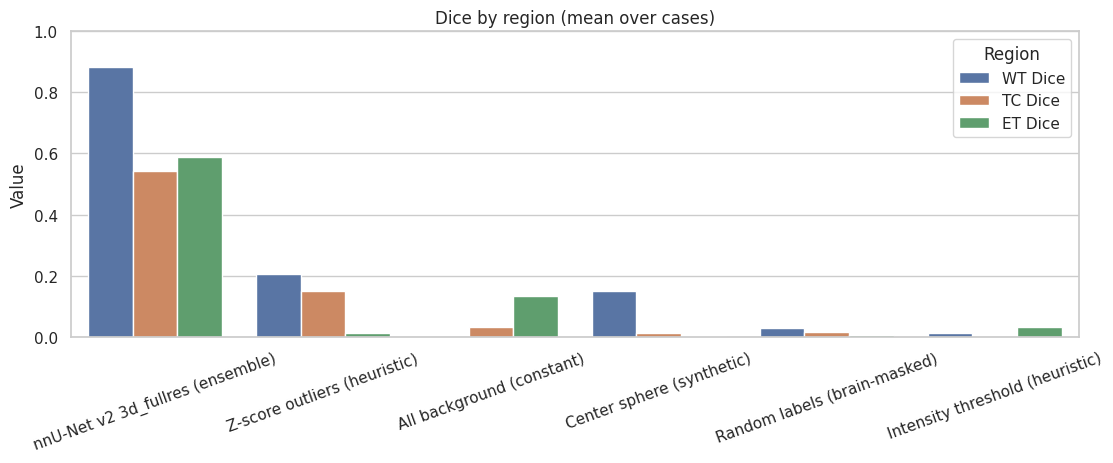

Saved: /workspace/Pediatric_Type/visualisations/model_comparison/dice_bar_means.png


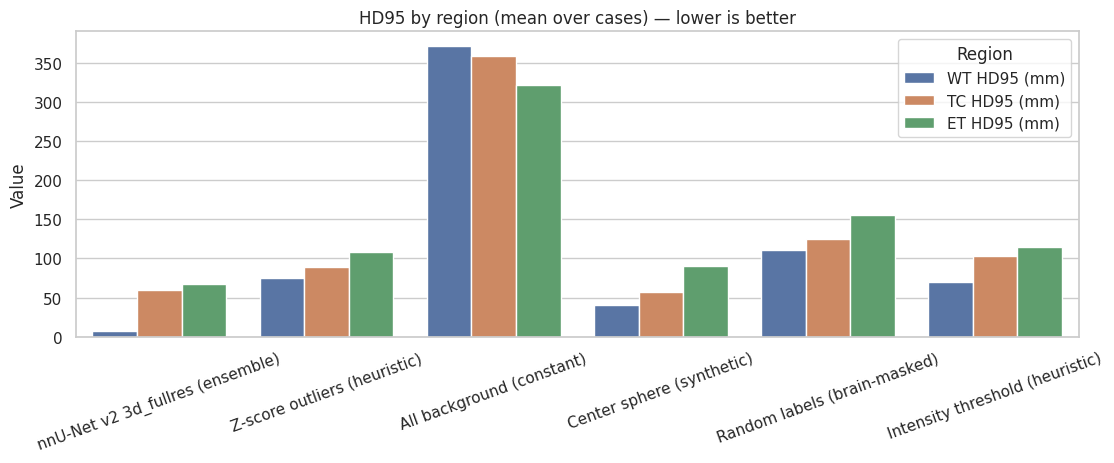

Saved: /workspace/Pediatric_Type/visualisations/model_comparison/hd95_bar_means.png


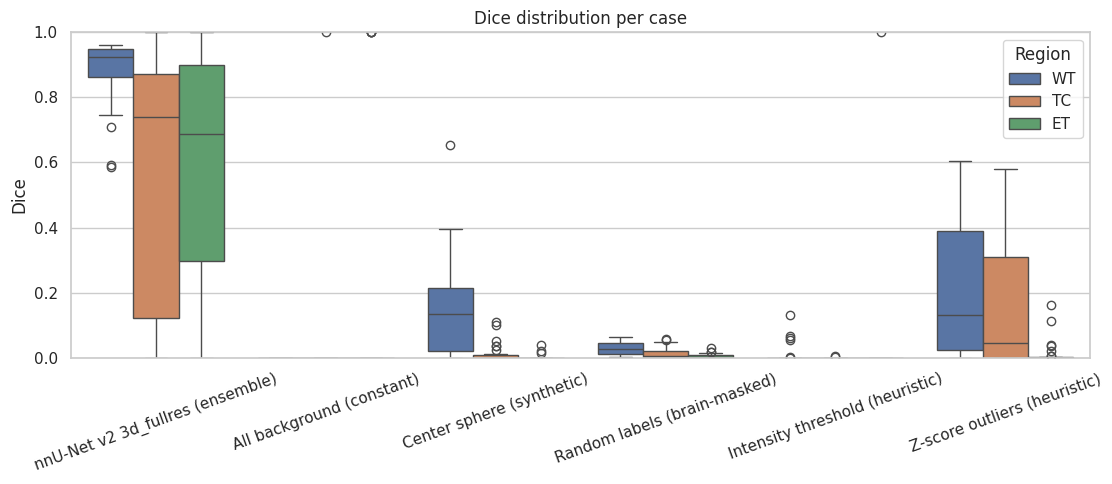

Saved: /workspace/Pediatric_Type/visualisations/model_comparison/dice_boxplot.png
Saved: /workspace/Pediatric_Type/results/model_comparison/model_comparison_per_case.csv


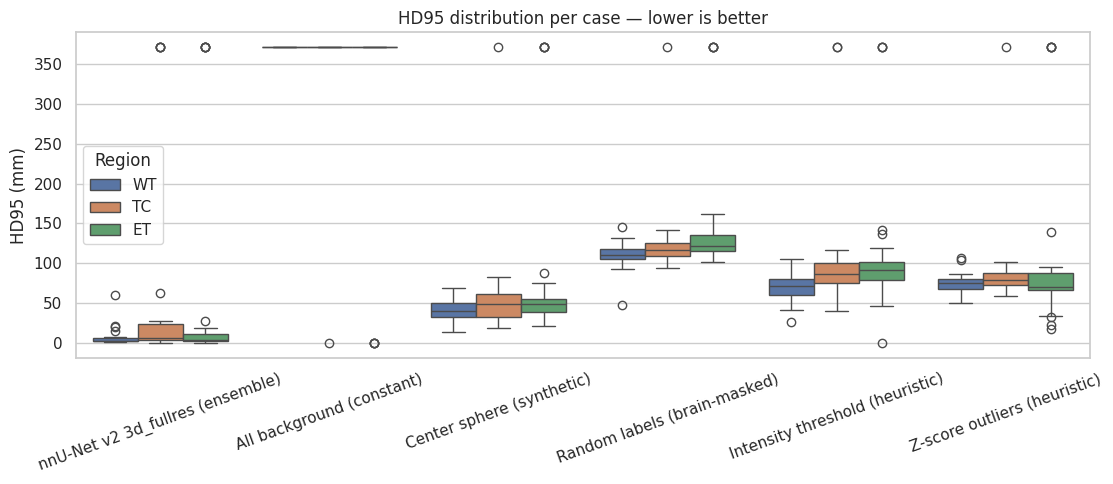

Saved: /workspace/Pediatric_Type/visualisations/model_comparison/hd95_boxplot.png
Saved: /workspace/Pediatric_Type/results/model_comparison/model_comparison_per_case.csv


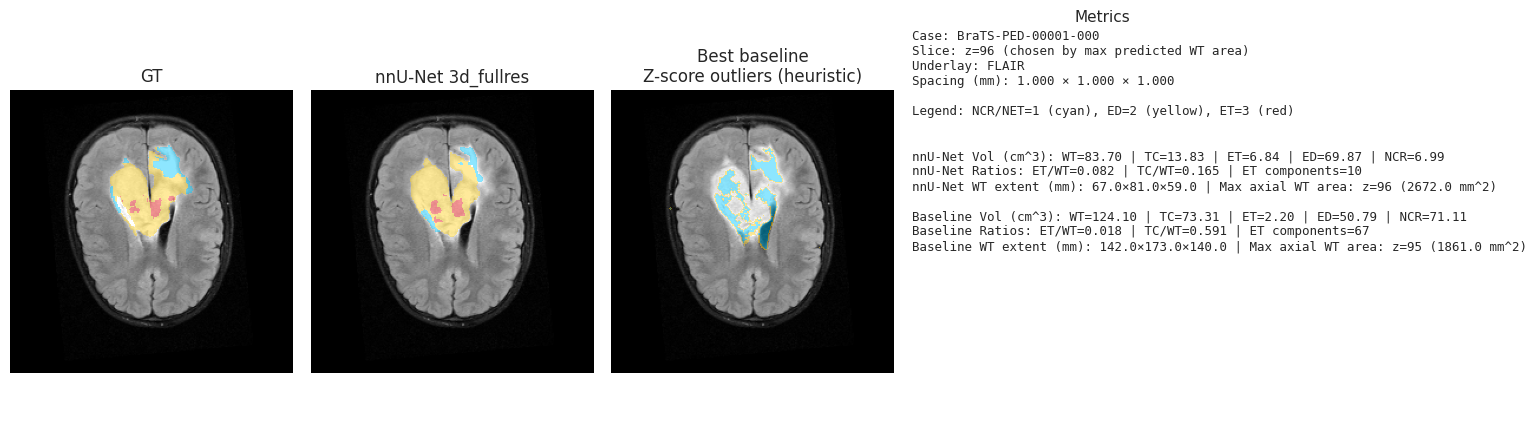

Saved: /workspace/Pediatric_Type/visualisations/model_comparison/sample_slice_BraTS-PED-00001-000.png


In [49]:
# Section 8.11 — Visualisations: Dice + HD95 + sample slices

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns

    sns.set_theme(style="whitegrid")
    SEABORN_OK = True
except Exception:
    SEABORN_OK = False


def _bar_plot(metric_cols: list[str], title: str, out_name: str, ylim=None):
    df_plot = df_comparison.copy()
    long = df_plot.melt(id_vars=["Model"], value_vars=metric_cols, var_name="Region", value_name="Value")
    long["Region"] = (
        long["Region"]
        .str.replace("WT_", "WT ", regex=False)
        .str.replace("TC_", "TC ", regex=False)
        .str.replace("ET_", "ET ", regex=False)
        .str.replace("Dice", "Dice", regex=False)
        .str.replace("HD95_mm", "HD95 (mm)", regex=False)
    )

    plt.figure(figsize=(max(11, 1.9 * len(df_plot["Model"])), 4.8))
    if SEABORN_OK:
        ax = sns.barplot(data=long, x="Model", y="Value", hue="Region")
        ax.set_title(title)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
        if ylim is not None:
            ax.set_ylim(*ylim)
        plt.tight_layout()
    else:
        plt.title(title)
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()

    out_path = VIZ_DIR / out_name
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)


def _box_plot(value_cols: list[str], title: str, out_name: str, ylabel: str, ylim=None):
    per_case_frames = []
    if "df_fullres" in globals() and isinstance(df_fullres, pd.DataFrame) and not df_fullres.empty:
        tmp = df_fullres.copy()
        tmp["Model"] = "nnU-Net v2 3d_fullres (ensemble)"
        per_case_frames.append(tmp)
    if "df_lowres" in globals() and isinstance(df_lowres, pd.DataFrame) and not df_lowres.empty:
        tmp = df_lowres.copy()
        tmp["Model"] = "nnU-Net v2 3d_lowres (ensemble)"
        per_case_frames.append(tmp)
    if "df_2d" in globals() and isinstance(df_2d, pd.DataFrame) and not df_2d.empty:
        tmp = df_2d.copy()
        tmp["Model"] = "nnU-Net v2 2d (ensemble)"
        per_case_frames.append(tmp)
    if "baseline_dfs" in globals() and isinstance(baseline_dfs, dict) and baseline_dfs:
        for model_name, df in baseline_dfs.items():
            if isinstance(df, pd.DataFrame) and not df.empty:
                tmp = df.copy()
                tmp["Model"] = model_name
                per_case_frames.append(tmp)
    if not per_case_frames:
        return

    df_cases = pd.concat(per_case_frames, ignore_index=True)

    region_label = "Region"
    val_label = ylabel

    is_dice = set(value_cols) == {"WT", "TC", "ET"}
    if is_dice:
        melt_cols = ["WT", "TC", "ET"]
    else:
        melt_cols = ["WT_hd95", "TC_hd95", "ET_hd95"]

    missing_cols = [c for c in melt_cols if c not in df_cases.columns]
    if missing_cols:
        print(f"[INFO] {title} skipped (missing columns: {missing_cols})")
        return

    df_long = df_cases.melt(
        id_vars=["case", "Model"],
        value_vars=melt_cols,
        var_name=region_label,
        value_name=val_label,
    )
    if not is_dice:
        df_long[region_label] = (
            df_long[region_label]
            .str.replace("WT_hd95", "WT", regex=False)
            .str.replace("TC_hd95", "TC", regex=False)
            .str.replace("ET_hd95", "ET", regex=False)
        )

    plt.figure(figsize=(max(11, 1.9 * df_cases["Model"].nunique()), 5))
    if SEABORN_OK:
        ax = sns.boxplot(data=df_long, x="Model", y=val_label, hue=region_label)
        ax.set_title(title)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
        if ylim is not None:
            ax.set_ylim(*ylim)
        plt.tight_layout()
    else:
        plt.title(title)
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()

    out_path = VIZ_DIR / out_name
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)

    cases_csv = RESULTS_DIR / "model_comparison_per_case.csv"
    df_cases.to_csv(cases_csv, index=False)
    print("Saved:", cases_csv)


# 1) Dice bars
_bar_plot(["WT_Dice", "TC_Dice", "ET_Dice"], "Dice by region (mean over cases)", "dice_bar_means.png", ylim=(0, 1.0))

# 2) HD95 bars (only if available)
if {"WT_HD95_mm", "TC_HD95_mm", "ET_HD95_mm"}.issubset(set(df_comparison.columns)):
    _bar_plot(
        ["WT_HD95_mm", "TC_HD95_mm", "ET_HD95_mm"],
        "HD95 by region (mean over cases) — lower is better",
        "hd95_bar_means.png",
        ylim=None,
    )

# 3) Dice per-case boxplot
_box_plot(["WT", "TC", "ET"], "Dice distribution per case", "dice_boxplot.png", ylabel="Dice", ylim=(0, 1.0))

# 4) HD95 per-case boxplot
try:
    _box_plot(
        ["WT_hd95", "TC_hd95", "ET_hd95"],
        "HD95 distribution per case — lower is better",
        "hd95_boxplot.png",
        ylabel="HD95 (mm)",
        ylim=None,
    )
except Exception as e:
    print("[INFO] HD95 boxplot skipped:", e)


# 5) Pictorial: sample slice montage (GT vs nnU-Net vs best baseline)
#    PLUS: prediction-only tumor parameters (volumes in cm^3, etc.) shown in a dedicated metrics panel.
try:
    import json
    from pathlib import Path

    import nibabel as nib
    from matplotlib.colors import BoundaryNorm, ListedColormap
    from scipy import ndimage

    ds_root = globals().get("dataset_folder", None) or globals().get("DATASET_FOLDER", None)
    if ds_root is None:
        raise RuntimeError("dataset_folder/DATASET_FOLDER not found in notebook scope")
    ds_root = Path(ds_root)

    SEG_CMAP = ListedColormap(["black", "#00c8ff", "#ffd21f", "#ff2d2d"])
    SEG_NORM = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], SEG_CMAP.N)


    def _load_channel_names(root: Path) -> dict[int, str]:
        p = root / "dataset.json"
        if not p.exists():
            return {}
        try:
            d = json.loads(p.read_text(encoding="utf-8"))
            ch = d.get("channel_names", {})
            out: dict[int, str] = {}
            for k, v in ch.items():
                try:
                    out[int(k)] = str(v)
                except Exception:
                    continue
            return out
        except Exception:
            return {}


    CHANNEL_NAMES = _load_channel_names(ds_root)


    def _pick_underlay_channel_index(prefer: tuple[str, ...] = ("flair", "t2", "t1ce", "t1")) -> int | None:
        if not CHANNEL_NAMES:
            return None
        for want in prefer:
            for i, nm in CHANNEL_NAMES.items():
                if want in nm.lower():
                    return int(i)
        return None


    def _get_case_spacing_mm(case_id: str) -> tuple[float, float, float]:
        """Best-effort spacing lookup (mm) using image header (prediction-only)."""
        try:
            images_dir = ds_root / "imagesTr"
            files = sorted(images_dir.glob(f"{case_id}_*.nii.gz"))
            if files:
                img = nib.load(str(files[0]))
                z = img.header.get_zooms()
                return (float(z[0]), float(z[1]), float(z[2]))
        except Exception:
            pass

        if "case_spacings" in globals() and isinstance(case_spacings, dict):
            return tuple(case_spacings.get(case_id, (1.0, 1.0, 1.0)))  # type: ignore[return-value]
        return (1.0, 1.0, 1.0)


    def _voxvol_mm3(sp: tuple[float, float, float]) -> float:
        return float(sp[0] * sp[1] * sp[2])


    def _vol_cm3(voxels: int, sp: tuple[float, float, float]) -> float:
        # 1 cm^3 = 1000 mm^3
        return float(voxels) * _voxvol_mm3(sp) / 1000.0


    def _bbox_extent_mm(mask: np.ndarray, sp: tuple[float, float, float]) -> tuple[float, float, float]:
        idx = np.argwhere(mask)
        if idx.size == 0:
            return (0.0, 0.0, 0.0)
        mins = idx.min(axis=0)
        maxs = idx.max(axis=0)
        ext_vox = (maxs - mins + 1).astype(np.float64)
        ext_mm = ext_vox * np.array(sp, dtype=np.float64)
        return (float(ext_mm[0]), float(ext_mm[1]), float(ext_mm[2]))


    def _count_components(mask: np.ndarray) -> int:
        if int(mask.sum()) == 0:
            return 0
        _, n = ndimage.label(mask.astype(bool))
        return int(n)


    def _max_axial_area_slice(mask: np.ndarray, sp: tuple[float, float, float]) -> tuple[int, float]:
        """Returns (z_index, max_area_mm2). mask shape assumed (X,Y,Z)."""
        if mask.ndim != 3:
            return (0, 0.0)
        if int(mask.sum()) == 0:
            return (mask.shape[2] // 2, 0.0)
        areas_px = mask.sum(axis=(0, 1)).astype(np.float64)
        areas_mm2 = areas_px * float(sp[0] * sp[1])
        z = int(np.argmax(areas_mm2))
        return (z, float(areas_mm2[z]))


    def _tumor_params_text(seg: np.ndarray, sp: tuple[float, float, float], *, prefix: str) -> str:
        seg_i = seg.astype(np.int32)
        wt = seg_i > 0
        tc = np.isin(seg_i, TC_LABELS)
        et = seg_i == ET_LABEL
        ed = seg_i == ED_LABEL
        ncr = seg_i == 1

        wt_v = _vol_cm3(int(wt.sum()), sp)
        tc_v = _vol_cm3(int(tc.sum()), sp)
        et_v = _vol_cm3(int(et.sum()), sp)
        ed_v = _vol_cm3(int(ed.sum()), sp)
        ncr_v = _vol_cm3(int(ncr.sum()), sp)

        et_cc = _count_components(et)
        wt_dx, wt_dy, wt_dz = _bbox_extent_mm(wt, sp)
        z_star, wt_area_mm2 = _max_axial_area_slice(wt, sp)

        et_over_wt = (et_v / wt_v) if wt_v > 0 else 0.0
        tc_over_wt = (tc_v / wt_v) if wt_v > 0 else 0.0

        line1 = f"{prefix} Vol (cm^3): WT={wt_v:.2f} | TC={tc_v:.2f} | ET={et_v:.2f} | ED={ed_v:.2f} | NCR={ncr_v:.2f}"
        line2 = f"{prefix} Ratios: ET/WT={et_over_wt:.3f} | TC/WT={tc_over_wt:.3f} | ET components={et_cc}"
        line3 = f"{prefix} WT extent (mm): {wt_dx:.1f}×{wt_dy:.1f}×{wt_dz:.1f} | Max axial WT area: z={z_star} ({wt_area_mm2:.1f} mm^2)"
        return "\n".join([line1, line2, line3])


    def _load_underlay_slice(case_id: str, z: int) -> tuple[np.ndarray, str]:
        images_dir = ds_root / "imagesTr"
        idx = _pick_underlay_channel_index()
        if idx is not None:
            p = images_dir / f"{case_id}_{idx:04d}.nii.gz"
            if p.exists():
                arr = np.asarray(nib.load(str(p)).dataobj, dtype=np.float32)
                return arr[:, :, z], CHANNEL_NAMES.get(idx, f"ch{idx}")

        files = sorted(images_dir.glob(f"{case_id}_*.nii.gz"))
        if not files:
            raise FileNotFoundError(f"No nnU-Net imagesTr channels found for case: {case_id}")
        p0 = files[0]
        arr0 = np.asarray(nib.load(str(p0)).dataobj, dtype=np.float32)
        return arr0[:, :, z], p0.name


    def _clip_limits(x2d: np.ndarray) -> tuple[float, float]:
        x = x2d[np.isfinite(x2d)]
        if x.size == 0:
            return (0.0, 1.0)
        x_nz = x[np.abs(x) > 0]
        src = x_nz if x_nz.size > 100 else x
        lo, hi = np.percentile(src, (1, 99))
        if not np.isfinite(lo) or not np.isfinite(hi) or float(hi) <= float(lo):
            lo = float(src.min())
            hi = float(src.max()) if float(src.max()) > lo else lo + 1.0
        return (float(lo), float(hi))


    def _show_overlay(ax, underlay2d: np.ndarray, seg2d: np.ndarray, *, title: str):
        vmin, vmax = _clip_limits(underlay2d)
        ax.imshow(underlay2d.T, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
        seg_m = np.ma.masked_where(seg2d == 0, seg2d)
        ax.imshow(seg_m.T, cmap=SEG_CMAP, norm=SEG_NORM, origin="lower", alpha=0.45, interpolation="nearest")
        ax.set_title(title)
        ax.axis("off")


    if "df_fullres" in globals() and isinstance(df_fullres, pd.DataFrame) and not df_fullres.empty:
        case_id = str(df_fullres.iloc[0]["case"])
        gt = ground_truths[case_id]
        pred_full = ref_ensemble[case_id]

        sp_pred = _get_case_spacing_mm(case_id)
        z, _ = _max_axial_area_slice(pred_full > 0, sp_pred)

        underlay2d, underlay_name = _load_underlay_slice(case_id, z)

        panels: list[tuple[str, np.ndarray]] = [("GT", gt), ("nnU-Net 3d_fullres", pred_full)]
        params_texts = [_tumor_params_text(pred_full, sp_pred, prefix="nnU-Net")]

        if "baseline_dfs" in globals() and baseline_dfs:
            best_name = None
            best_mean = -1.0
            for name, df in baseline_dfs.items():
                m = float(df["mean"].mean())
                if m > best_mean:
                    best_mean = m
                    best_name = name

            if best_name is not None:
                mods = _load_case_modalities(case_id)
                if best_name == "All background (constant)":
                    pred_b = baseline_all_background(gt.shape)
                elif best_name == "Center sphere (synthetic)":
                    pred_b = baseline_center_sphere(gt.shape)
                elif best_name == "Random labels (brain-masked)":
                    pred_b = baseline_random(mods[0], seed=12345)
                elif best_name == "Intensity threshold (heuristic)":
                    pred_b = baseline_intensity_threshold(mods)
                elif best_name == "Z-score outliers (heuristic)":
                    pred_b = baseline_zscore_outliers(mods)
                else:
                    pred_b = None

                if pred_b is not None and pred_b.shape == gt.shape:
                    panels.append((f"Best baseline\n{best_name}", pred_b))
                    params_texts.append(_tumor_params_text(pred_b, sp_pred, prefix="Baseline"))

        n = len(panels)
        fig, axes = plt.subplots(
            1,
            n + 1,
            figsize=(3.6 * n + 5.2, 4.6),
            gridspec_kw={"width_ratios": [1.0] * n + [1.35]},
        )

        for i, (title, seg_vol) in enumerate(panels):
            ax = axes[i]
            _show_overlay(ax, underlay2d, seg_vol[:, :, z], title=title)

        metrics_ax = axes[-1]
        metrics_ax.axis("off")
        metrics_ax.set_title("Metrics", fontsize=11)

        header = (
            f"Case: {case_id}\n"
            f"Slice: z={z} (chosen by max predicted WT area)\n"
            f"Underlay: {underlay_name}\n"
            f"Spacing (mm): {sp_pred[0]:.3f} × {sp_pred[1]:.3f} × {sp_pred[2]:.3f}\n"
            "\n"
            "Legend: NCR/NET=1 (cyan), ED=2 (yellow), ET=3 (red)\n"
        )
        metrics_ax.text(
            0.0,
            1.0,
            header + "\n\n" + "\n\n".join(params_texts),
            ha="left",
            va="top",
            fontsize=9,
            family="monospace",
            transform=metrics_ax.transAxes,
        )

        plt.tight_layout()

        montage_path = VIZ_DIR / f"sample_slice_{case_id}.png"
        plt.savefig(montage_path, dpi=200)
        plt.show()
        print("Saved:", montage_path)

except Exception as e:
    print("[INFO] Sample slice montage skipped:", e)
